# Clustering

In [7]:
import sys

!"{sys.executable}" -m pip install -q \
numpy==1.26.4 \
pandas==2.1.4 \
scikit-learn==1.3.2 \
scikit-learn-extra==0.3.0 \
scipy==1.11.4 \
matplotlib==3.8.2 \
seaborn==0.13.2 \
xgboost==2.0.3 \
mlxtend==0.23.1 \
shap==0.44.1 \
lime==0.2.0.1

In [8]:
# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
import pickle
from sklearn import tree
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, OneHotEncoder,
    RobustScaler, KBinsDiscretizer
)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, silhouette_score
)
from sklearn_extra.cluster import KMedoids
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA

from scipy.stats import chi2_contingency
shap_available = False
try:
    import shap
    shap.initjs()
    shap_available = True
except Exception as e:
    print(f"SHAP not available - {e}")

try:
    import lime
    import lime.lime_tabular
except Exception as e:
    print(f"LIME not available - {e}")

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

warnings.filterwarnings('ignore')


## Load Dataset

In [9]:
df = pd.read_csv('LightHR_dataset.csv', header='infer')
print(df.shape)
df.head()

(8800, 15)


,Gender,Age at time of application,Year of Application,A-levels scores,Education,University Name,Address,Current Employment,Current Employment Sector,Current Annual Income,References Submitted,Refree 1,Refree 2,Refree 3,Was Hired by a Company within 6 months
0,Female,40,2008,81,Law,SCHOOL OF ORIENTAL AND AFRICAN STUDIES,Lancashire,Salaried,Law,0,1,Self Business:Health,Salaried:Accounting,Contractual:Arts,1
1,Non-binary,48,2001,52,Arts,UNIVERSITY OF PORTSMOUTH,Pembrokeshire,Contractual,Arts,145882,0,NaN,NaN,NaN,0
2,Female,48,2005,77,STEM,UNIVERSITY OF STIRLING,Cambridgeshire,NaN,NaN,0,1,Contractual:Arts,Self Business:Arts,Self Business:Accounting,0
3,Non-binary,40,1999,46,STEM,UNIVERSITY OF KENT,Armagh,Self Business,IT,96719,1,Contractual:Law,Salaried:Engineering,Self Business:Accounting,0
4,Non-binary,41,2003,65,Law,UNIVERSITY OF SHEFFIELD,Wiltshire,Salaried,IT,74300,1,Salaried:IT,Salaried:Arts,Contractual:Engineering,0


# Data Cleaning

In [10]:
# University Name cleaning

def clean_university(name):
    name = name.lower().strip()
    name = name.replace('universirt of cambridge', 'university of cambridge')
    name = re.sub(r'\(the\)', '', name)
    name = re.sub(r'^the\s+', '', name)
    name = name.replace('&', 'and')
    name = name.replace('/', ' ')
    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r'\bthe$', '', name)
    name = re.sub(r'the$', '', name)
    name = re.sub(r'\s+', ' ', name)

    return name.strip()

df['University Name'] = df['University Name'].apply(clean_university)

# Gender cleaning

df['Gender'] = df['Gender'].str.lower()

# Education cleaning

df['Education'] = df['Education'].str.lower()

# Address cleaning

df['Address'] = df['Address'].str.lower().str.strip()
df['Address'] = df['Address'].str.replace(r'^(city of |greater )| city$', '', regex=True).str.strip()

# Current Employment cleaning

df['Current Employment'] = df['Current Employment'].fillna('unemployed')
df['Current Employment'] = df['Current Employment'].str.lower()

# Current Employment Sector cleaning

df['Current Employment Sector'] = df['Current Employment Sector'].fillna('unemployed')
df['Current Employment Sector'] = df['Current Employment Sector'].str.lower()

# Refree cleaning
df['Refree 1'] = df['Refree 1'].fillna('none')
df['Refree 2'] = df['Refree 2'].fillna('none')
df['Refree 3'] = df['Refree 3'].fillna('none')

df = df.drop_duplicates()

# Decision Tree

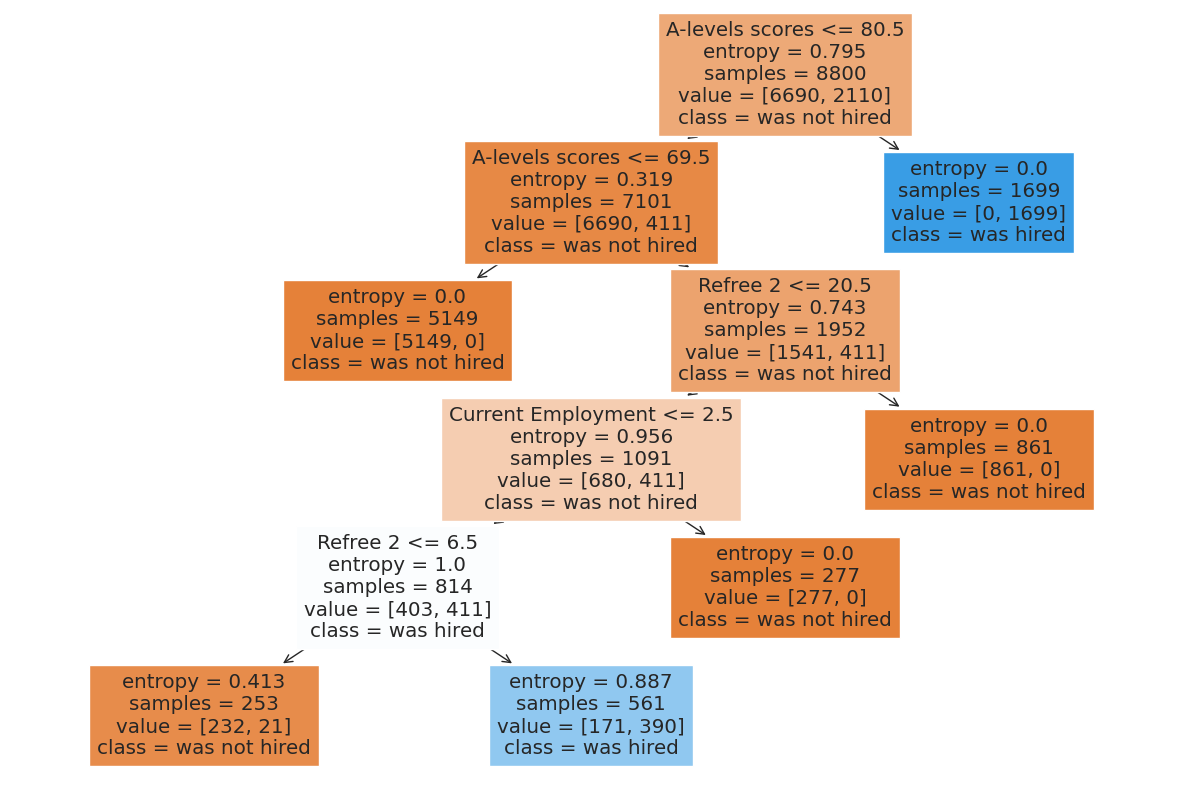

|--- A-levels scores <= 80.50
|   |--- A-levels scores <= 69.50
|   |   |--- class: 0
|   |--- A-levels scores >  69.50
|   |   |--- Refree 2 <= 20.50
|   |   |   |--- Current Employment <= 2.50
|   |   |   |   |--- Refree 2 <= 6.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Refree 2 >  6.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- Current Employment >  2.50
|   |   |   |   |--- class: 0
|   |   |--- Refree 2 >  20.50
|   |   |   |--- class: 0
|--- A-levels scores >  80.50
|   |--- class: 1



In [11]:
le = LabelEncoder()
df_label = df.copy()

for col in df_label.select_dtypes(include=['object', 'category']).columns:
    df_label[col] = le.fit_transform(df_label[col])

Y = df_label['Was Hired by a Company within 6 months']
X = df_label.drop(columns = ['Was Hired by a Company within 6 months'])
clf = tree.DecisionTreeClassifier(criterion='entropy',max_depth=5)
clf = clf.fit(X, Y)

plt.figure(figsize=(15,10))
plot_tree(
   clf,
   feature_names=X.columns,
   class_names=['was not hired', 'was hired'],
   filled=True
)
plt.show()

tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)

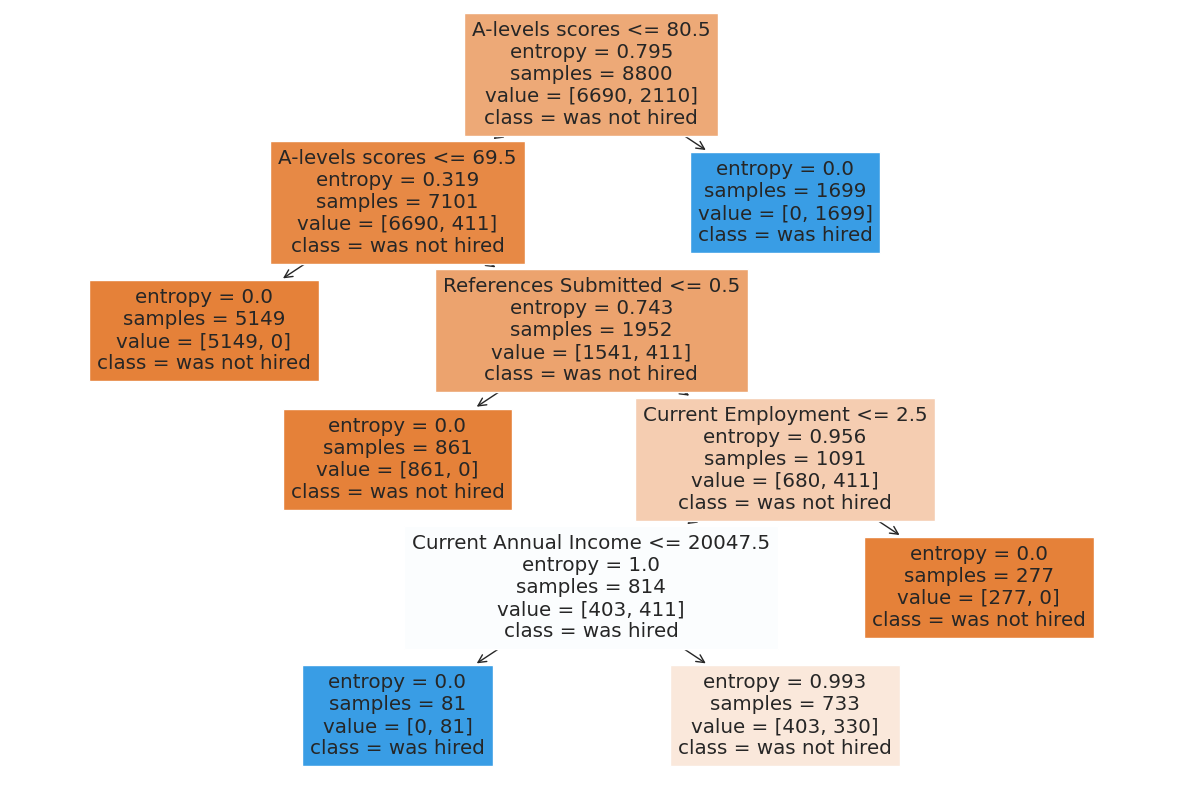

|--- A-levels scores <= 80.50
|   |--- A-levels scores <= 69.50
|   |   |--- class: 0
|   |--- A-levels scores >  69.50
|   |   |--- References Submitted <= 0.50
|   |   |   |--- class: 0
|   |   |--- References Submitted >  0.50
|   |   |   |--- Current Employment <= 2.50
|   |   |   |   |--- Current Annual Income <= 20047.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Current Annual Income >  20047.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Current Employment >  2.50
|   |   |   |   |--- class: 0
|--- A-levels scores >  80.50
|   |--- class: 1



In [12]:
le = LabelEncoder()
df_label = df.copy()
df_label = df_label.drop(columns=['Refree 1', 'Refree 2', 'Refree 3']) # done this because lots of messy splits, still mostly predicting class 0 = noise

for col in df_label.select_dtypes(include=['object', 'category']).columns:
    df_label[col] = le.fit_transform(df_label[col])

Y = df_label['Was Hired by a Company within 6 months']
X = df_label.drop(columns = ['Was Hired by a Company within 6 months'])
clf = tree.DecisionTreeClassifier(criterion='entropy',max_depth=5)
clf = clf.fit(X, Y)

plt.figure(figsize=(15,10))
plot_tree(
   clf,
   feature_names=X.columns,
   class_names=['was not hired', 'was hired'],
   filled=True
)
plt.show()

tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)

## Fix Dirty Data

In [13]:
str_cols = df.select_dtypes(include=['object']).columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

## Handle Missing Values

In [14]:
df['Current Employment'] = df['Current Employment'].fillna('Unemployed')
df['Current Employment Sector'] = df['Current Employment Sector'].fillna('Unemployed')
df['Current Annual Income'] = df['Current Annual Income'].fillna(0)

print("Missing values after filling:")
print(df.isnull().sum())



Missing values after filling:
Gender                                    0
Age at time of application                0
Year of Application                       0
A-levels scores                           0
Education                                 0
University Name                           0
Address                                   0
Current Employment                        0
Current Employment Sector                 0
Current Annual Income                     0
References Submitted                      0
Refree 1                                  0
Refree 2                                  0
Refree 3                                  0
Was Hired by a Company within 6 months    0
dtype: int64


## Drop Irrelevant Columns

In [15]:
df_with_uni = df.copy()

df = df.drop(columns=['Gender', 'Address','University Name', 'Year of Application', 'Age at time of application', 'Refree 1', 'Refree 2', 'Refree 3'])
print("Columns remaining:", df.columns.tolist())

df.head()

Columns remaining: ['A-levels scores', 'Education', 'Current Employment', 'Current Employment Sector', 'Current Annual Income', 'References Submitted', 'Was Hired by a Company within 6 months']


,A-levels scores,Education,Current Employment,Current Employment Sector,Current Annual Income,References Submitted,Was Hired by a Company within 6 months
0,81,law,salaried,law,0,1,1
1,52,arts,contractual,arts,145882,0,0
2,77,stem,unemployed,unemployed,0,1,0
3,46,stem,self business,it,96719,1,0
4,65,law,salaried,it,74300,1,0


## Define Dataset Variants and Feature Engineering

In [16]:
df_binary = df.copy()
df_raw = df.copy() #needed for later in the notebook(explainablity)
df_binary['Is_Employed'] = (df_binary['Current Employment'] != 'unemployed').astype(int)
df_binary = df_binary.drop(columns=['Current Employment', 'Current Employment Sector'])

df_employed = df.copy()

df_binary_bin_uni = df_binary.copy()
df_binary_bin_uni['University Name'] = df_with_uni['University Name']

df_binary_scaled = df_binary.copy()

df_bin_uni_scaled = df_binary_bin_uni.copy()


df_binary.head()

,A-levels scores,Education,Current Annual Income,References Submitted,Was Hired by a Company within 6 months,Is_Employed
0,81,law,0,1,1,1
1,52,arts,145882,0,0,1
2,77,stem,0,1,0,0
3,46,stem,96719,1,0,1
4,65,law,74300,1,0,1


## Binning Universities

In [17]:
elite = [
    "university of oxford",
    "university of cambridge",
    "imperial college london",
    "university college london",
    "london school of economics and political science"
]

strong = [
    "university of manchester",
    "university of bristol",
    "university of warwick",
    "university of edinburgh",
    "kings college london",
    "university of birmingham",
    "university of leeds",
    "university of sheffield",
    "university of nottingham",
    "university of southampton",
    "university of glasgow",
    "newcastle university",
    "cardiff university",
    "queen mary university of london",
    "durham university"
]

def map_uni(uni):
    if uni in elite:
        return "Elite"
    elif uni in strong:
        return "Strong"
    else:
        return "Other"

df_binary_bin_uni['University Tier'] = df_binary_bin_uni['University Name'].apply(map_uni)
df_binary_bin_uni = df_binary_bin_uni.drop(columns=['University Name'])

df_bin_uni_scaled['University Tier'] = df_bin_uni_scaled['University Name'].apply(map_uni)
df_bin_uni_scaled = df_bin_uni_scaled.drop(columns=['University Name'])

## Visualise Numerical Columns

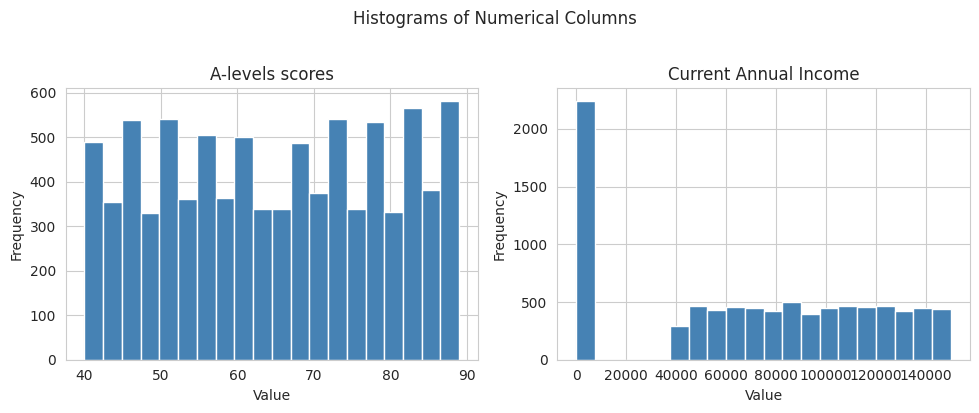


Observation:  
- A-levels (40-90): roughly uniform -> use equal-width discretisation
- Annual Income: check shape — if skewed use kmeans, if uniform use equal-width



In [18]:
num_cols = ['Age at time of application', 'Year of Application', 'A-levels scores', 'Current Annual Income']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    df[col].hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Columns', y=1.02)
plt.tight_layout()
plt.show()

print("""
Observation:
- A-levels (40-90): roughly uniform -> use equal-width discretisation
- Annual Income: check shape — if skewed use kmeans, if uniform use equal-width
""")

## Discretise Numerical Columns

In [19]:
def discretise_numerical(data, num_cols):
    data = data.copy()

    uniform_cols = ['Age at time of application', 'A-levels scores']
    uniform_cols = [c for c in uniform_cols if c in data.columns]

    kmeans_cols = ['Current Annual Income']
    kmeans_cols = [c for c in kmeans_cols if c in data.columns]

    if uniform_cols:
        kbd_uniform = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
        data[uniform_cols] = kbd_uniform.fit_transform(data[uniform_cols])

    if kmeans_cols:
        kbd_kmeans = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='kmeans')
        data[kmeans_cols] = kbd_kmeans.fit_transform(data[kmeans_cols])

    return data


all_num_cols = ['A-levels scores', 'Current Annual Income']

df_employed_disc = discretise_numerical(df_employed, all_num_cols)
df_binary_disc = discretise_numerical(df_binary, all_num_cols)
df_binary_bin_uni_disc = discretise_numerical(df_binary_bin_uni, all_num_cols)

print("Sample after discretisation:")
df_employed_disc[all_num_cols].head()

Sample after discretisation:


,A-levels scores,Current Annual Income
0,4.0,0.0
1,1.0,4.0
2,3.0,0.0
3,0.0,3.0
4,2.0,2.0


## Scaling

In [20]:
def scale_numerical(data, cols):
    data = data.copy()
    data[cols] = scaler.fit_transform(data[cols])
    return data

scaler = RobustScaler()

df_binary_scaled = scale_numerical(df_binary_scaled, all_num_cols)

df_bin_uni_scaled = scale_numerical(df_bin_uni_scaled, all_num_cols)

#df_eng = df_bin_uni_scaled.copy() # needed later for explanability and fairness

## One-Hot Encode

In [21]:
cat_cols_binary = ['Education', 'Current Employment Sector']
cat_cols_employed= ['Education', 'Current Employment Sector', 'Current Employment']

def one_hot_encode(data, cat_cols, target_col='Was Hired by a Company within 6 months'):
    """
    One-hot encode categorical columns, preserve target column.
    """
    target = data[target_col].copy() if target_col in data.columns else None
    X = data.drop(columns=[target_col], errors='ignore')

    cols_to_ohe = [c for c in cat_cols if c in X.columns]

    ohe = OneHotEncoder(sparse_output=False, drop='first')
    encoded = ohe.fit_transform(X[cols_to_ohe])
    encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols_to_ohe), index=X.index)

    X_num = X.drop(columns=cols_to_ohe)
    X_final = pd.concat([X_num, encoded_df], axis=1)

    if target is not None:
        X_final[target_col] = target

    return X_final


df_employed_final = one_hot_encode(df_employed_disc, cat_cols_employed)
df_binary_final = one_hot_encode(df_binary_disc, cat_cols_binary)
df_binary_uni_bin_final = one_hot_encode(df_binary_bin_uni_disc, cat_cols_binary)
df_binary_scaled_final = one_hot_encode(df_binary_scaled, cat_cols_binary)
df_bin_uni_scaled_final = one_hot_encode(df_bin_uni_scaled, cat_cols_binary)

print("Shape after one-hot encoding (employed variant discretised):", df_employed_final.shape)
print("Shape after one-hot encoding (binary variant discretised):", df_binary_final.shape)
print("Shape after one-hot encoding (binned university names discretised):", df_binary_uni_bin_final.shape)
print("Shape after one-hot encoding (binary variant scaled):", df_binary_scaled_final.shape)
print("Shape after one-hot encoding (binned university names scaled):", df_binary_uni_bin_final.shape)

Shape after one-hot encoding (employed variant discretised): (8800, 17)
Shape after one-hot encoding (binary variant discretised): (8800, 8)
Shape after one-hot encoding (binned university names discretised): (8800, 9)
Shape after one-hot encoding (binary variant scaled): (8800, 8)
Shape after one-hot encoding (binned university names scaled): (8800, 9)


## Define Dataset Variants for Comparison

In [22]:
datasets = {
    "employed_flag" : df_employed_final,
    "binary_employment" : df_binary_final,
    "binned Uni name" : df_binary_uni_bin_final,
    "employed_flag_scaled" : df_binary_scaled_final,
    "binned Uni name scaled" : df_bin_uni_scaled_final

}
print("Datasets prepared:")
for name, d in datasets.items():
    print(f"  {name}: {d.shape}")


Datasets prepared:
  employed_flag: (8800, 17)
  binary_employment: (8800, 8)
  binned Uni name: (8800, 9)
  employed_flag_scaled: (8800, 8)
  binned Uni name scaled: (8800, 9)


## PCA + KMedoids Clustering with Silhouette Score Search

In [23]:
TARGET_COL = 'Was Hired by a Company within 6 months'
SAMPLE_SIZE = 8800
N_INIT = 3
np.random.seed(20)

results = []

for name, data in datasets.items():
    print(f"\nProcessing: {name}")

    X = data.drop(columns=[TARGET_COL], errors='ignore').copy()
    X = X.select_dtypes(include=['number'])

    n = min(SAMPLE_SIZE, len(X))
    idx = np.random.choice(len(X), n, replace=False)
    X_sample = X.iloc[idx]
    print(f"  Subsample size: {n}")

    best_score = -1
    best_k = None

    for k in range(2, 10):
        best_run_score = -1
        best_run_labels = None

        for _ in range(N_INIT):
            kmedoids = KMedoids(
                n_clusters=k,
                random_state=42,
                init='k-medoids++',
                metric='manhattan'
            )

            labels = kmedoids.fit_predict(X_sample)

            if len(set(labels)) < k:
                continue

            score = silhouette_score(X_sample, labels, metric='manhattan')

            if score > best_run_score:
                best_run_score = score
                best_run_labels = labels

        print(f"  k={k} -> silhouette={best_run_score:.4f}")

        if best_run_labels is not None and best_run_score > best_score:
            best_score = best_run_score
            best_k = k

    results.append({
        "dataset": name,
        "best_k": best_k,
        "best_silhouette": best_score
    })

    print(f"  -> Best k={best_k}, silhouette={best_score:.4f}")

results_df = pd.DataFrame(results).sort_values(by='best_silhouette', ascending=False)

print("\n=== Final Results ===")
print(results_df)


Processing: employed_flag
  Subsample size: 8800
  k=2 -> silhouette=0.1745
  k=3 -> silhouette=0.1645
  k=4 -> silhouette=0.2371
  k=5 -> silhouette=0.2329
  k=6 -> silhouette=0.1818
  k=7 -> silhouette=0.1822
  k=8 -> silhouette=0.1875
  k=9 -> silhouette=0.1789
  -> Best k=4, silhouette=0.2371

Processing: binary_employment
  Subsample size: 8800
  k=2 -> silhouette=0.2806
  k=3 -> silhouette=0.2905
  k=4 -> silhouette=0.2553
  k=5 -> silhouette=0.2573
  k=6 -> silhouette=0.2538
  k=7 -> silhouette=0.2407
  k=8 -> silhouette=0.2181
  k=9 -> silhouette=0.2367
  -> Best k=3, silhouette=0.2905

Processing: binned Uni name
  Subsample size: 8800
  k=2 -> silhouette=0.2918
  k=3 -> silhouette=0.3132
  k=4 -> silhouette=0.2316
  k=5 -> silhouette=0.2319
  k=6 -> silhouette=0.2329
  k=7 -> silhouette=0.2522
  k=8 -> silhouette=0.2104
  k=9 -> silhouette=0.2024
  -> Best k=3, silhouette=0.3132

Processing: employed_flag_scaled
  Subsample size: 8800
  k=2 -> silhouette=0.3025
  k=3 -> silh

## Visualise Silhouette Scores

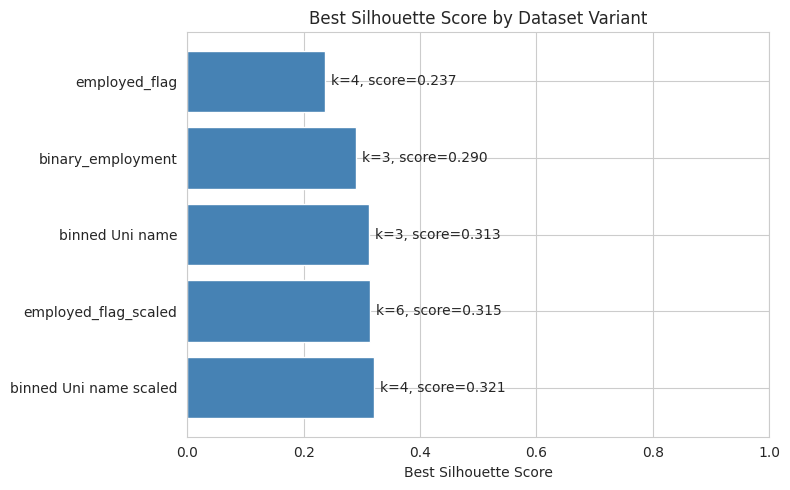

In [24]:
plt.figure(figsize=(8, 5))
bars = plt.barh(results_df['dataset'], results_df['best_silhouette'], color='steelblue')
plt.xlabel('Best Silhouette Score')
plt.title('Best Silhouette Score by Dataset Variant')
plt.xlim(0, 1)

for bar, (_, row) in zip(bars, results_df.iterrows()):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"k={int(row['best_k'])}, score={row['best_silhouette']:.3f}",
             va='center')

plt.tight_layout()
plt.show()

## Visualise Clusters in PCA Space

Best variant : binned Uni name scaled
Best k       : 4
Silhouette   : 0.3206

Cluster sizes (full dataset):
  Cluster 0: 1970 rows (22.4%)
  Cluster 1: 2564 rows (29.1%)
  Cluster 2: 2582 rows (29.3%)
  Cluster 3: 1684 rows (19.1%)


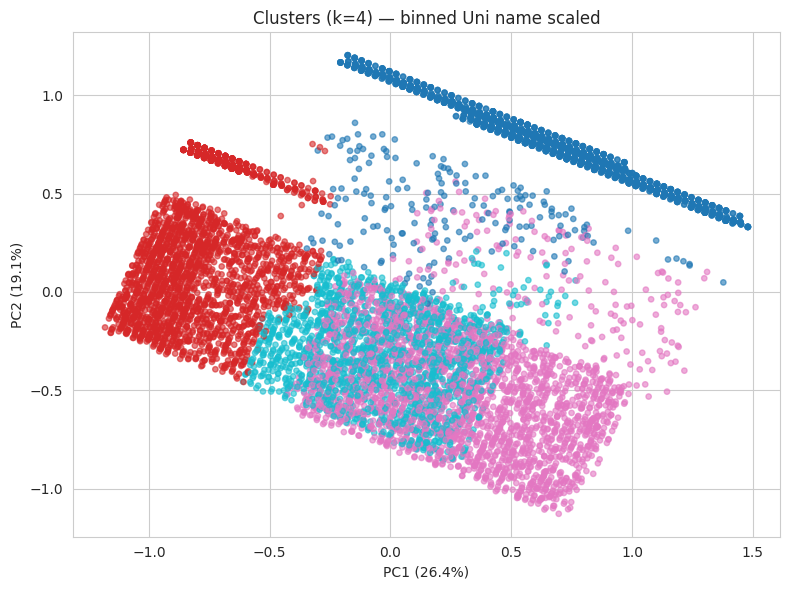

In [25]:
best_row  = results_df.iloc[0]
best_name = best_row['dataset']
best_k    = int(best_row['best_k'])

print(f"Best variant : {best_name}")
print(f"Best k       : {best_k}")
print(f"Silhouette   : {best_row['best_silhouette']:.4f}")

X_full = datasets[best_name].drop(columns=[TARGET_COL], errors='ignore').copy()
X_full = X_full.select_dtypes(include=['number'])

X_best = X_full.copy()

kmedoids = KMedoids(n_clusters=best_k, random_state=42, metric='manhattan')
best_labels = kmedoids.fit_predict(X_full)
labels = best_labels
print(f"\nCluster sizes (full dataset):")
unique, counts = np.unique(labels, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f"  Cluster {cl}: {cnt} rows ({cnt/len(labels)*100:.1f}%)")

pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_full)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='tab10', s=15, alpha=0.6)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Clusters (k={best_k}) — {best_name}')

plt.tight_layout()
plt.show()

In [26]:
raw_lookup = {
    'employed_flag':         df_employed,
    'binary_employment':     df_binary,
    'binned Uni name':       df_binary_bin_uni,
    'employed_flag_scaled':  df_binary_scaled,
    'binned Uni name scaled':df_bin_uni_scaled,
}
df_profile = raw_lookup[best_name].copy()
df_profile['Cluster'] = labels

print("Columns available for profiling:", df_profile.columns.tolist())

Columns available for profiling: ['A-levels scores', 'Education', 'Current Annual Income', 'References Submitted', 'Was Hired by a Company within 6 months', 'Is_Employed', 'University Tier', 'Cluster']


=== Mean numeric values per cluster ===
         A-levels scores  Current Annual Income  References Submitted  \
Cluster                                                                 
0                  -0.20                  -0.61                  0.52   
1                   0.64                   0.01                  1.00   
2                  -0.22                   0.17                  0.00   
3                  -0.43                   0.18                  1.00   

         Is_Employed  Was Hired by a Company within 6 months  
Cluster                                                       
0               0.00                                    0.00  
1               1.00                                    0.82  
2               0.92                                    0.00  
3               0.97                                    0.01  


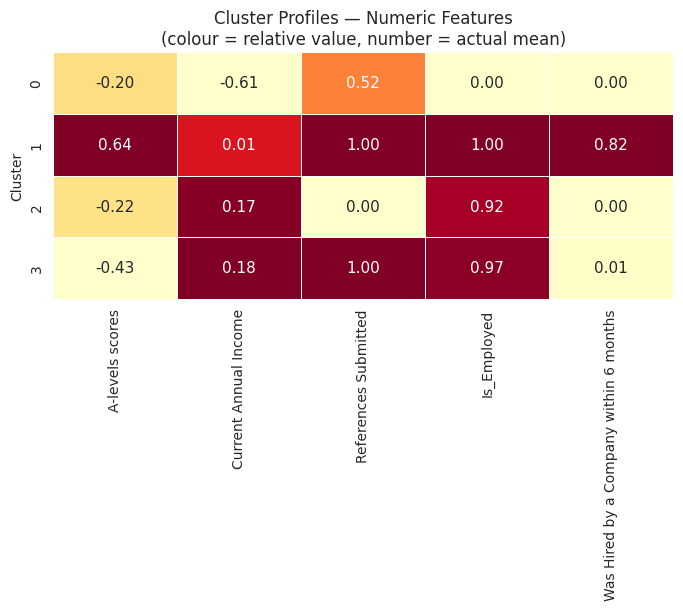

In [27]:
num_profile_cols = [c for c in ['A-levels scores', 'Current Annual Income',
                                 'References Submitted', 'Is_Employed',
                                 TARGET_COL]
                    if c in df_profile.columns]

profile = df_profile.groupby('Cluster')[num_profile_cols].mean().round(2)
print("=== Mean numeric values per cluster ===")
print(profile)

profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

plt.figure(figsize=(8, max(3, best_k * 0.8)))
sns.heatmap(profile_norm, annot=profile.values, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5, cbar=False,
            annot_kws={'size': 11})
plt.title('Cluster Profiles — Numeric Features\n(colour = relative value, number = actual mean)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

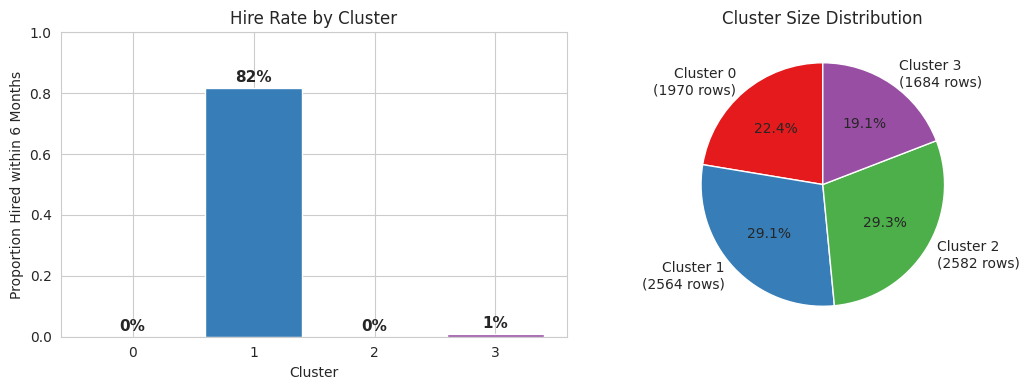

In [28]:
palette = sns.color_palette('Set1', n_colors=best_k)

if TARGET_COL in df_profile.columns:
    hire = df_profile.groupby('Cluster')[TARGET_COL].mean()
    sizes = df_profile.groupby('Cluster').size()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    bars = axes[0].bar(hire.index.astype(str), hire.values,
                       color=[palette[i] for i in hire.index], edgecolor='white')
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('Proportion Hired within 6 Months')
    axes[0].set_title('Hire Rate by Cluster')
    for bar, val in zip(bars, hire.values):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02, f'{val:.0%}',
                     ha='center', fontsize=11, fontweight='bold')

    # Pie chart — cluster sizes
    axes[1].pie(sizes.values, labels=[f'Cluster {i}\n({s} rows)' for i, s in sizes.items()],
                colors=[palette[i] for i in sizes.index],
                autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Cluster Size Distribution')

    plt.tight_layout()
    plt.show()

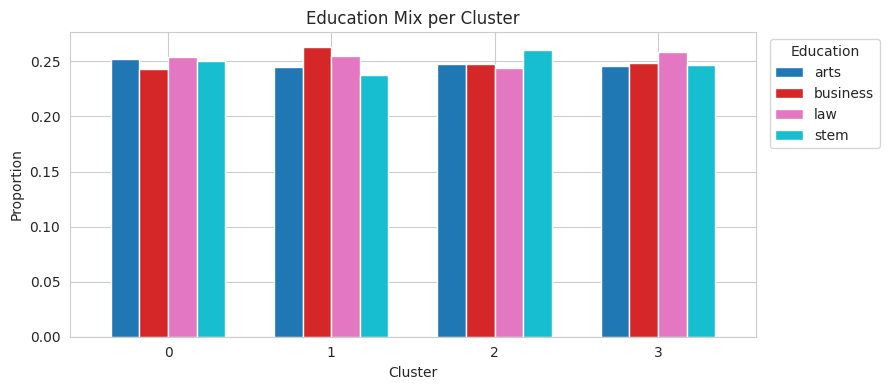

Education   arts  business    law   stem
Cluster                                 
0          0.252     0.243  0.254  0.250
1          0.245     0.263  0.255  0.238
2          0.248     0.248  0.244  0.261
3          0.246     0.248  0.259  0.247


In [29]:
if 'Education' in df_profile.columns:
    edu_counts = (df_profile.groupby(['Cluster', 'Education'])
                  .size().unstack(fill_value=0))
    edu_pct = edu_counts.div(edu_counts.sum(axis=1), axis=0)

    edu_pct.plot(kind='bar', figsize=(9, 4), colormap='tab10',
                 edgecolor='white', width=0.7)
    plt.title('Education Mix per Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Proportion')
    plt.xticks(rotation=0)
    plt.legend(title='Education', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    print(edu_pct.round(3))

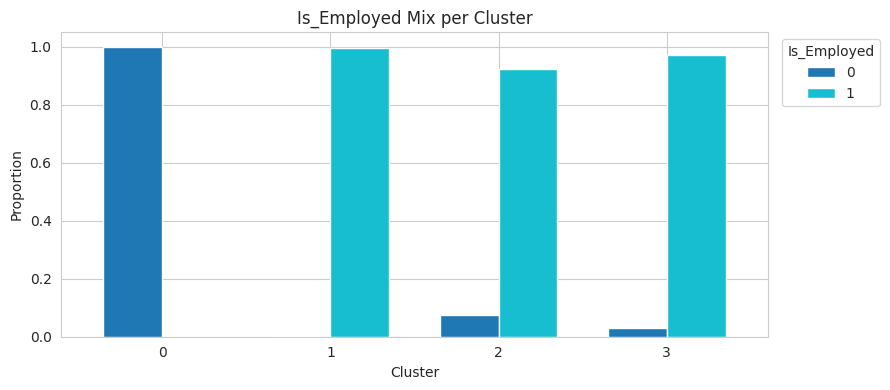

In [30]:
emp_col = 'Current Employment' if 'Current Employment' in df_profile.columns else 'Is_Employed'

if emp_col in df_profile.columns:
    emp_counts = (df_profile.groupby(['Cluster', emp_col])
                  .size().unstack(fill_value=0))
    emp_pct = emp_counts.div(emp_counts.sum(axis=1), axis=0)

    emp_pct.plot(kind='bar', figsize=(9, 4), colormap='tab10',
                 edgecolor='white', width=0.7)
    plt.title(f'{emp_col} Mix per Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Proportion')
    plt.xticks(rotation=0)
    plt.legend(title=emp_col, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## PCA Variance Explained

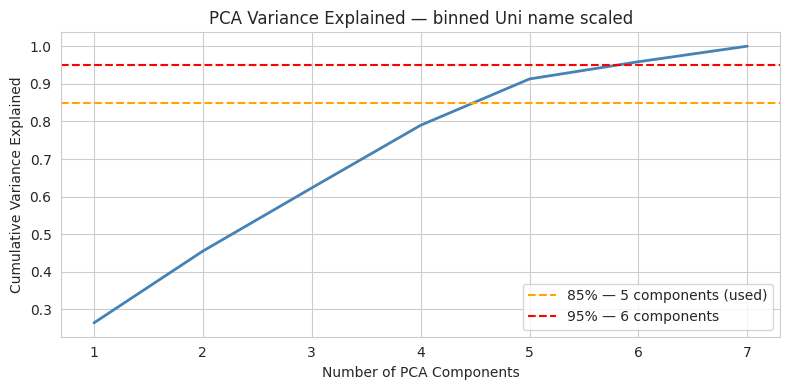

Original features (post-encoding) : 7
Components for 85% variance       : 5  (dimensionality reduced by 2)
Components for 95% variance       : 6


In [31]:
pca_full = PCA(random_state=42)
pca_full.fit(X_best)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n85 = np.searchsorted(cumvar, 0.85) + 1
n95 = np.searchsorted(cumvar, 0.95) + 1

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, color='steelblue', linewidth=2)
plt.axhline(0.85, color='orange', linestyle='--', label=f'85% — {n85} components (used)')
plt.axhline(0.95, color='red',    linestyle='--', label=f'95% — {n95} components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Variance Explained')
plt.title(f'PCA Variance Explained — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Original features (post-encoding) : {X_best.shape[1]}")
print(f"Components for 85% variance       : {n85}  (dimensionality reduced by {X_best.shape[1]-n85})")
print(f"Components for 95% variance       : {n95}")

# Association Rule Mining

In [32]:
df = pd.read_csv('LightHR_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nHiring outcome distribution:")
print(df['Was Hired by a Company within 6 months'].value_counts())
print(f"  Hire rate: {df['Was Hired by a Company within 6 months'].mean():.2%}")
df.head()

Dataset shape: (8800, 15)

Hiring outcome distribution:
Was Hired by a Company within 6 months
0    6690
1    2110
Name: count, dtype: int64
  Hire rate: 23.98%


,Gender,Age at time of application,Year of Application,A-levels scores,Education,University Name,Address,Current Employment,Current Employment Sector,Current Annual Income,References Submitted,Refree 1,Refree 2,Refree 3,Was Hired by a Company within 6 months
0,Female,40,2008,81,Law,SCHOOL OF ORIENTAL AND AFRICAN STUDIES,Lancashire,Salaried,Law,0,1,Self Business:Health,Salaried:Accounting,Contractual:Arts,1
1,Non-binary,48,2001,52,Arts,UNIVERSITY OF PORTSMOUTH,Pembrokeshire,Contractual,Arts,145882,0,NaN,NaN,NaN,0
2,Female,48,2005,77,STEM,UNIVERSITY OF STIRLING,Cambridgeshire,NaN,NaN,0,1,Contractual:Arts,Self Business:Arts,Self Business:Accounting,0
3,Non-binary,40,1999,46,STEM,UNIVERSITY OF KENT,Armagh,Self Business,IT,96719,1,Contractual:Law,Salaried:Engineering,Self Business:Accounting,0
4,Non-binary,41,2003,65,Law,UNIVERSITY OF SHEFFIELD,Wiltshire,Salaried,IT,74300,1,Salaried:IT,Salaried:Arts,Contractual:Engineering,0


## Exploratory Data Analysis

In [33]:
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Gender                                  8800 non-null   object
 1   Age at time of application              8800 non-null   int64 
 2   Year of Application                     8800 non-null   int64 
 3   A-levels scores                         8800 non-null   int64 
 4   Education                               8800 non-null   object
 5   University Name                         8800 non-null   object
 6   Address                                 8800 non-null   object
 7   Current Employment                      6576 non-null   object
 8   Current Employment Sector               6576 non-null   object
 9   Current Annual Income                   8800 non-null   int64 
 10  References Submitted                    8800 non-nu

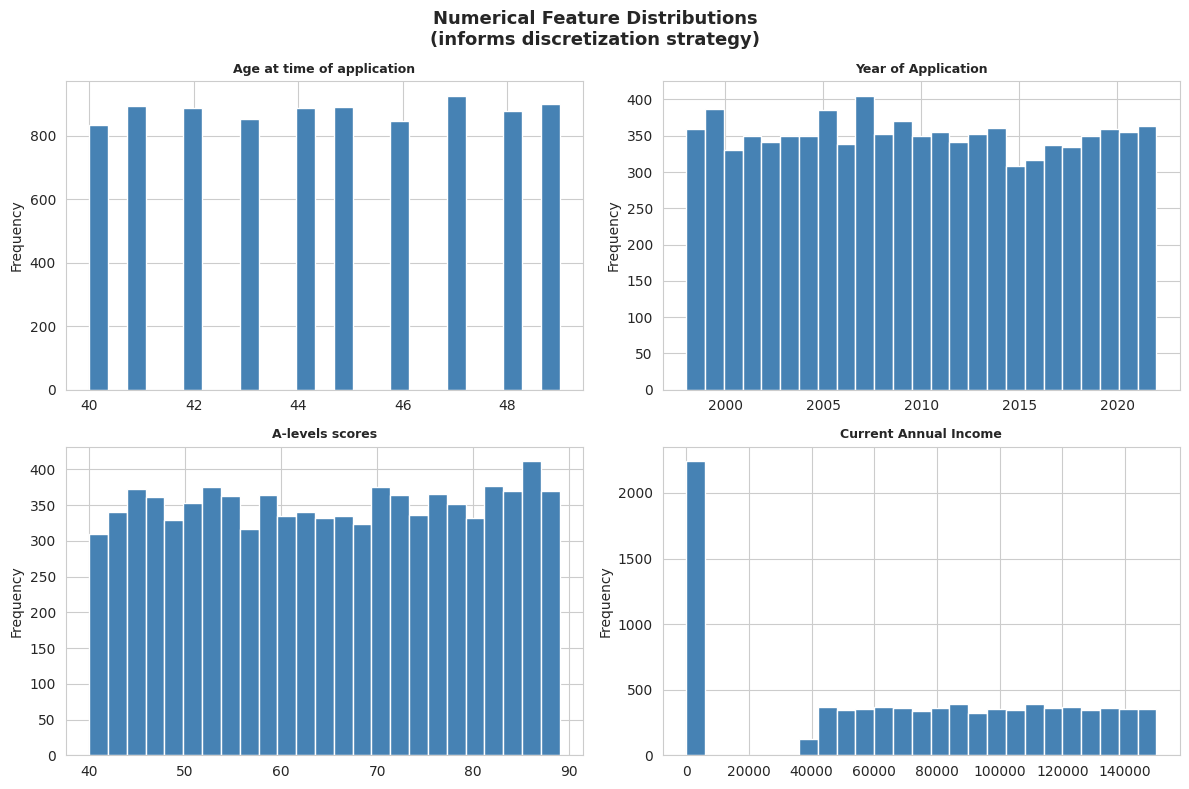


Distribution Notes:
  • Age, Year, A-levels:     Roughly uniform -> equal-width discretization
  • Current Annual Income:   Right-skewed (many zeros = unemployed) -> quantile discretization



In [34]:
num_cols = ['Age at time of application', 'Year of Application',
            'A-levels scores', 'Current Annual Income']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # important for easy iteration

for ax, col in zip(axes, num_cols):
    df[col].hist(ax=ax, bins=25, color='steelblue', edgecolor='white')
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_ylabel('Frequency')

plt.suptitle('Numerical Feature Distributions\n(informs discretization strategy)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Distribution Notes:
  • Age, Year, A-levels:     Roughly uniform -> equal-width discretization
  • Current Annual Income:   Right-skewed (many zeros = unemployed) -> quantile discretization
""")

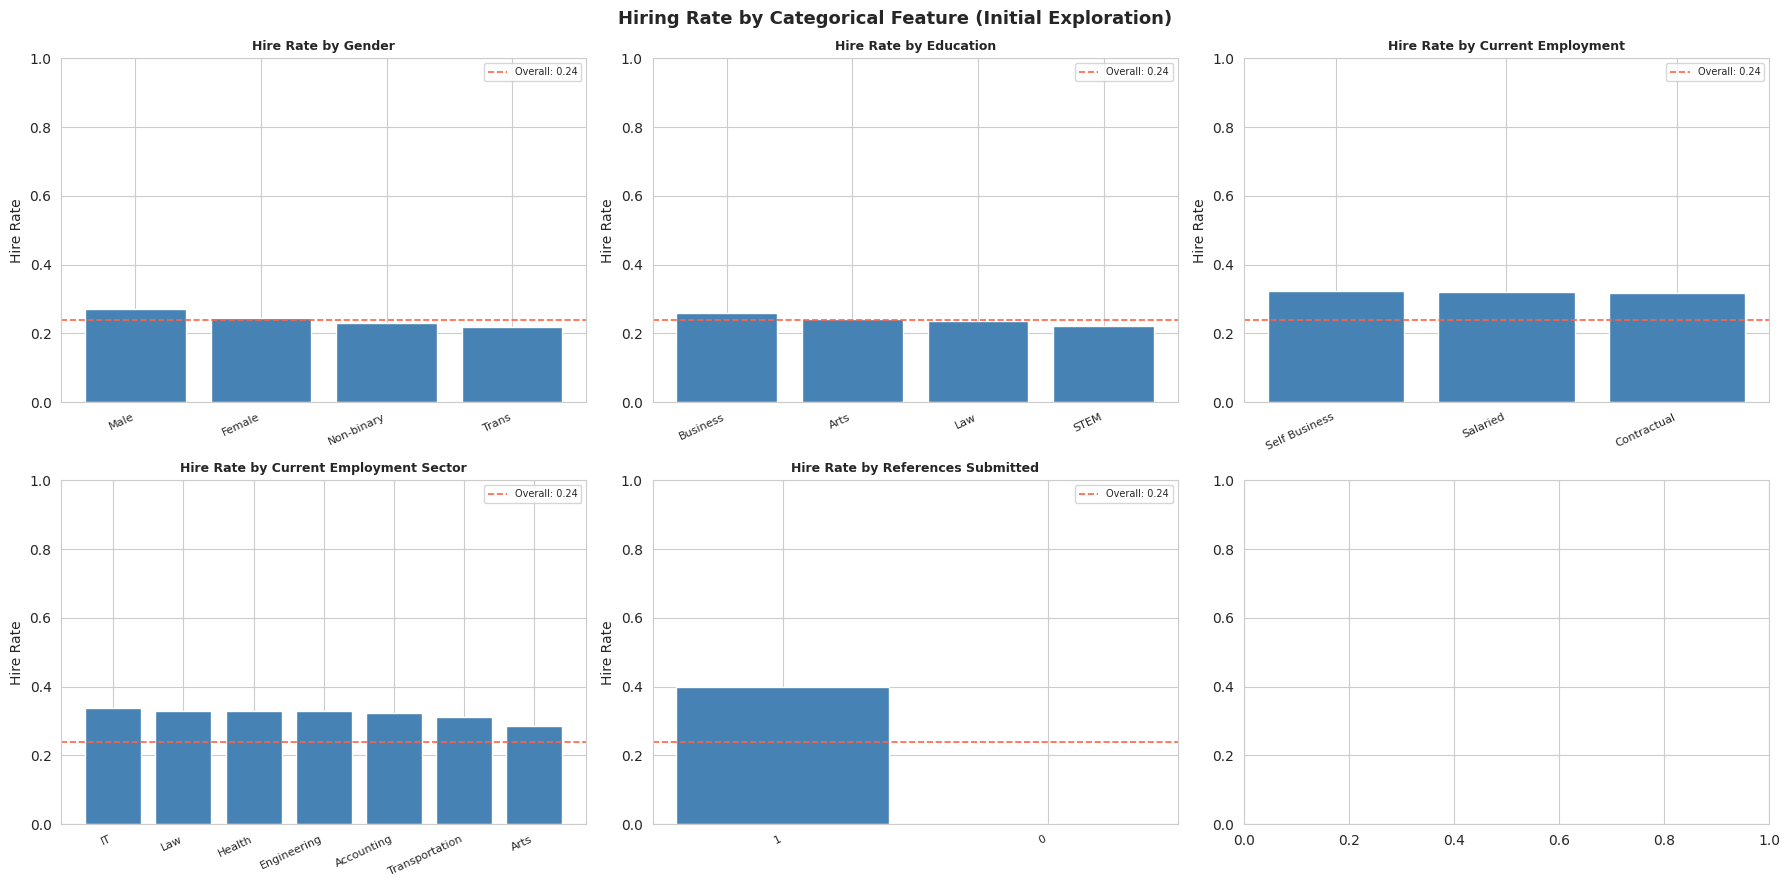

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
target = 'Was Hired by a Company within 6 months'

cat_explore = ['Gender', 'Education', 'Current Employment',
               'Current Employment Sector', 'References Submitted']

for ax, col in zip(axes, cat_explore):
    rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    bars = ax.bar(range(len(rate)), rate.values, color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Hire Rate')
    ax.set_title(f'Hire Rate by {col}', fontweight='bold', fontsize=9)
    ax.axhline(df[target].mean(), color='tomato', linestyle='--',
               linewidth=1.2, label=f'Overall: {df[target].mean():.2f}')
    ax.legend(fontsize=7)

plt.suptitle('Hiring Rate by Categorical Feature (Initial Exploration)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Cleaning — University Binning & Address Standardization

In [36]:
def clean_university(name):
    """Clean and standardize university names."""
    name = str(name).lower().strip()
    name = name.replace('universirt of cambridge', 'university of cambridge')
    name = re.sub(r'\(the\)', '', name)
    name = re.sub(r'^the\\s+', '', name)
    name = name.replace('&', 'and')
    name = name.replace('/', ' ')
    name = re.sub(r"[^\\w\\s]", "", name)
    name = re.sub(r'\\s+', ' ', name).strip()
    return name

def bin_university(name):
    """Bin universities into Elite/Strong/Other tiers."""
    name = clean_university(name)

    elite = [
        "university of oxford",
        "university of cambridge",
        "imperial college london",
        "university college london",
        "london school of economics and political science"
    ]

    strong = [
        "university of manchester",
        "university of bristol",
        "university of warwick",
        "university of edinburgh",
        "kings college london",
        "university of birmingham",
        "university of leeds",
        "university of sheffield",
        "university of nottingham",
        "university of southampton",
        "university of glasgow",
        "newcastle university",
        "cardiff university",
        "queen mary university of london",
        "durham university"
    ]

    if name in elite:
        return "Elite"
    elif name in strong:
        return "Strong"
    else:
        return "Other"

def clean_address(addr):
    """Clean and standardize address to county level."""
    addr = str(addr).lower().strip()
    addr = re.sub(r'^(city of |greater |county of )', '', addr)
    addr = re.sub(r'(city|county|district)$', '', addr)
    return addr.strip()

df['University_Tier'] = df['University Name'].apply(bin_university)
df['County_Clean'] = df['Address'].apply(clean_address)

print("University distribution after binning:")
print(df['University_Tier'].value_counts())
print("\nSample cleaned addresses:")
print(df[['Address', 'County_Clean']].head(10))

University distribution after binning:
University_Tier
Other    8800
Name: count, dtype: int64

Sample cleaned addresses:
           Address     County_Clean
0       Lancashire       lancashire
1    Pembrokeshire    pembrokeshire
2   Cambridgeshire   cambridgeshire
3           Armagh           armagh
4        Wiltshire        wiltshire
5       Lancashire       lancashire
6       Shropshire       shropshire
7  South Yorkshire  south yorkshire
8          Cumbria          cumbria
9     Warwickshire     warwickshire


## FIX Missing Value Imputation (Before Discretization)

In [37]:
imputer = SimpleImputer(strategy='median')

num_cols = ['Age at time of application', 'Year of Application',
            'A-levels scores', 'Current Annual Income']

print("Missing values before imputation:")
for col in num_cols:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        print(f"  {col}: {missing_count} ({missing_count/len(df)*100:.1f}%)")

for col in num_cols:
    df[col] = imputer.fit_transform(df[[col]]).flatten()

print("\nMissing values after imputation:")
print(df[num_cols].isnull().sum().sum())
print("All numerical columns imputed (median strategy)")

Missing values before imputation:

Missing values after imputation:
0
All numerical columns imputed (median strategy)


## Discretization with Dynamic Label Generation


In [38]:
disc_config = {
    'Age at time of application': {
        'n_bins': 3,
        'strategy': 'uniform',
        'label_prefix': 'Age'
    },
    'Year of Application': {
        'n_bins': 4,
        'strategy': 'uniform',
        'label_prefix': 'Year'
    },
    'A-levels scores': {
        'n_bins': 4,
        'strategy': 'uniform',
        'label_prefix': 'ALevel'
    },
    'Current Annual Income': {
        'n_bins': 4,
        'strategy': 'quantile',
        'label_prefix': 'Income'
    },
}

disc_results = {}
disc_series = {}

for col, cfg in disc_config.items():
    kbd = KBinsDiscretizer(
        n_bins=cfg['n_bins'],
        encode='ordinal',
        strategy=cfg['strategy'],
        subsample=None
    )
    bin_idx = kbd.fit_transform(df[[col]]).flatten().astype(int)
    edges = np.round(kbd.bin_edges_[0], 1)

    labels = [f"{cfg['label_prefix']}_{i}_{edges[i]:.0f}-{edges[i+1]:.0f}"
              for i in range(len(edges)-1)]

    disc_results[col] = {'encoder': kbd, 'labels': labels, 'edges': edges}
    disc_series[col] = pd.Series(
        [labels[i] for i in bin_idx],
        index=df.index,
        name=col
    )

    print(f"{col}")
    print(f"  strategy={cfg['strategy']} | n_bins={cfg['n_bins']}")
    print(f"  bin_edges={edges}")
    print(f"  labels = {labels}")
    print()

df_disc = pd.DataFrame(disc_series)
print("Discretization complete with dynamically computed labels")
df_disc.head()

Age at time of application
  strategy=uniform | n_bins=3
  bin_edges=[40. 43. 46. 49.]
  labels = ['Age_0_40-43', 'Age_1_43-46', 'Age_2_46-49']

Year of Application
  strategy=uniform | n_bins=4
  bin_edges=[1998. 2004. 2010. 2016. 2022.]
  labels = ['Year_0_1998-2004', 'Year_1_2004-2010', 'Year_2_2010-2016', 'Year_3_2016-2022']

A-levels scores
  strategy=uniform | n_bins=4
  bin_edges=[40.  52.2 64.5 76.8 89. ]
  labels = ['ALevel_0_40-52', 'ALevel_1_52-64', 'ALevel_2_64-77', 'ALevel_3_77-89']

Current Annual Income
  strategy=quantile | n_bins=4
  bin_edges=[     0.   76253.  112890.8 149988. ]
  labels = ['Income_0_0-76253', 'Income_1_76253-112891', 'Income_2_112891-149988']

Discretization complete with dynamically computed labels


,Age at time of application,Year of Application,A-levels scores,Current Annual Income
0,Age_0_40-43,Year_1_2004-2010,ALevel_3_77-89,Income_0_0-76253
1,Age_2_46-49,Year_0_1998-2004,ALevel_0_40-52,Income_2_112891-149988
2,Age_2_46-49,Year_1_2004-2010,ALevel_3_77-89,Income_0_0-76253
3,Age_0_40-43,Year_0_1998-2004,ALevel_0_40-52,Income_1_76253-112891
4,Age_0_40-43,Year_0_1998-2004,ALevel_2_64-77,Income_0_0-76253


## Build Transaction Dataset

In [39]:
def build_transactions(df_orig, df_disc):
    transactions = []

    for idx in df_orig.index:
        row = df_orig.loc[idx]
        disc = df_disc.loc[idx]
        items = []

        items.append(f"Gender={row['Gender']}")
        items.append(f"Education={row['Education']}")
        items.append(f"CurrEmp={row['Current Employment']}")
        items.append(f"CurrSector={row['Current Employment Sector']}")

        items.append(f"UniTier={row['University_Tier']}")

        items.append(f"County={row['County_Clean']}")

        # References
        ref_val = 'RefsYes' if row['References Submitted'] == 1 else 'RefsNo'
        items.append(ref_val)

        items.append(f"Age={disc['Age at time of application']}")
        items.append(f"Year={disc['Year of Application']}")
        items.append(f"Alevels={disc['A-levels scores']}")
        items.append(f"Income={disc['Current Annual Income']}")

        ref_emp_types = []
        for ref_col in ['Refree 1', 'Refree 2', 'Refree 3']:
            val = row[ref_col]

            if pd.isna(val) or not isinstance(val, str):
                continue
            elif ':' not in str(val):
                ref_emp_types.append('Unknown')
            else:
                try:
                    emp_part = str(val).split(':')[0].strip().replace(' ', '_')
                    ref_emp_types.append(emp_part)
                except:
                    ref_emp_types.append('ParseError')

        if len(ref_emp_types) > 0:
            for ref_type in ref_emp_types:
                items.append(f"RefEmpType={ref_type}")
        else:
            items.append('RefEmpType=NotProvided')

        # Target
        hired = row['Was Hired by a Company within 6 months']
        items.append('Hired=Yes' if hired == 1 else 'Hired=No')

        transactions.append(items)

    return transactions


transactions = build_transactions(df, df_disc)

print(f"Total transactions: {len(transactions)}")
print(f"\nSample — record 0:")
print(transactions[0])
print(f"\nSample — record 1:")
print(transactions[1])
print(f"\n✓ Transactions built with:")
print(f"  - Explicit missing referee handling")
print(f"  - Binned university tier (Elite/Strong/Other)")
print(f"  - Cleaned address data")
print(f"  - Malformed data handling")

Total transactions: 8800

Sample — record 0:
['Gender=Female', 'Education=Law', 'CurrEmp=Salaried', 'CurrSector=Law', 'UniTier=Other', 'County=lancashire', 'RefsYes', 'Age=Age_0_40-43', 'Year=Year_1_2004-2010', 'Alevels=ALevel_3_77-89', 'Income=Income_0_0-76253', 'RefEmpType=Self_Business', 'RefEmpType=Salaried', 'RefEmpType=Contractual', 'Hired=Yes']

Sample — record 1:
['Gender=Non-binary', 'Education=Arts', 'CurrEmp=Contractual', 'CurrSector=Arts', 'UniTier=Other', 'County=pembrokeshire', 'RefsNo', 'Age=Age_2_46-49', 'Year=Year_0_1998-2004', 'Alevels=ALevel_0_40-52', 'Income=Income_2_112891-149988', 'RefEmpType=NotProvided', 'Hired=No']

✓ Transactions built with:
  - Explicit missing referee handling
  - Binned university tier (Elite/Strong/Other)
  - Cleaned address data
  - Malformed data handling


## Convert to Transaction Matrix

In [40]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f"Transaction matrix shape: {df_te.shape}")
print(f"Number of unique items: {len(te.columns_)}")
print(f"\nAll items:")
for item in sorted(te.columns_):
    print(f"  {item}")

Transaction matrix shape: (8800, 138)
Number of unique items: 138

All items:
  Age=Age_0_40-43
  Age=Age_1_43-46
  Age=Age_2_46-49
  Alevels=ALevel_0_40-52
  Alevels=ALevel_1_52-64
  Alevels=ALevel_2_64-77
  Alevels=ALevel_3_77-89
  County=aberdeen
  County=aberdeenshire
  County=anglesey
  County=angus
  County=antrim
  County=argyll and bute
  County=armagh
  County=bedfordshire
  County=berkshire
  County=breconshire
  County=buckinghamshire
  County=caernarvonshire
  County=cambridgeshire
  County=cardiganshire
  County=carmarthenshire
  County=cheshire
  County=clackmannanshire
  County=cleveland
  County=cornwall
  County=cumbria
  County=denbighshire
  County=derbyshire
  County=derry and londonderry
  County=devon
  County=dorset
  County=down
  County=dumfries and galloway
  County=dundee
  County=durham
  County=east ayrshire
  County=east dunbartonshire
  County=east lothian
  County=east renfrewshire
  County=east sussex
  County=edinburgh
  County=eilean siar
  County=ess

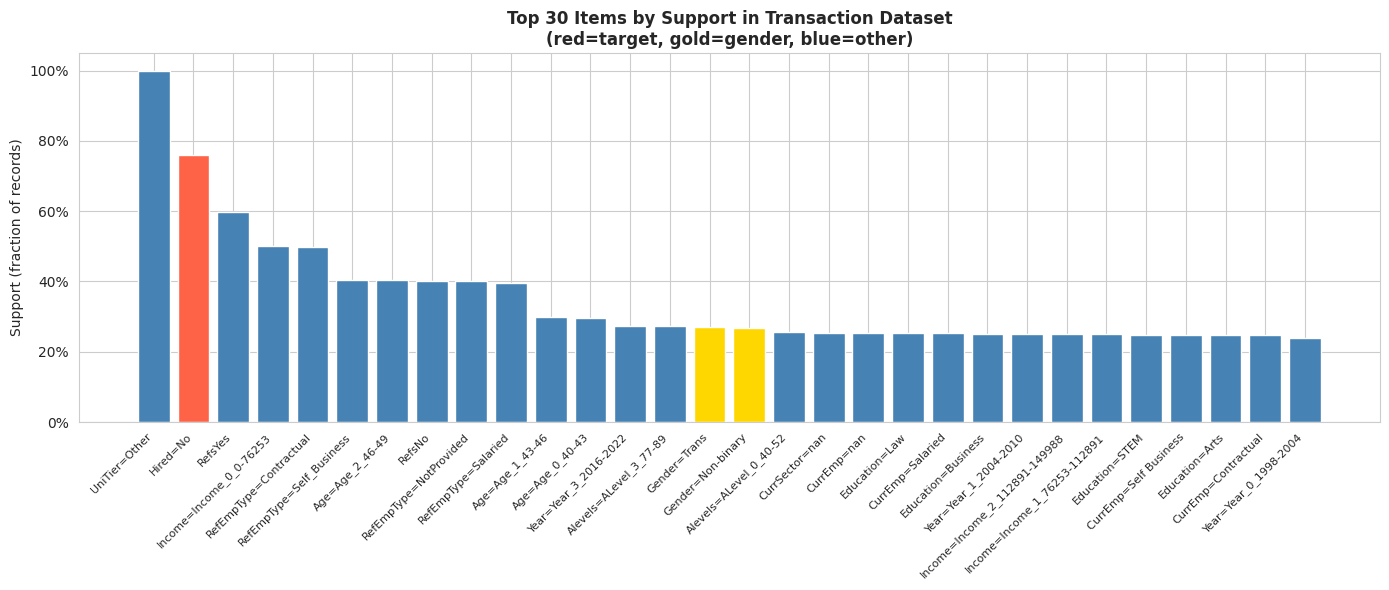

In [41]:
item_freq = df_te.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
top_items = item_freq.head(30)
colors = ['tomato' if 'Hired' in i else
          'gold' if 'Gender' in i else
          'steelblue' for i in top_items.index]
ax.bar(range(len(top_items)), top_items.values / len(df_te), color=colors, edgecolor='white')
ax.set_xticks(range(len(top_items)))
ax.set_xticklabels(top_items.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Support (fraction of records)')
ax.set_title('Top 30 Items by Support in Transaction Dataset\n'
             '(red=target, gold=gender, blue=other)',
             fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## Mine Frequent Itemsets using Apriori

In [42]:
from mlxtend.frequent_patterns import apriori

MIN_SUPPORT = 0.05

frequent_itemsets = apriori(
    df_te,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=4
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print(f"\nBreakdown by itemset size:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())
print()
frequent_itemsets.sort_values('support', ascending=False).head(15)

Frequent itemsets found: 3473

Breakdown by itemset size:
length
1      43
2     596
3    1420
4    1414



datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


,support,itemsets,length
38,1.000000,(UniTier=Other),1
548,0.760227,"(Hired=No, UniTier=Other)",2
27,0.760227,(Hired=No),1
630,0.598864,"(UniTier=Other, RefsYes)",2
37,0.598864,(RefsYes),1
571,0.500000,"(UniTier=Other, Income=Income_0_0-76253)",2
29,0.500000,(Income=Income_0_0-76253),1
601,0.499205,"(UniTier=Other, RefEmpType=Contractual)",2
600,0.499205,"(RefsYes, RefEmpType=Contractual)",2
32,0.499205,(RefEmpType=Contractual),1


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

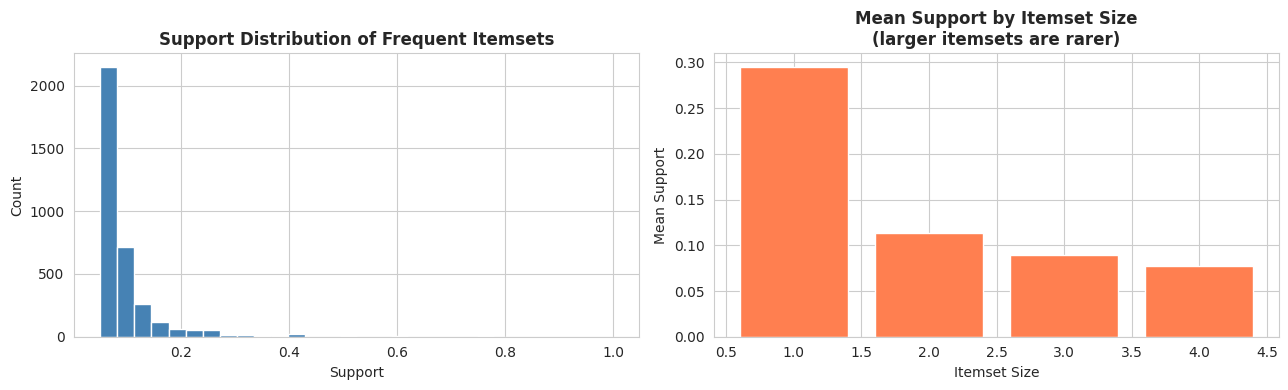

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

frequent_itemsets['support'].hist(ax=axes[0], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Count')
axes[0].set_title('Support Distribution of Frequent Itemsets', fontweight='bold')

freq_by_len = frequent_itemsets.groupby('length')['support'].mean()
axes[1].bar(freq_by_len.index, freq_by_len.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Itemset Size')
axes[1].set_ylabel('Mean Support')
axes[1].set_title('Mean Support by Itemset Size\n(larger itemsets are rarer)', fontweight='bold')

plt.tight_layout()
plt.show()

## Generate Rules with Validated Confidence Threshold

In [44]:
from mlxtend.frequent_patterns import association_rules

print("=" * 80)
print("SENSITIVITY ANALYSIS: Effect of min_confidence Threshold")
print("=" * 80)

conf_thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
results_conf = []

for conf in conf_thresholds:
    r = association_rules(frequent_itemsets, metric='confidence', min_threshold=conf)
    if len(r) > 0:
        r_hired = r[r['consequents'].apply(lambda x: 'Hired=Yes' in x)]
        results_conf.append({
            'min_confidence': conf,
            'total_rules': len(r),
            'hired_rules': len(r_hired),
            'avg_lift': r['lift'].mean(),
            'median_conf': r['confidence'].median(),
        })
    else:
        results_conf.append({
            'min_confidence': conf,
            'total_rules': 0,
            'hired_rules': 0,
            'avg_lift': np.nan,
            'median_conf': np.nan,
        })

conf_results_df = pd.DataFrame(results_conf)
print(conf_results_df.to_string(index=False))
print(f"\n Analysis shows trade-off between rule count and quality")
print(f" Using min_confidence=0.55 as balance between coverage and confidence")

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

SENSITIVITY ANALYSIS: Effect of min_confidence Threshold


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

 min_confidence  total_rules  hired_rules  avg_lift  median_conf
           0.40        10524          516  1.590472     0.735632
           0.45         9174          349  1.623929     0.802795
           0.50         8305          271  1.656415     0.873148
           0.55         7073          225  1.709493     0.930368
           0.60         6450          182  1.736077     1.000000
           0.65         5768          168  1.758422     1.000000
           0.70         5411          163  1.758175     1.000000

 Analysis shows trade-off between rule count and quality
 Using min_confidence=0.55 as balance between coverage and confidence


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

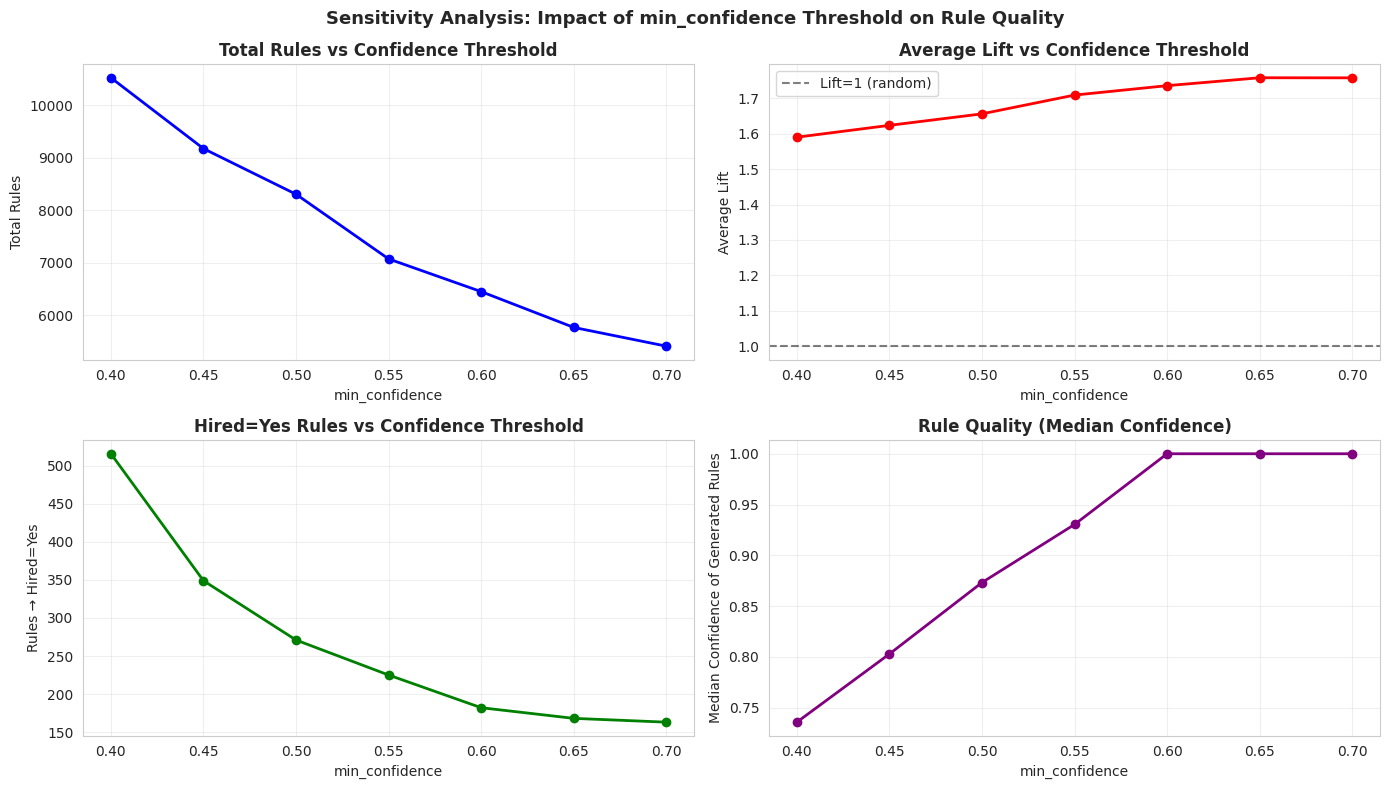

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [45]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Count of rules
axes[0, 0].plot(conf_results_df['min_confidence'], conf_results_df['total_rules'], 'b-o', linewidth=2)
axes[0, 0].set_xlabel('min_confidence')
axes[0, 0].set_ylabel('Total Rules')
axes[0, 0].set_title('Total Rules vs Confidence Threshold', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Average lift
axes[0, 1].plot(conf_results_df['min_confidence'], conf_results_df['avg_lift'], 'r-o', linewidth=2)
axes[0, 1].set_xlabel('min_confidence')
axes[0, 1].set_ylabel('Average Lift')
axes[0, 1].set_title('Average Lift vs Confidence Threshold', fontweight='bold')
axes[0, 1].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Lift=1 (random)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Hired rules
axes[1, 0].plot(conf_results_df['min_confidence'], conf_results_df['hired_rules'], 'g-o', linewidth=2)
axes[1, 0].set_xlabel('min_confidence')
axes[1, 0].set_ylabel('Rules → Hired=Yes')
axes[1, 0].set_title('Hired=Yes Rules vs Confidence Threshold', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Median confidence
axes[1, 1].plot(conf_results_df['min_confidence'], conf_results_df['median_conf'], 'purple', marker='o', linewidth=2)
axes[1, 1].set_xlabel('min_confidence')
axes[1, 1].set_ylabel('Median Confidence of Generated Rules')
axes[1, 1].set_title('Rule Quality (Median Confidence)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Sensitivity Analysis: Impact of min_confidence Threshold on Rule Quality',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
MIN_CONFIDENCE = 0.55
MIN_LIFT = 1.2

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

rules = rules[rules['lift'] >= MIN_LIFT].copy()
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Total rules generated (confidence≥{MIN_CONFIDENCE}, lift≥{MIN_LIFT}): {len(rules)}")
print(f"\nTop 15 rules by lift:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string())

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

Total rules generated (confidence≥0.55, lift≥1.2): 4765

Top 15 rules by lift:
                                   antecedents                                 consequents   support  confidence      lift
0                       (CurrEmp=nan, RefsYes)       (RefEmpType=Salaried, CurrSector=nan)  0.076705    0.625000  8.148148
1   (RefEmpType=Self_Business, CurrSector=nan)                      (CurrEmp=nan, RefsYes)  0.082727    1.000000  8.148148
2                       (CurrEmp=nan, RefsYes)    (RefEmpType=Contractual, CurrSector=nan)  0.090795    0.739815  8.148148
3        (CurrEmp=nan, RefEmpType=Contractual)                   (RefsYes, CurrSector=nan)  0.090795    1.000000  8.148148
4           (CurrEmp=nan, RefEmpType=Salaried)                   (RefsYes, CurrSector=nan)  0.076705    1.000000  8.148148
5     (RefEmpType=Contractual, CurrSector=nan)                      (CurrEmp=nan, RefsYes)  0.090795    1.000000  8.148148
6                    (RefsYes, CurrSector=nan)          (Cur

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


## Rule Filtering and Analysis Functions

In [47]:
def fmt_rule(row, decimals=3):
    ant = ', '.join(sorted(row['antecedents']))
    con = ', '.join(sorted(row['consequents']))
    return (f"IF {{{ant}}}\n"
            f"   THEN {{{con}}}\n"
            f"   [sup={row['support']:.{decimals}f}, "
            f"conf={row['confidence']:.{decimals}f}, "
            f"lift={row['lift']:.{decimals}f}]")

def filter_rules(rules, consequent_item=None, antecedent_contains=None, min_lift=1.0):
    """Flexible rule filter."""
    r = rules.copy()
    if consequent_item:
        r = r[r['consequents'].apply(lambda x: consequent_item in x)]
    if antecedent_contains:
        r = r[r['antecedents'].apply(
            lambda x: any(antecedent_contains in item for item in x)
        )]
    r = r[r['lift'] >= min_lift]
    return r

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

## Rules Predicting Hired=Yes vs Hired=No

In [48]:
rules_hired = filter_rules(rules, consequent_item='Hired=Yes', min_lift=MIN_LIFT)
rules_not_hired = filter_rules(rules, consequent_item='Hired=No', min_lift=MIN_LIFT)

print(f"Rules predicting Hired=Yes : {len(rules_hired)}")
print(f"Rules predicting Hired=No  : {len(rules_not_hired)}")

print("\n" + "=" * 80)
print("TOP 10 RULES — HIRED=YES (ordered by lift)")
print("=" * 80)
for _, row in rules_hired.head(10).iterrows():
    print(fmt_rule(row))
    print()

Rules predicting Hired=Yes : 225
Rules predicting Hired=No  : 869

TOP 10 RULES — HIRED=YES (ordered by lift)
IF {Alevels=ALevel_3_77-89, CurrEmp=Salaried, RefEmpType=Self_Business}
   THEN {Hired=Yes}
   [sup=0.055, conf=0.953, lift=3.975]

IF {Alevels=ALevel_3_77-89, CurrEmp=Self Business, RefEmpType=Self_Business}
   THEN {Hired=Yes}
   [sup=0.052, conf=0.950, lift=3.963]

IF {Alevels=ALevel_3_77-89, CurrEmp=Salaried, RefEmpType=Salaried}
   THEN {Hired=Yes}
   [sup=0.054, conf=0.948, lift=3.954]

IF {Alevels=ALevel_3_77-89, CurrEmp=Contractual, RefEmpType=Self_Business}
   THEN {Hired=Yes}
   [sup=0.052, conf=0.944, lift=3.937]

IF {Alevels=ALevel_3_77-89, CurrEmp=Self Business, RefEmpType=Salaried}
   THEN {Hired=Yes}
   [sup=0.051, conf=0.937, lift=3.909]

IF {Alevels=ALevel_3_77-89, RefEmpType=Salaried, RefEmpType=Self_Business}
   THEN {Hired=Yes}
   [sup=0.104, conf=0.937, lift=3.907]

IF {Alevels=ALevel_3_77-89, CurrEmp=Contractual, RefEmpType=Salaried}
   THEN {Hired=Yes}
  

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

In [49]:
print("=" * 80)
print("TOP 10 RULES — HIRED=NO (ordered by lift)")
print("=" * 80)
for _, row in rules_not_hired.head(10).iterrows():
    print(fmt_rule(row))
    print()

TOP 10 RULES — HIRED=NO (ordered by lift)
IF {CurrEmp=nan, Education=Business}
   THEN {CurrSector=nan, Hired=No}
   [sup=0.062, conf=1.000, lift=3.957]

IF {CurrSector=nan, Education=Business}
   THEN {CurrEmp=nan, Hired=No}
   [sup=0.062, conf=1.000, lift=3.957]

IF {Age=Age_2_46-49, CurrSector=nan}
   THEN {CurrEmp=nan, Hired=No}
   [sup=0.102, conf=1.000, lift=3.957]

IF {Age=Age_2_46-49, CurrEmp=nan}
   THEN {CurrSector=nan, Hired=No}
   [sup=0.102, conf=1.000, lift=3.957]

IF {CurrSector=nan, Education=STEM}
   THEN {CurrEmp=nan, Hired=No}
   [sup=0.064, conf=1.000, lift=3.957]

IF {Alevels=ALevel_1_52-64, CurrEmp=nan}
   THEN {CurrSector=nan, Hired=No}
   [sup=0.075, conf=1.000, lift=3.957]

IF {Alevels=ALevel_1_52-64, CurrSector=nan}
   THEN {CurrEmp=nan, Hired=No}
   [sup=0.075, conf=1.000, lift=3.957]

IF {CurrEmp=nan, Education=Law}
   THEN {CurrSector=nan, Hired=No}
   [sup=0.063, conf=1.000, lift=3.957]

IF {CurrSector=nan, Education=Law}
   THEN {CurrEmp=nan, Hired=No}
  

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

## Visualisations

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

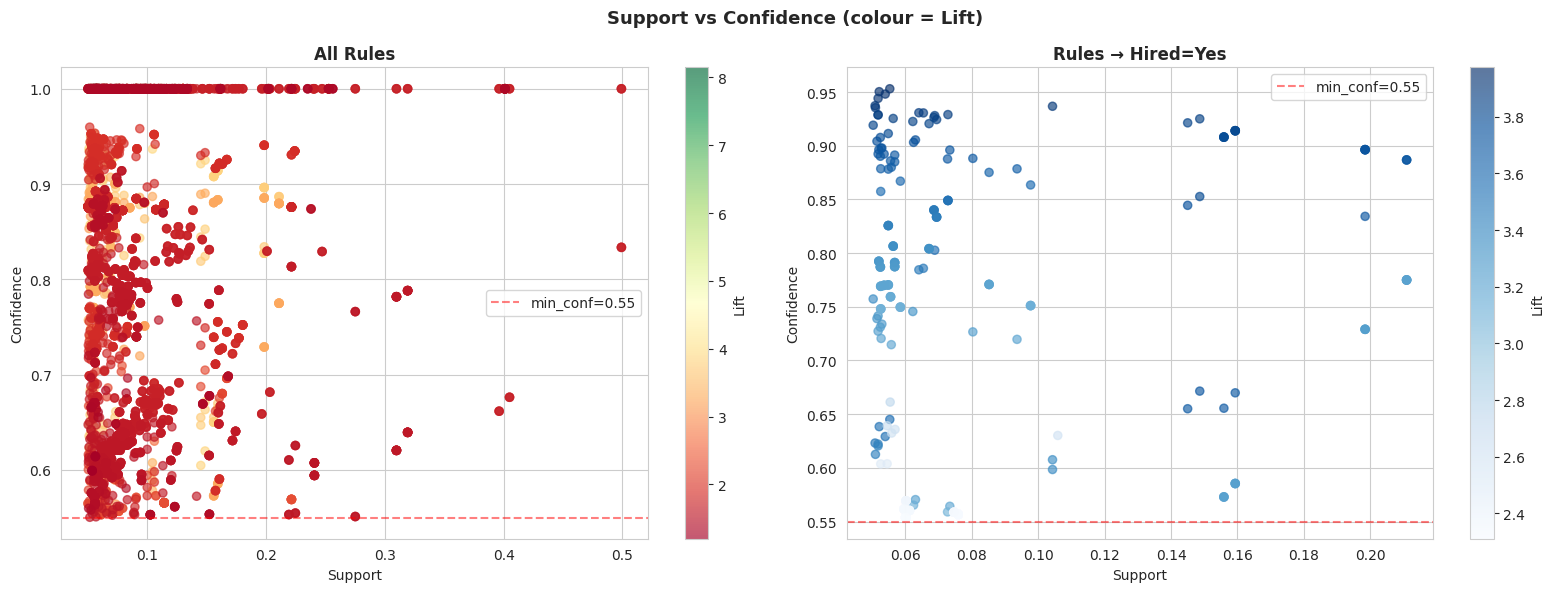

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, rule_set, title, cmap in [
    (axes[0], rules,        'All Rules',      'RdYlGn'),
    (axes[1], rules_hired,  'Rules → Hired=Yes', 'Blues'),
]:
    if len(rule_set) == 0:
        ax.text(0.5, 0.5, 'No rules', ha='center', va='center')
        continue
    sc = ax.scatter(
        rule_set['support'], rule_set['confidence'],
        c=rule_set['lift'], cmap=cmap, alpha=0.65, s=35
    )
    plt.colorbar(sc, ax=ax, label='Lift')
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_title(title, fontweight='bold')
    ax.axhline(MIN_CONFIDENCE, color='red', linestyle='--', alpha=0.5, label=f'min_conf={MIN_CONFIDENCE}')
    ax.legend()

plt.suptitle('Support vs Confidence (colour = Lift)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

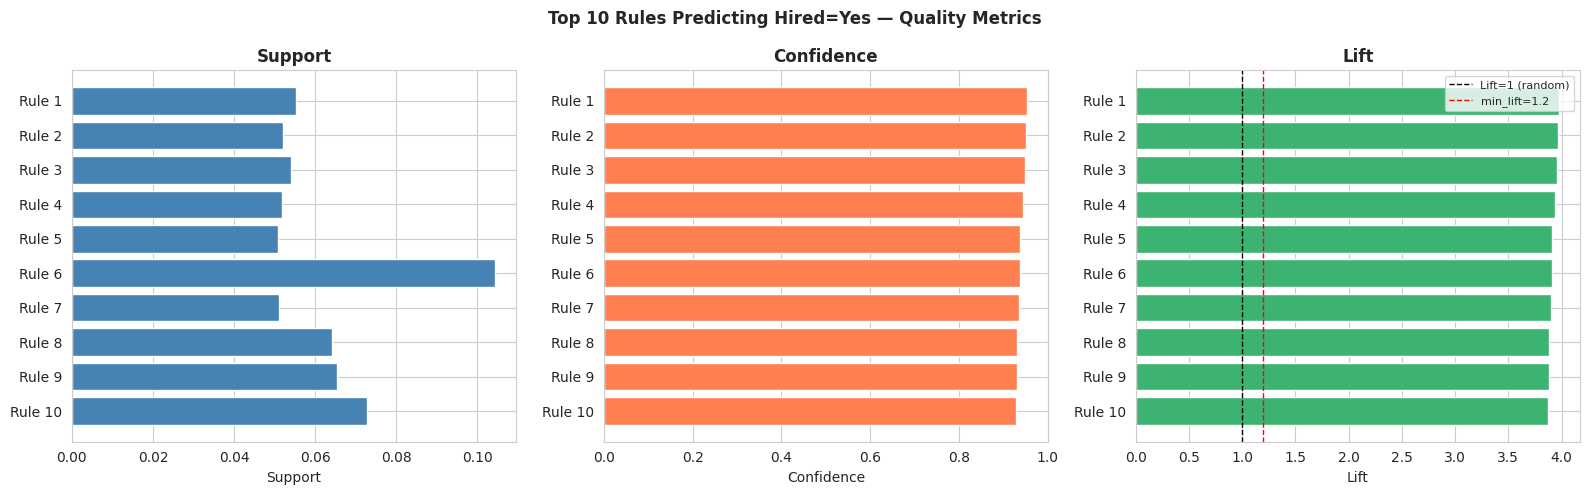

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


In [51]:
top10 = rules_hired.head(10).copy().reset_index(drop=True)
top10['label'] = [f"Rule {i+1}" for i in range(len(top10))]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, color in zip(axes,
                              ['support', 'confidence', 'lift'],
                              ['steelblue', 'coral', 'mediumseagreen']):
    ax.barh(top10['label'], top10[metric], color=color, edgecolor='white')
    ax.set_xlabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()}', fontweight='bold')
    ax.invert_yaxis()
    if metric == 'lift':
        ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='Lift=1 (random)')
        ax.axvline(MIN_LIFT, color='red', linestyle='--', linewidth=1, label=f'min_lift={MIN_LIFT}')
        ax.legend(fontsize=8)

plt.suptitle('Top 10 Rules Predicting Hired=Yes — Quality Metrics',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. CLASSIFICATION ANALYSIS

In [52]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versio

## Data Preprocessing

In [56]:
def prepare_dataset(df, dataset_name):
    """Prepare dataset: one-hot encode categoricals and split into X, y"""
    print(f"\n{'='*60}")
    print(f"Preparing {dataset_name}")
    print(f"{'='*60}")

    df_temp = df.copy()

    target_col = 'Was Hired by a Company within 6 months'

    categorical_cols = df_temp.select_dtypes(include=['object']).columns.tolist()
    if target_col in categorical_cols:
        categorical_cols.remove(target_col)

    print(f"Categorical columns to encode: {categorical_cols}")

    df_temp = pd.get_dummies(df_temp, columns=categorical_cols, drop_first=True)

    X = df_temp.drop(target_col, axis=1)
    y = df_temp[target_col]

    print(f"Features: {list(X.columns)}")
    print(f"Target distribution:\n{y.value_counts()}")
    print(f"Feature matrix shape: {X.shape}")

    return X, y

X_raw, y_raw = prepare_dataset(df_raw, 'Raw Dataset')
X_eng, y_eng = prepare_dataset(df_bin_uni_scaled_final, 'Engineered Dataset')


Preparing Raw Dataset
Categorical columns to encode: ['Education', 'Current Employment', 'Current Employment Sector']
Features: ['A-levels scores', 'Current Annual Income', 'References Submitted', 'Education_business', 'Education_law', 'Education_stem', 'Current Employment_salaried', 'Current Employment_self business', 'Current Employment_unemployed', 'Current Employment Sector_arts', 'Current Employment Sector_engineering', 'Current Employment Sector_health', 'Current Employment Sector_it', 'Current Employment Sector_law', 'Current Employment Sector_transportation', 'Current Employment Sector_unemployed']
Target distribution:
Was Hired by a Company within 6 months
0    6690
1    2110
Name: count, dtype: int64
Feature matrix shape: (8800, 16)

Preparing Engineered Dataset
Categorical columns to encode: ['University Tier']
Features: ['A-levels scores', 'Current Annual Income', 'References Submitted', 'Is_Employed', 'Education_business', 'Education_law', 'Education_stem', 'University Ti

In [57]:
def split_data(X, y, test_size=0.2, val_size=0.2, random_state=42):
    """Split data into train/validation/test sets"""
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

# Split both datasets
X_train_raw, X_val_raw, X_test_raw, y_train_raw, y_val_raw, y_test_raw = split_data(X_raw, y_raw)
X_train_eng, X_val_eng, X_test_eng, y_train_eng, y_val_eng, y_test_eng = split_data(X_eng, y_eng)

print(f"\n{'='*60}")
print("Train/Validation/Test Split Summary")
print(f"{'='*60}")
print(f"Training set size: {len(X_train_raw)}")
print(f"Validation set size: {len(X_val_raw)}")
print(f"Test set size: {len(X_test_raw)}")
print(f"Total: {len(X_train_raw) + len(X_val_raw) + len(X_test_raw)}")


Train/Validation/Test Split Summary
Training set size: 5280
Validation set size: 1760
Test set size: 1760
Total: 8800


## Baseline Model Training (Default Parameters)

In [58]:
def train_baseline_models_with_test(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    dataset_name
):
    """Train baseline models and evaluate CV, validation, and test performance"""

    baseline_models = {
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'XGBoost': XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss')
    }

    baseline_results = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print(f"\n{'='*70}")
    print(f"BASELINE MODELS (Default Parameters) - {dataset_name}")
    print(f"{'='*70}\n")

    for model_name, model in baseline_models.items():
        model.fit(X_train, y_train)

        cv_scores = cross_val_score(
            model, X_train, y_train,
            cv=cv, scoring='accuracy'
        )
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        val_score = model.score(X_val, y_val)
        test_score = model.score(X_test, y_test)

        baseline_results[model_name] = {
            'model': model,
            'cv_mean': cv_mean,
            'cv_std': cv_std,
            'val_score': val_score,
            'test_score': test_score
        }

        print(f"{model_name:20s} | "
              f"CV: {cv_mean:.4f} ± {cv_std:.4f} | "
              f"Val: {val_score:.4f} | "
              f"Test: {test_score:.4f}")

    print(f"\n{'='*70}")
    return baseline_results, baseline_models

baseline_results_raw, baseline_models_raw = train_baseline_models_with_test(
    X_train_raw, y_train_raw,
    X_val_raw, y_val_raw,
    X_test_raw, y_test_raw,
    "RAW DATASET"
)

baseline_results_eng, baseline_models_eng = train_baseline_models_with_test(
    X_train_eng, y_train_eng,
    X_val_eng, y_val_eng,
    X_test_eng, y_test_eng,
    "ENGINEERED DATASET"
)


BASELINE MODELS (Default Parameters) - RAW DATASET

Decision Tree        | CV: 0.9547 ± 0.0043 | Val: 0.9597 | Test: 0.9563
Random Forest        | CV: 0.9598 ± 0.0027 | Val: 0.9574 | Test: 0.9614
Gradient Boosting    | CV: 0.9568 ± 0.0042 | Val: 0.9591 | Test: 0.9608
XGBoost              | CV: 0.9547 ± 0.0046 | Val: 0.9619 | Test: 0.9608


BASELINE MODELS (Default Parameters) - ENGINEERED DATASET

Decision Tree        | CV: 0.9617 ± 0.0037 | Val: 0.9585 | Test: 0.9710
Random Forest        | CV: 0.9676 ± 0.0077 | Val: 0.9716 | Test: 0.9722
Gradient Boosting    | CV: 0.9733 ± 0.0020 | Val: 0.9750 | Test: 0.9739
XGBoost              | CV: 0.9657 ± 0.0048 | Val: 0.9693 | Test: 0.9710



## Hyperparameter Tuning

In [59]:
def perform_hyperparameter_tuning(X_train, y_train, X_val, y_val, X_test, y_test, dataset_name):
    dt_grid = RandomizedSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_distributions={'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 10, 50, 100], 'criterion': ['gini', 'entropy']},
        n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
    dt_grid.fit(X_train, y_train)

    rf_grid = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_distributions={'n_estimators': [50, 100, 200, 500], 'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 10, 50, 100], 'max_features': ['sqrt', 'log2', None]},
        n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
    rf_grid.fit(X_train, y_train)

    gb_grid = RandomizedSearchCV(
        estimator=GradientBoostingClassifier(random_state=42),
        param_distributions={'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [2, 3, 5], 'min_samples_split': [2, 10, 50]},
        n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
    gb_grid.fit(X_train, y_train)

    xgb_grid = RandomizedSearchCV(
        estimator=XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
        param_distributions={'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.6, 0.8, 1.0], 'colsample_bytree': [0.6, 0.8, 1.0]},
        n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
    xgb_grid.fit(X_train, y_train)

    print(f"\n{'='*70}")
    print(f"HYPERPARAMETER TUNING RESULTS - {dataset_name}")
    print(f"{'='*70}\n")

    models = {'Decision Tree': dt_grid, 'Random Forest': rf_grid, 'Gradient Boosting': gb_grid, 'XGBoost': xgb_grid}

    for model_name, model in models.items():
        print(f"{model_name}:")
        print(f"  Best parameters: {model.best_params_}")
        print(f"  Best CV score: {model.best_score_:.4f}")
        print(f"  Validation score: {model.score(X_val, y_val):.4f}")
        print(f"  Test score: {model.score(X_test, y_test):.4f}\n")

    print(f"{'='*70}")
    return dt_grid, rf_grid, gb_grid, xgb_grid

# CRITICAL: Call the tuning function
dt_grid_raw, rf_grid_raw, gb_grid_raw, xgb_grid_raw = perform_hyperparameter_tuning(X_train_raw, y_train_raw, X_val_raw, y_val_raw, X_test_raw, y_test_raw, 'RAW DATASET')
dt_grid_eng, rf_grid_eng, gb_grid_eng, xgb_grid_eng = perform_hyperparameter_tuning(X_train_eng, y_train_eng, X_val_eng, y_val_eng, X_test_eng, y_test_eng, 'ENGINEERED DATASET')

y_dt = dt_grid_raw.predict(X_test_raw)
y_rf = rf_grid_raw.predict(X_test_raw)
y_gb = gb_grid_raw.predict(X_test_raw)
y_xgb = xgb_grid_raw.predict(X_test_raw)

print("DT vs RF:", (y_dt == y_rf).mean())
print("DT vs GB:", (y_dt == y_gb).mean())
print("DT vs XGB:", (y_dt == y_xgb).mean())


HYPERPARAMETER TUNING RESULTS - RAW DATASET

Decision Tree:
  Best parameters: {'min_samples_split': 2, 'max_depth': 5, 'criterion': 'gini'}
  Best CV score: 0.9631
  Validation score: 0.9619
  Test score: 0.9614

Random Forest:
  Best parameters: {'n_estimators': 50, 'min_samples_split': 100, 'max_features': 'log2', 'max_depth': 5}
  Best CV score: 0.9633
  Validation score: 0.9619
  Test score: 0.9614

Gradient Boosting:
  Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 5, 'learning_rate': 0.01}
  Best CV score: 0.9631
  Validation score: 0.9619
  Test score: 0.9614

XGBoost:
  Best parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
  Best CV score: 0.9627
  Validation score: 0.9619
  Test score: 0.9614


HYPERPARAMETER TUNING RESULTS - ENGINEERED DATASET

Decision Tree:
  Best parameters: {'min_samples_split': 2, 'max_depth': 10, 'criterion': 'entropy'}
  Best CV score: 0.9735
  Validation

## Baseline vs Tuned Model Comparison

In [60]:
def compare_baseline_vs_tuned(baseline_results, grids, X_val, y_val, X_test, y_test, dataset_name):
    """Compare baseline and tuned models"""
    tuned_results = {}
    tuned_models = {
        'Decision Tree': grids[0].best_estimator_,
        'Random Forest': grids[1].best_estimator_,
        'Gradient Boosting': grids[2].best_estimator_,
        'XGBoost': grids[3].best_estimator_
    }

    grid_objects = {
        'Decision Tree': grids[0],
        'Random Forest': grids[1],
        'Gradient Boosting': grids[2],
        'XGBoost': grids[3]
    }

    for model_name, model in tuned_models.items():
        tuned_cv = grid_objects[model_name].best_score_
        val_score = model.score(X_val, y_val)
        test_score = model.score(X_test, y_test)

        baseline_cv = baseline_results[model_name]['cv_mean']
        improvement = (tuned_cv - baseline_cv) * 100

        tuned_results[model_name] = {
            'baseline_cv': baseline_cv,
            'tuned_cv': tuned_cv,
            'improvement': improvement,
            'val_score': val_score,
            'test_score': test_score,
            'model': model
        }

    comparison_df = pd.DataFrame([
        {
            'Model': model_name,
            'Baseline CV': f"{results['baseline_cv']:.4f}",
            'Tuned CV': f"{results['tuned_cv']:.4f}",
            'Improvement': f"{results['improvement']:+.2f}%",
            'Val Score': f"{results['val_score']:.4f}",
            'Test Score': f"{results['test_score']:.4f}"
        }
        for model_name, results in tuned_results.items()
    ])

    print(f"\n{'='*100}")
    print(f"BASELINE vs TUNED MODEL COMPARISON - {dataset_name}")
    print(f"{'='*100}\n")
    print(comparison_df.to_string(index=False))
    print(f"\n{'='*100}")

    return tuned_results, tuned_models

tuned_results_raw, tuned_models_raw = compare_baseline_vs_tuned(
    baseline_results_raw,
    [dt_grid_raw, rf_grid_raw, gb_grid_raw, xgb_grid_raw],
    X_val_raw, y_val_raw, X_test_raw, y_test_raw,
    'RAW DATASET'
)

tuned_results_eng, tuned_models_eng = compare_baseline_vs_tuned(
    baseline_results_eng,
    [dt_grid_eng, rf_grid_eng, gb_grid_eng, xgb_grid_eng],
    X_val_eng, y_val_eng, X_test_eng, y_test_eng,
    'ENGINEERED DATASET'
)


BASELINE vs TUNED MODEL COMPARISON - RAW DATASET

            Model Baseline CV Tuned CV Improvement Val Score Test Score
    Decision Tree      0.9547   0.9631      +0.83%    0.9619     0.9614
    Random Forest      0.9598   0.9633      +0.34%    0.9619     0.9614
Gradient Boosting      0.9568   0.9631      +0.63%    0.9619     0.9614
          XGBoost      0.9547   0.9627      +0.80%    0.9619     0.9614


BASELINE vs TUNED MODEL COMPARISON - ENGINEERED DATASET

            Model Baseline CV Tuned CV Improvement Val Score Test Score
    Decision Tree      0.9617   0.9735      +1.17%    0.9750     0.9750
    Random Forest      0.9676   0.9739      +0.63%    0.9750     0.9750
Gradient Boosting      0.9733   0.9741      +0.08%    0.9750     0.9756
          XGBoost      0.9657   0.9739      +0.81%    0.9744     0.9744



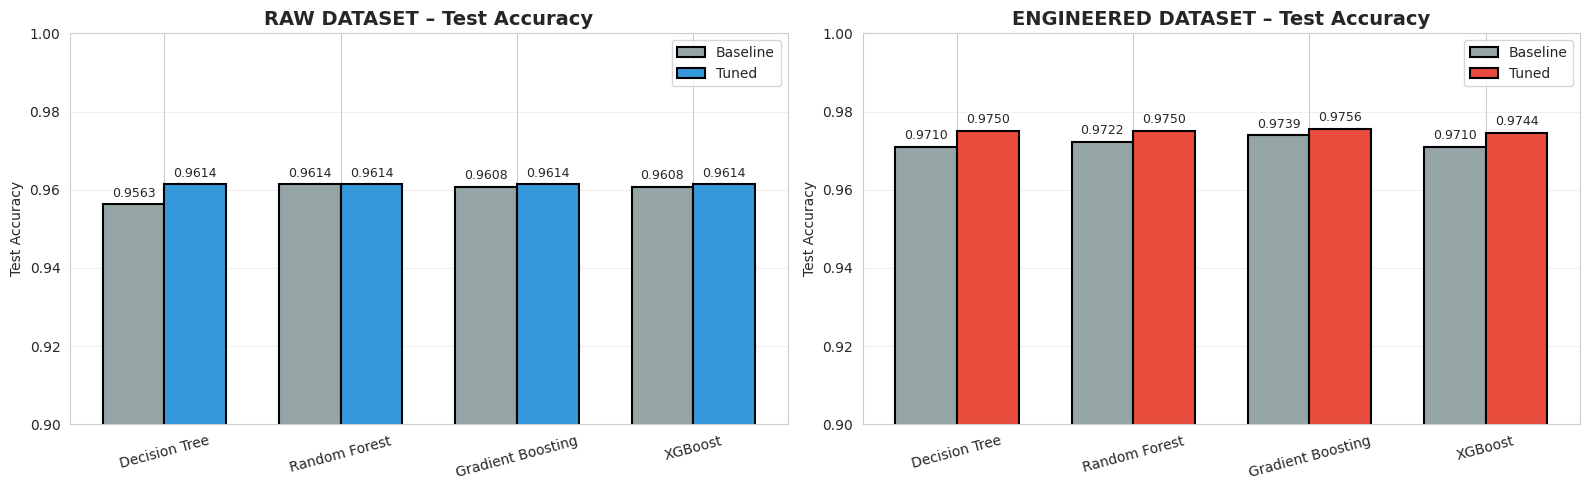

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_width = 0.35
x_offset = np.arange(len(tuned_results_raw))

models_raw = list(tuned_results_raw.keys())

baseline_scores_raw = [
    baseline_results_raw[m]['test_score'] for m in models_raw
]
tuned_scores_raw = [
    tuned_results_raw[m]['test_score'] for m in models_raw
]

axes[0].bar(
    x_offset - bar_width / 2,
    baseline_scores_raw,
    bar_width,
    label='Baseline',
    color='#95a5a6',
    edgecolor='black',
    linewidth=1.5
)

axes[0].bar(
    x_offset + bar_width / 2,
    tuned_scores_raw,
    bar_width,
    label='Tuned',
    color='#3498db',
    edgecolor='black',
    linewidth=1.5
)

axes[0].set_title('RAW DATASET – Test Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_xticks(x_offset)
axes[0].set_xticklabels(models_raw, rotation=15)
axes[0].set_ylim([0.90, 1.0])
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

for i, (b, t) in enumerate(zip(baseline_scores_raw, tuned_scores_raw)):
    axes[0].text(i - bar_width / 2, b + 0.002, f'{b:.4f}', ha='center', fontsize=9)
    axes[0].text(i + bar_width / 2, t + 0.002, f'{t:.4f}', ha='center', fontsize=9)


models_eng = list(tuned_results_eng.keys())

baseline_scores_eng = [
    baseline_results_eng[m]['test_score'] for m in models_eng
]
tuned_scores_eng = [
    tuned_results_eng[m]['test_score'] for m in models_eng
]

axes[1].bar(
    x_offset - bar_width / 2,
    baseline_scores_eng,
    bar_width,
    label='Baseline',
    color='#95a5a6',
    edgecolor='black',
    linewidth=1.5
)

axes[1].bar(
    x_offset + bar_width / 2,
    tuned_scores_eng,
    bar_width,
    label='Tuned',
    color='#e74c3c',
    edgecolor='black',
    linewidth=1.5
)

axes[1].set_title('ENGINEERED DATASET – Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_xticks(x_offset)
axes[1].set_xticklabels(models_eng, rotation=15)
axes[1].set_ylim([0.90, 1.0])
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

for i, (b, t) in enumerate(zip(baseline_scores_eng, tuned_scores_eng)):
    axes[1].text(i - bar_width / 2, b + 0.002, f'{b:.4f}', ha='center', fontsize=9)
    axes[1].text(i + bar_width / 2, t + 0.002, f'{t:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

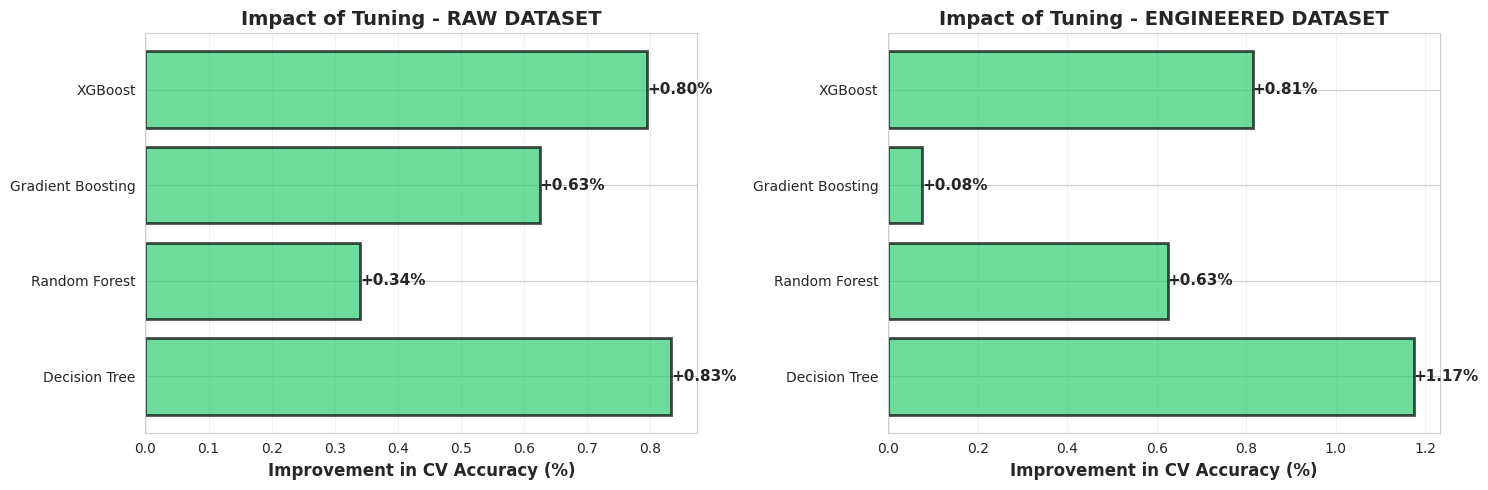

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models_raw = list(tuned_results_raw.keys())
improvements_raw = [tuned_results_raw[m]['improvement'] for m in models_raw]
colors_raw = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements_raw]

bars_raw = axes[0].barh(models_raw, improvements_raw, color=colors_raw, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_xlabel('Improvement in CV Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Impact of Tuning - RAW DATASET', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)
for bar, imp in zip(bars_raw, improvements_raw):
    width = bar.get_width()
    axes[0].text(width, bar.get_y() + bar.get_height()/2., f'{imp:+.2f}%',
                ha='left' if imp > 0 else 'right', va='center', fontsize=11, fontweight='bold')

models_eng = list(tuned_results_eng.keys())
improvements_eng = [tuned_results_eng[m]['improvement'] for m in models_eng]
colors_eng = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements_eng]

bars_eng = axes[1].barh(models_eng, improvements_eng, color=colors_eng, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Improvement in CV Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Impact of Tuning - ENGINEERED DATASET', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)
for bar, imp in zip(bars_eng, improvements_eng):
    width = bar.get_width()
    axes[1].text(width, bar.get_y() + bar.get_height()/2., f'{imp:+.2f}%',
                ha='left' if imp > 0 else 'right', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Final Model Evaluation

In [63]:
def evaluate_tuned_models(tuned_models, X_test, y_test, dataset_name):
    """Evaluate tuned models in detail"""
    print(f"\n{'='*100}")
    print(f"FINAL MODEL EVALUATION (Test Set) - TUNED MODELS - {dataset_name}")
    print(f"{'='*100}\n")

    for model_name, model in tuned_models.items():
        print(f"\n{'-'*100}")
        print(f"Model: {model_name}")
        print(f"{'-'*100}")

        y_pred = model.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)

        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Not Hired', 'Hired']))

    print(f"\n{'='*100}")

evaluate_tuned_models(tuned_models_raw, X_test_raw, y_test_raw, 'RAW DATASET')
evaluate_tuned_models(tuned_models_eng, X_test_eng, y_test_eng, 'ENGINEERED DATASET')


FINAL MODEL EVALUATION (Test Set) - TUNED MODELS - RAW DATASET


----------------------------------------------------------------------------------------------------
Model: Decision Tree
----------------------------------------------------------------------------------------------------
Test Accuracy: 0.9614

Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.95      1.00      0.98      1338
       Hired       1.00      0.84      0.91       422

    accuracy                           0.96      1760
   macro avg       0.98      0.92      0.94      1760
weighted avg       0.96      0.96      0.96      1760


----------------------------------------------------------------------------------------------------
Model: Random Forest
----------------------------------------------------------------------------------------------------
Test Accuracy: 0.9614

Classification Report:
              precision    recall  f1-score   support

   Not Hired 

## Multiple Metrics Evaluation (Accuracy, F1, ROC AUC)


 RAW DATASET


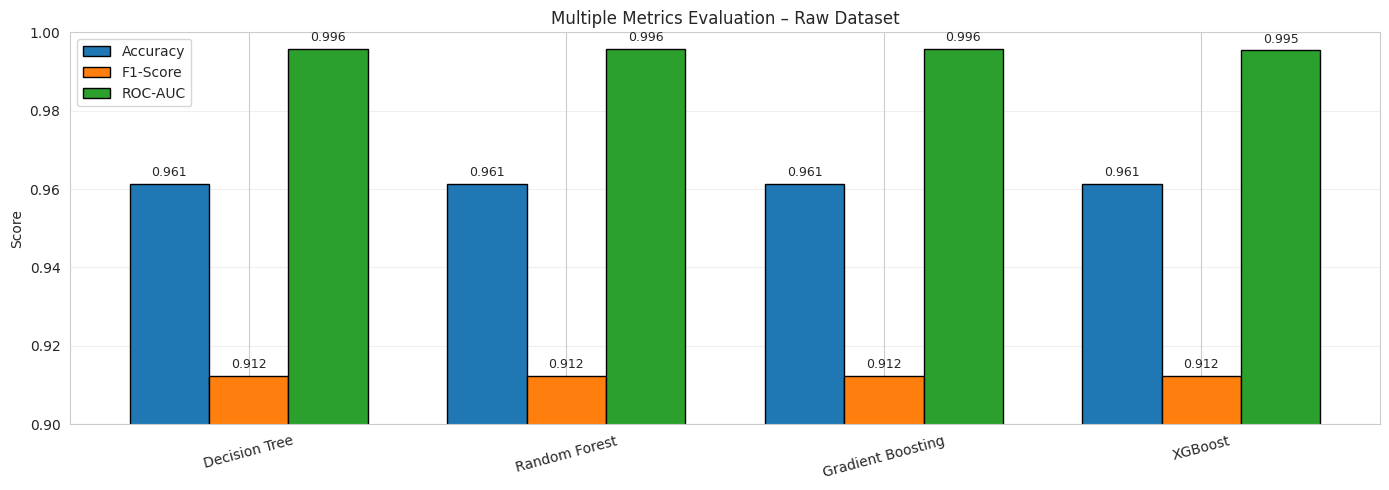


 ENGINEERED DATASET 


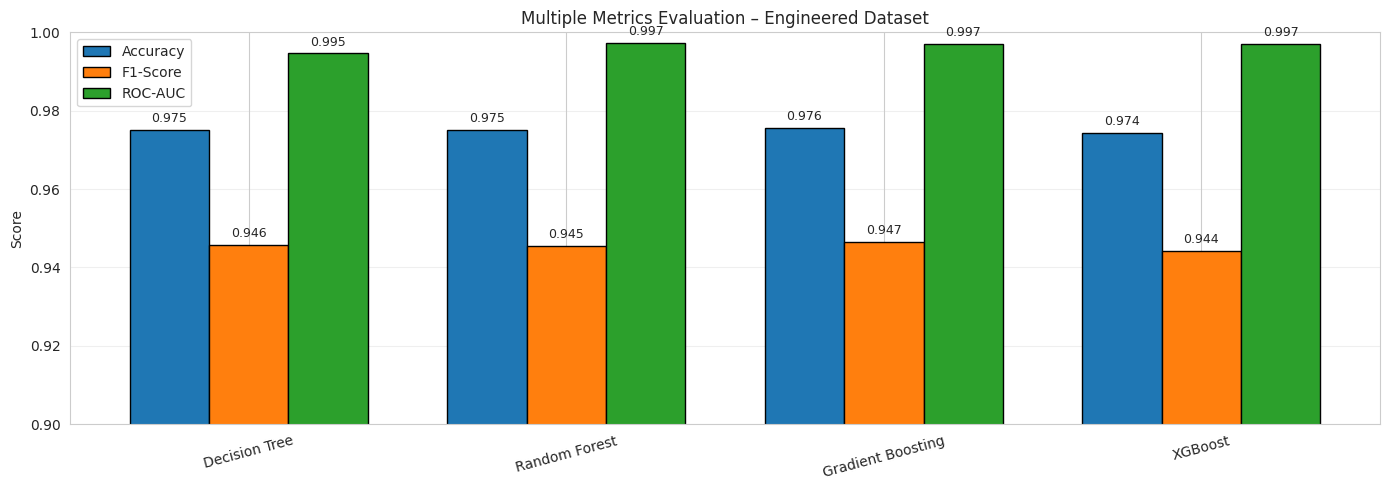

In [64]:
def evaluate_multiple_metrics_visual(tuned_results, X_test, y_test, dataset_name):
    """Evaluate models using Accuracy, F1, ROC-AUC and display as a diagram"""

    models = list(tuned_results.keys())
    accuracy_scores = []
    f1_scores = []
    roc_auc_scores = []

    for model_name, results in tuned_results.items():
        model = results['model']
        y_pred = model.predict(X_test)
        y_pred_proba = (
            model.predict_proba(X_test)[:, 1]
            if hasattr(model, 'predict_proba') else None
        )

        accuracy_scores.append(accuracy_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=0))
        roc_auc_scores.append(
            roc_auc_score(y_test, y_pred_proba)
            if y_pred_proba is not None else np.nan
        )

    x = np.arange(len(models))
    bar_width = 0.25

    plt.figure(figsize=(14, 5))

    plt.bar(x - bar_width, accuracy_scores, bar_width, label='Accuracy',
            edgecolor='black')
    plt.bar(x, f1_scores, bar_width, label='F1-Score',
            edgecolor='black')
    plt.bar(x + bar_width, roc_auc_scores, bar_width, label='ROC-AUC',
            edgecolor='black')

    plt.xticks(x, models, rotation=15)
    plt.ylim(0.9, 1.0)
    plt.ylabel('Score')
    plt.title(f'Multiple Metrics Evaluation – {dataset_name}')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()

    for i in range(len(models)):
        plt.text(i - bar_width, accuracy_scores[i] + 0.002,
                 f'{accuracy_scores[i]:.3f}', ha='center', fontsize=9)
        plt.text(i, f1_scores[i] + 0.002,
                 f'{f1_scores[i]:.3f}', ha='center', fontsize=9)
        plt.text(i + bar_width, roc_auc_scores[i] + 0.002,
                 f'{roc_auc_scores[i]:.3f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

print("\n RAW DATASET")
evaluate_multiple_metrics_visual(
    tuned_results_raw, X_test_raw, y_test_raw, "Raw Dataset"
)

print("\n ENGINEERED DATASET ")
evaluate_multiple_metrics_visual(
    tuned_results_eng, X_test_eng, y_test_eng, "Engineered Dataset"
)

## Prediction Similarity Analysis

In [65]:
def prediction_similarity_minimal(tuned_results, X_test):
    """
    Compute average prediction agreement between models.
    Higher % = more similar behavior.
    """
    model_names = list(tuned_results.keys())
    preds = {
        name: tuned_results[name]['model'].predict(X_test)
        for name in model_names
    }

    agreement = {}

    for m1 in model_names:
        agreements = [
            (preds[m1] == preds[m2]).mean() * 100
            for m2 in model_names if m2 != m1
        ]
        agreement[m1] = np.mean(agreements)

    return pd.Series(agreement, name='Avg Agreement (%)').round(2)

print("\nRAW DATASET – Prediction Similarity")
print(prediction_similarity_minimal(tuned_results_raw, X_test_raw))

print("\nENGINEERED DATASET – Prediction Similarity")
print(prediction_similarity_minimal(tuned_results_eng, X_test_eng))




RAW DATASET – Prediction Similarity
Decision Tree        100.0
Random Forest        100.0
Gradient Boosting    100.0
XGBoost              100.0
Name: Avg Agreement (%), dtype: float64

ENGINEERED DATASET – Prediction Similarity
Decision Tree        99.77
Random Forest        99.85
Gradient Boosting    99.85
XGBoost              99.85
Name: Avg Agreement (%), dtype: float64


## Confusion Matrix Analysis

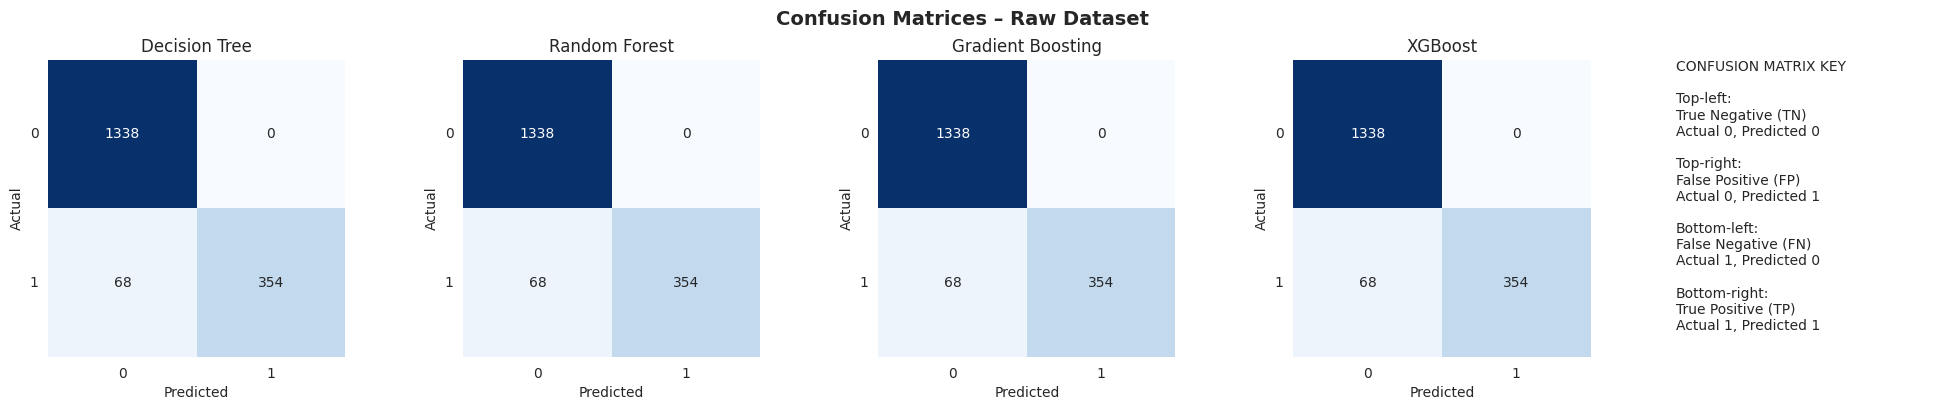

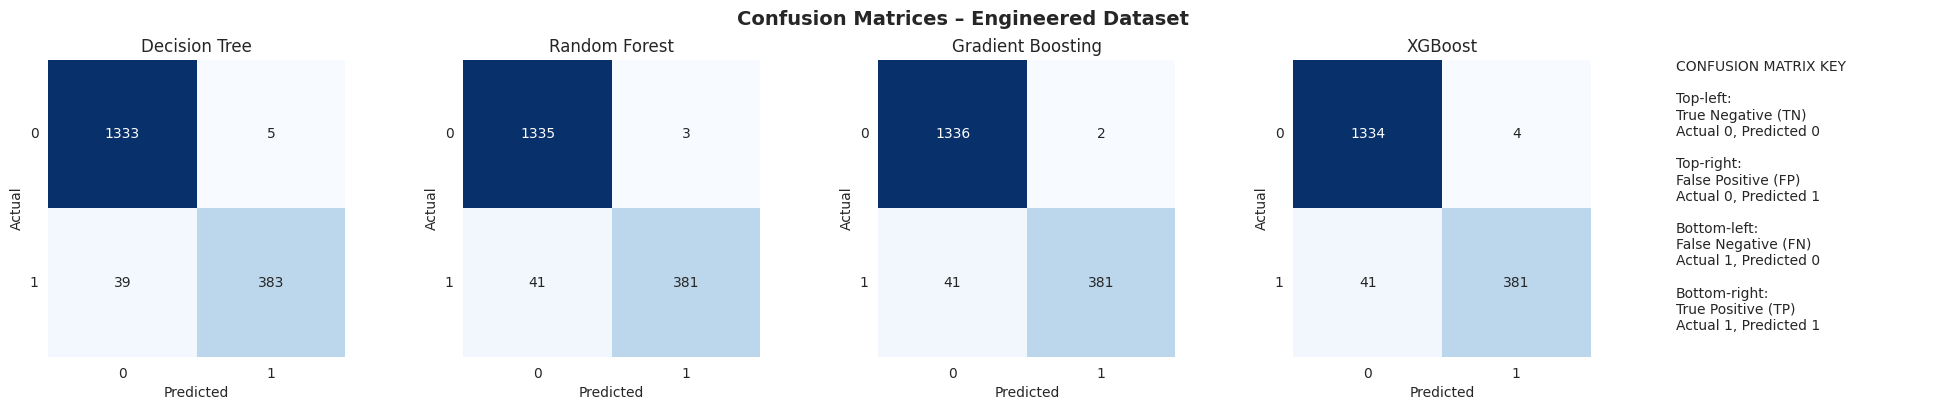

In [66]:
def plot_confusion_matrices_with_key(
    tuned_results, X_test, y_test, dataset_name
):
    """
    Plot confusion matrices exactly like the standard sklearn/seaborn style,
    plus a simple explanatory key.
    """

    model_names = list(tuned_results.keys())
    n_models = len(model_names)

    fig, axes = plt.subplots(
        1, n_models + 1,
        figsize=(4 * n_models + 4, 4),
        gridspec_kw={"width_ratios": [4] * n_models + [3]}
    )

    for ax, model_name in zip(axes[:-1], model_names):
        model = tuned_results[model_name]["model"]
        y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            square=True,
            ax=ax
        )

        ax.set_title(model_name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticklabels(["0", "1"])
        ax.set_yticklabels(["0", "1"], rotation=0)

    key_ax = axes[-1]
    key_ax.axis("off")

    key_text = (
        "CONFUSION MATRIX KEY\n\n"
        "Top‑left:\n"
        "True Negative (TN)\n"
        "Actual 0, Predicted 0\n\n"
        "Top‑right:\n"
        "False Positive (FP)\n"
        "Actual 0, Predicted 1\n\n"
        "Bottom‑left:\n"
        "False Negative (FN)\n"
        "Actual 1, Predicted 0\n\n"
        "Bottom‑right:\n"
        "True Positive (TP)\n"
        "Actual 1, Predicted 1"
    )

    key_ax.text(
        0, 1,
        key_text,
        va="top",
        fontsize=10
    )

    plt.suptitle(
        f"Confusion Matrices – {dataset_name}",
        fontsize=14,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

plot_confusion_matrices_with_key(
    tuned_results_raw, X_test_raw, y_test_raw, "Raw Dataset"
)

plot_confusion_matrices_with_key(
    tuned_results_eng, X_test_eng, y_test_eng, "Engineered Dataset"
)

## Feature Removal Experiment (A-levels scores)

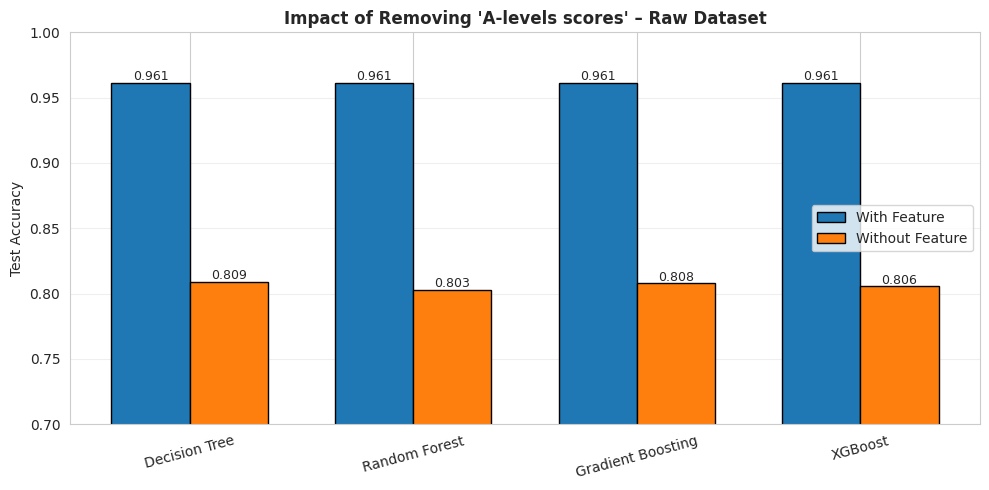

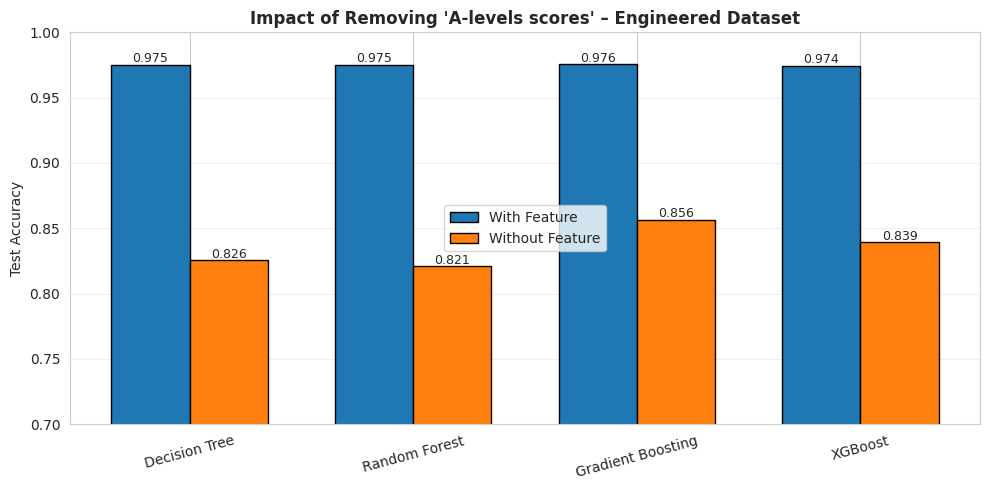

In [67]:
def analyze_feature_removal_visual(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    tuned_results,
    dataset_name,
    feature_to_remove="A-levels scores"
):
    """Visualise the impact of removing a dominant feature"""

    if feature_to_remove not in X_train.columns:
        print(f"Feature '{feature_to_remove}' not found in {dataset_name}.")
        return None

    X_train_r = X_train.drop(columns=[feature_to_remove])
    X_test_r = X_test.drop(columns=[feature_to_remove])

    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42, verbosity=0, eval_metric="logloss")
    }

    original_scores = []
    removed_scores = []
    model_names = list(models.keys())

    for name, model in models.items():
        model.fit(X_train_r, y_train)
        removed_scores.append(model.score(X_test_r, y_test))
        original_scores.append(tuned_results[name]["test_score"])

    x = np.arange(len(model_names))
    width = 0.35

    plt.figure(figsize=(10, 5))

    plt.bar(
        x - width / 2,
        original_scores,
        width,
        label="With Feature",
        edgecolor="black"
    )
    plt.bar(
        x + width / 2,
        removed_scores,
        width,
        label="Without Feature",
        edgecolor="black"
    )

    plt.xticks(x, model_names, rotation=15)
    plt.ylabel("Test Accuracy")
    plt.title(
        f"Impact of Removing '{feature_to_remove}' – {dataset_name}",
        fontweight="bold"
    )
    plt.ylim(0.70, 1.0)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    for i in range(len(model_names)):
        plt.text(x[i] - width / 2, original_scores[i] + 0.002,
                 f"{original_scores[i]:.3f}", ha="center", fontsize=9)
        plt.text(x[i] + width / 2, removed_scores[i] + 0.002,
                 f"{removed_scores[i]:.3f}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

analyze_feature_removal_visual(
    X_train_raw, X_val_raw, X_test_raw,
    y_train_raw, y_val_raw, y_test_raw,
    tuned_results_raw,
    "Raw Dataset",
    "A-levels scores"
)

analyze_feature_removal_visual(
    X_train_eng, X_val_eng, X_test_eng,
    y_train_eng, y_val_eng, y_test_eng,
    tuned_results_eng,
    "Engineered Dataset",
    "A-levels scores"
)


## Visualisations

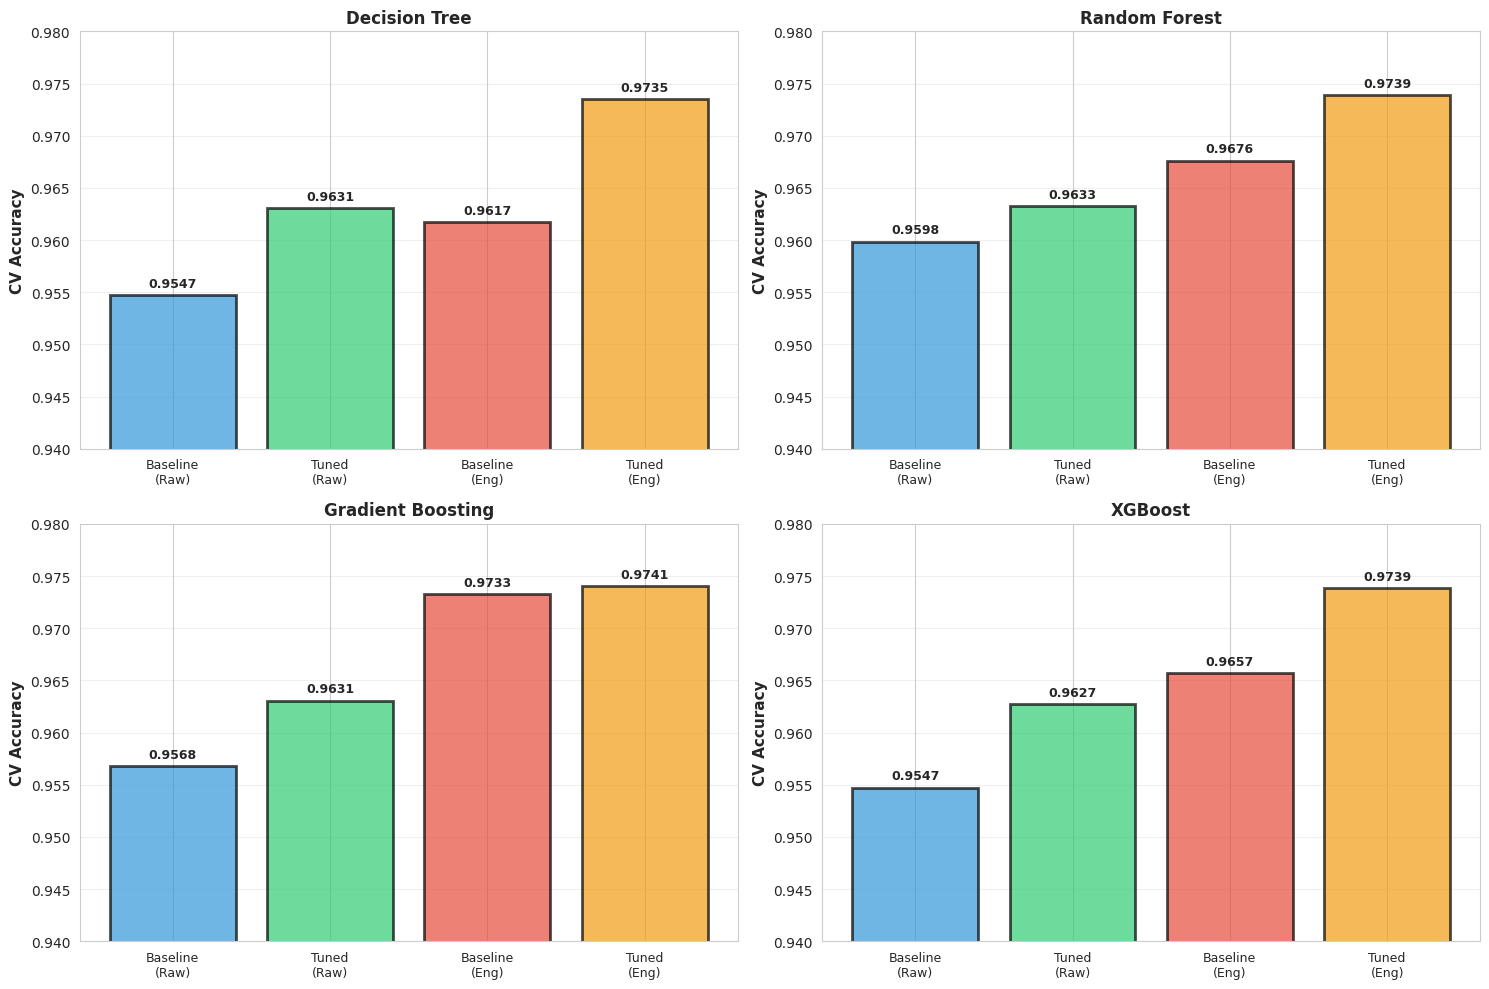

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

models = list(tuned_results_raw.keys())

for idx, model_name in enumerate(models):
    baseline_cv_raw = tuned_results_raw[model_name]['baseline_cv']
    tuned_cv_raw = tuned_results_raw[model_name]['tuned_cv']
    baseline_cv_eng = tuned_results_eng[model_name]['baseline_cv']
    tuned_cv_eng = tuned_results_eng[model_name]['tuned_cv']

    x_pos = np.arange(4)
    values = [baseline_cv_raw, tuned_cv_raw, baseline_cv_eng, tuned_cv_eng]
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
    labels = ['Baseline\n(Raw)', 'Tuned\n(Raw)', 'Baseline\n(Eng)', 'Tuned\n(Eng)']

    bars = axes[idx].bar(x_pos, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[idx].set_ylabel('CV Accuracy', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(labels, fontsize=9)
    axes[idx].set_ylim([0.94, 0.98])
    axes[idx].grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.0005,
                      f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Interpretation & Analysis

In [69]:
print("RAW DATASET ANALYSIS")
print(f"{'='*50}\n")

best_raw_model = max(tuned_results_raw.items(), key=lambda x: x[1]['test_score'])[0]
best_raw_score = tuned_results_raw[best_raw_model]['test_score']

print(f"Best Model: {best_raw_model}")
print(f"Test Accuracy: {best_raw_score:.4f}")
print(f"\nAverage improvement from tuning: {np.mean([tuned_results_raw[m]['improvement'] for m in tuned_results_raw.keys()]):+.2f}%")
print(f"\nTop 3 Tuning Improvements:")
for i, (model, data) in enumerate(sorted(tuned_results_raw.items(), key=lambda x: x[1]['improvement'], reverse=True)[:3], 1):
    print(f"  {i}. {model}: {data['improvement']:+.2f}%")

RAW DATASET ANALYSIS

Best Model: Decision Tree
Test Accuracy: 0.9614

Average improvement from tuning: +0.65%

Top 3 Tuning Improvements:
  1. Decision Tree: +0.83%
  2. XGBoost: +0.80%
  3. Gradient Boosting: +0.63%


In [70]:
print("ENGINEERED DATASET ANALYSIS")
print(f"{'='*50}\n")

best_eng_model = max(tuned_results_eng.items(), key=lambda x: x[1]['test_score'])[0]
best_eng_score = tuned_results_eng[best_eng_model]['test_score']

print(f"Best Model: {best_eng_model}")
print(f"Test Accuracy: {best_eng_score:.4f}")
print(f"\nAverage improvement from tuning: {np.mean([tuned_results_eng[m]['improvement'] for m in tuned_results_eng.keys()]):+.2f}%")
print(f"\nTop 3 Tuning Improvements:")
for i, (model, data) in enumerate(sorted(tuned_results_eng.items(), key=lambda x: x[1]['improvement'], reverse=True)[:3], 1):
    print(f"  {i}. {model}: {data['improvement']:+.2f}%")

ENGINEERED DATASET ANALYSIS

Best Model: Gradient Boosting
Test Accuracy: 0.9756

Average improvement from tuning: +0.67%

Top 3 Tuning Improvements:
  1. Decision Tree: +1.17%
  2. XGBoost: +0.81%
  3. Random Forest: +0.63%


## Comprehensive Summary Table

In [71]:
print(f"\n{'='*130}")
print("COMPREHENSIVE SUMMARY TABLE - ALL MODELS, BOTH DATASETS")
print(f"{'='*130}\n")

summary_data = []

for model_name in list(tuned_results_raw.keys()):
    summary_data.append({
        'Dataset': 'RAW',
        'Model': model_name,
        'Baseline CV': f"{tuned_results_raw[model_name]['baseline_cv']:.4f}",
        'Tuned CV': f"{tuned_results_raw[model_name]['tuned_cv']:.4f}",
        'Improvement': f"{tuned_results_raw[model_name]['improvement']:+.2f}%",
        'Val Score': f"{0:.4f}",
        'Test Score': f"{tuned_results_raw[model_name]['test_score']:.4f}"
    })
    summary_data.append({
        'Dataset': 'ENG',
        'Model': model_name,
        'Baseline CV': f"{tuned_results_eng[model_name]['baseline_cv']:.4f}",
        'Tuned CV': f"{tuned_results_eng[model_name]['tuned_cv']:.4f}",
        'Improvement': f"{tuned_results_eng[model_name]['improvement']:+.2f}%",
        'Val Score': f"{0:.4f}",
        'Test Score': f"{tuned_results_eng[model_name]['test_score']:.4f}"
    })

summary_table = pd.DataFrame(summary_data)
print(summary_table.to_string(index=False))
print(f"\n{'='*130}")


COMPREHENSIVE SUMMARY TABLE - ALL MODELS, BOTH DATASETS

Dataset             Model Baseline CV Tuned CV Improvement Val Score Test Score
    RAW     Decision Tree      0.9547   0.9631      +0.83%    0.0000     0.9614
    ENG     Decision Tree      0.9617   0.9735      +1.17%    0.0000     0.9750
    RAW     Random Forest      0.9598   0.9633      +0.34%    0.0000     0.9614
    ENG     Random Forest      0.9676   0.9739      +0.63%    0.0000     0.9750
    RAW Gradient Boosting      0.9568   0.9631      +0.63%    0.0000     0.9614
    ENG Gradient Boosting      0.9733   0.9741      +0.08%    0.0000     0.9756
    RAW           XGBoost      0.9547   0.9627      +0.80%    0.0000     0.9614
    ENG           XGBoost      0.9657   0.9739      +0.81%    0.0000     0.9744



# EXPLAINABILITY ANALYSIS

In [74]:
df_eng = df_bin_uni_scaled_final.copy()
df_eng.head()

best_eng_model = max(tuned_results_eng.items(), key=lambda x: x[1]['test_score'])[0]
best_model_eng = tuned_results_eng['Random Forest']['model']

print(f"Best model loaded: Gradient Boosting")
print(f"Dataset shape: {df_eng.shape}")


Best model loaded: Gradient Boosting
Dataset shape: (8800, 9)


In [75]:
def split_data(X, y, test_size=0.2, val_size=0.2, random_state=42):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train_eng, X_val_eng, X_test_eng, y_train_eng, y_val_eng, y_test_eng = split_data(X_eng, y_eng)

In [76]:
explainer_shap = shap.TreeExplainer(best_model_eng)
shap_values = explainer_shap.shap_values(X_test_eng)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values computed for {X_test_eng.shape[0]} test samples")
print(f"Base value (expected model output): {explainer_shap.expected_value}")

SHAP values computed for 1760 test samples
Base value (expected model output): [0.7600303 0.2399697]


In [77]:
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

mean_abs_shap = np.abs(shap_values).mean(axis=0)

top_features = np.argsort(mean_abs_shap)[-10:][::-1]

print("\nTop 10 Most Important Features (by SHAP):")
print(f"{'Rank':<6} {'Feature':<40} {'Mean |SHAP|':<15}")
print("-" * 61)

for rank, idx in enumerate(top_features, start=1):
    feature_name = X_test_eng.columns[idx]
    importance = mean_abs_shap[idx]
    print(f"{rank:<6} {feature_name:<40} {importance:.6f}")


Top 10 Most Important Features (by SHAP):
Rank   Feature                                  Mean |SHAP|    
-------------------------------------------------------------
1      A-levels scores                          0.225540
2      References Submitted                     0.088813
3      Is_Employed                              0.063030
4      University Tier_Other                    0.027477
5      Current Annual Income                    0.025095
6      University Tier_Strong                   0.004915
7      Education_stem                           0.001976
8      Education_business                       0.001205
9      Education_law                            0.000807


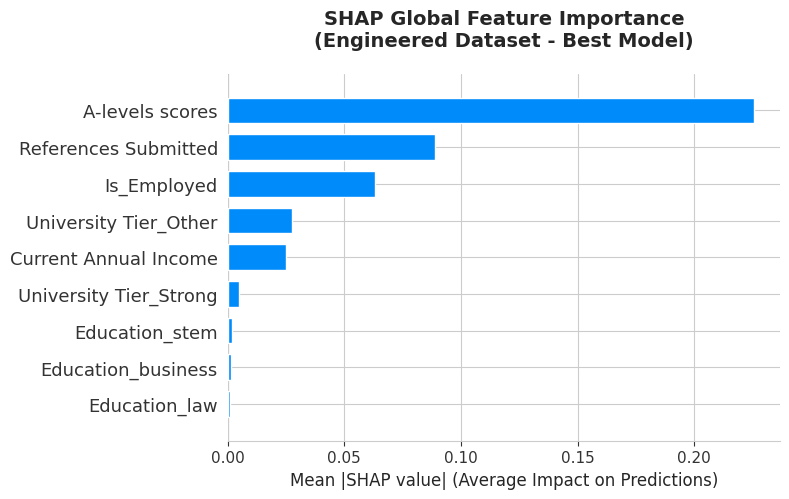

In [78]:
shap.summary_plot(shap_values, X_test_eng, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance\n(Engineered Dataset - Best Model)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mean |SHAP value| (Average Impact on Predictions)', fontsize=12)
plt.tight_layout()
plt.show()

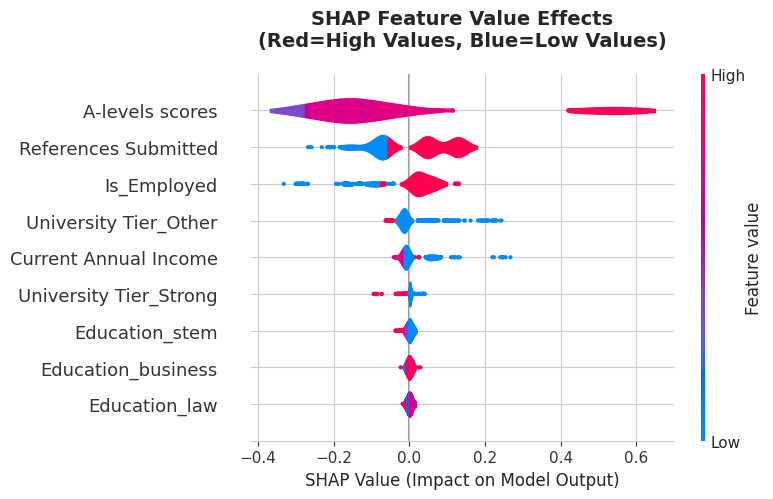

In [79]:
X_train_eng = X_train_eng.astype(float)
X_val_eng   = X_val_eng.astype(float)
X_test_eng  = X_test_eng.astype(float)

shap.summary_plot(shap_values, X_test_eng, plot_type='violin', show=False)
plt.title('SHAP Feature Value Effects\n(Red=High Values, Blue=Low Values)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=12)
plt.tight_layout()
plt.show()

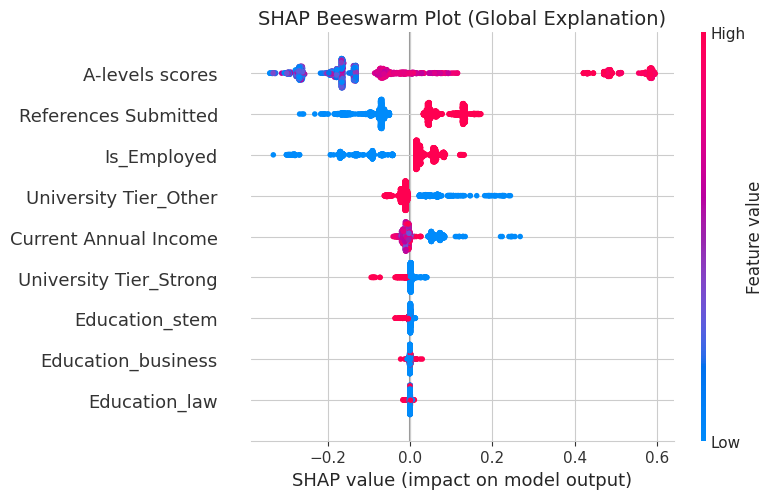

In [80]:
plt.figure()
shap.summary_plot(shap_values, X_test_eng, show=False)
plt.title('SHAP Beeswarm Plot (Global Explanation)', fontsize=14)
plt.tight_layout()
plt.show()

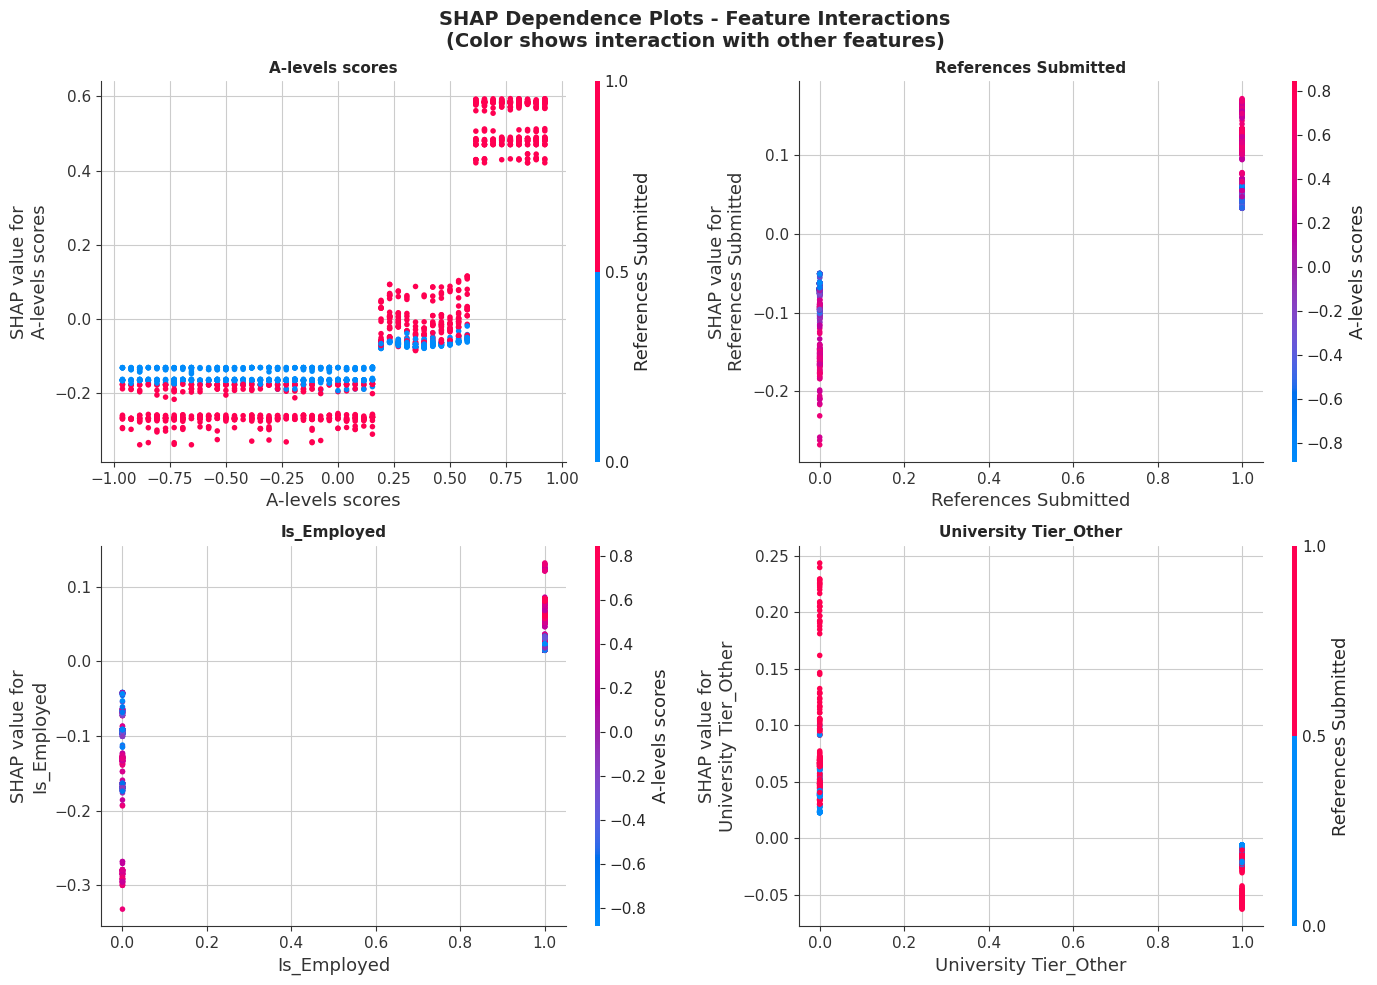

In [81]:
feature_names = list(X_test_eng.columns)
top_features_idx = np.argsort(mean_abs_shap)[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for plot_idx, feature_idx in enumerate(top_features_idx):
    shap.dependence_plot(feature_idx, shap_values, X_test_eng, show=False, ax=axes[plot_idx])
    axes[plot_idx].set_title(f'{feature_names[feature_idx]}', fontsize=11, fontweight='bold')

plt.suptitle('SHAP Dependence Plots - Feature Interactions\n(Color shows interaction with other features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

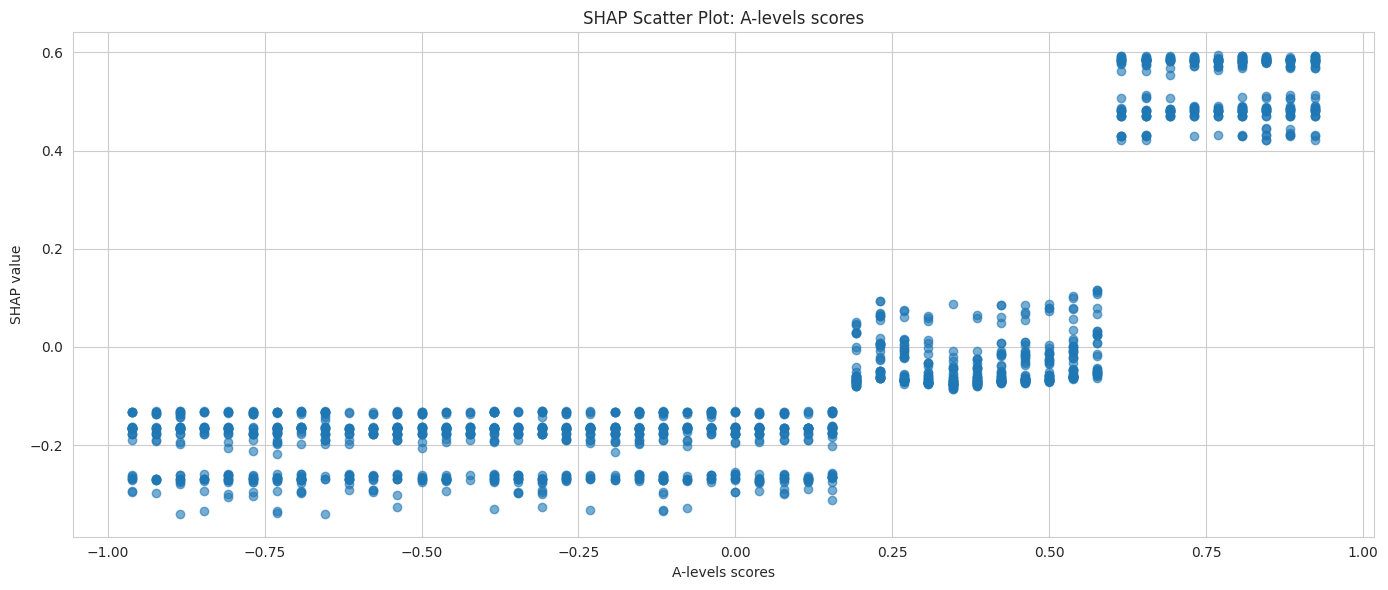

In [82]:
top_feature_name = X_test_eng.columns[top_features_idx[0]]
feature_idx = X_test_eng.columns.get_loc(top_feature_name)

plt.figure()
plt.scatter(
    X_test_eng[top_feature_name],
    shap_values[:, feature_idx],
    alpha=0.6
)
plt.xlabel(top_feature_name)
plt.ylabel("SHAP value")
plt.title(f"SHAP Scatter Plot: {top_feature_name}")
plt.tight_layout()
plt.show()


=== HIRED CANDIDATE (Index 1) ===
Prediction Probability: 1.0000

Top 5 Contributing Features:
  1. A-levels scores: 0.6538 (increases hiring)
  2. References Submitted: 1.0000 (increases hiring)
  3. Is_Employed: 1.0000 (increases hiring)
  4. Current Annual Income: -0.6755 (increases hiring)
  5. University Tier_Strong: 0.0000 (increases hiring)


<Figure size 1200x400 with 0 Axes>

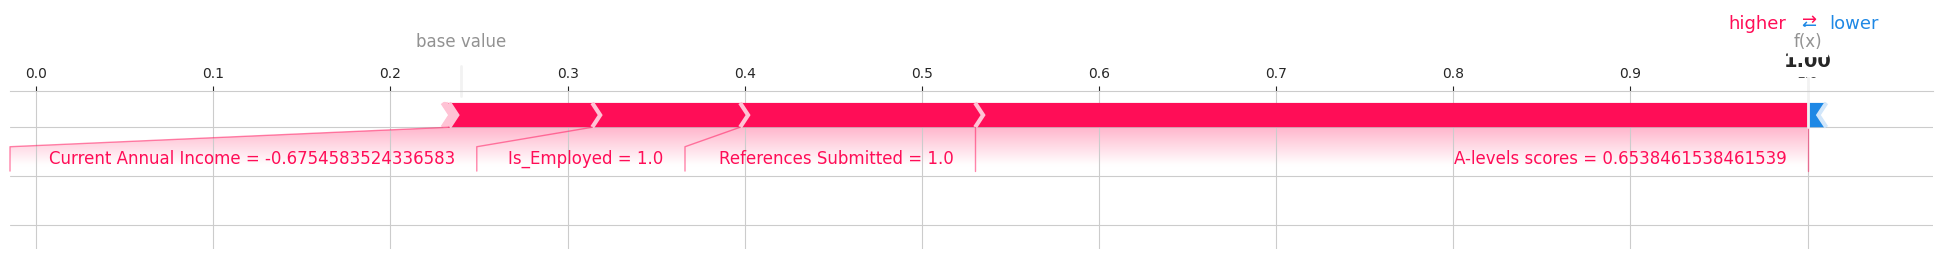



=== NOT HIRED CANDIDATE (Index 0) ===
Prediction Probability: 0.0000

Top 5 Contributing Features:
  1. A-levels scores: 0.0000 (decreases hiring)
  2. Is_Employed: 0.0000 (decreases hiring)
  3. References Submitted: 0.0000 (decreases hiring)
  4. University Tier_Other: 1.0000 (decreases hiring)
  5. Education_stem: 0.0000 (decreases hiring)


<Figure size 1200x400 with 0 Axes>

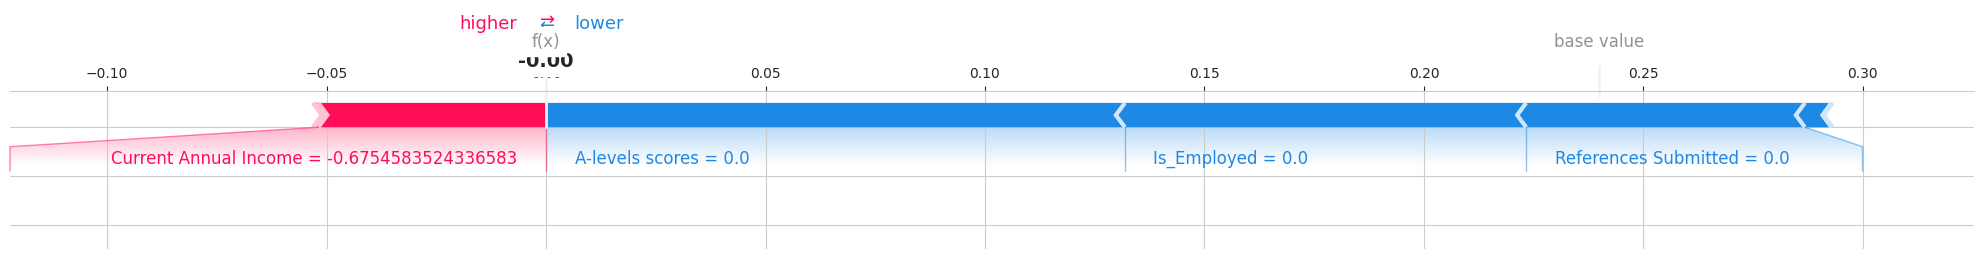

In [83]:
hired_indices = np.where(y_test_eng == 1)[0]
not_hired_indices = np.where(y_test_eng == 0)[0]

if len(hired_indices) > 0:
    idx_hired = hired_indices[0]
    pred_proba = best_model_eng.predict_proba(X_test_eng[idx_hired:idx_hired+1])[0][1]
    print(f"\n=== HIRED CANDIDATE (Index {idx_hired}) ===")
    print(f"Prediction Probability: {pred_proba:.4f}")
    print(f"\nTop 5 Contributing Features:")

    shap_vals_sample = shap_values[idx_hired]
    top_idx = np.argsort(shap_vals_sample)[-5:][::-1]
    for rank, idx in enumerate(top_idx, 1):
        feat_val = X_test_eng.iloc[idx_hired, idx]
        shap_val = shap_vals_sample[idx]
        direction = "(increases hiring)" if shap_val > 0 else "(decreases hiring)"
        print(f"  {rank}. {X_test_eng.columns[idx]}: {feat_val:.4f} {direction}")

    try:
        fig = plt.figure(figsize=(12, 4))
        shap.force_plot(
            explainer_shap.expected_value[1] if isinstance(explainer_shap.expected_value, (list, np.ndarray)) else explainer_shap.expected_value,
            shap_values[idx_hired],
            X_test_eng.iloc[idx_hired],
            matplotlib=True, show=False
        )
        plt.tight_layout()
        plt.show()
    except:
        pass

if len(not_hired_indices) > 0:
    idx_not_hired = not_hired_indices[0]
    pred_proba = best_model_eng.predict_proba(X_test_eng[idx_not_hired:idx_not_hired+1])[0][1]
    print(f"\n\n=== NOT HIRED CANDIDATE (Index {idx_not_hired}) ===")
    print(f"Prediction Probability: {pred_proba:.4f}")
    print(f"\nTop 5 Contributing Features:")

    shap_vals_sample = shap_values[idx_not_hired]
    top_idx = np.argsort(shap_vals_sample)[:5]
    for rank, idx in enumerate(top_idx, 1):
        feat_val = X_test_eng.iloc[idx_not_hired, idx]
        shap_val = shap_vals_sample[idx]
        direction = "(increases hiring)" if shap_val > 0 else "(decreases hiring)"
        print(f"  {rank}. {X_test_eng.columns[idx]}: {feat_val:.4f} {direction}")

    try:
        fig = plt.figure(figsize=(12, 4))
        shap.force_plot(
            explainer_shap.expected_value[1] if isinstance(explainer_shap.expected_value, (list, np.ndarray)) else explainer_shap.expected_value,
            shap_values[idx_not_hired],
            X_test_eng.iloc[idx_not_hired],
            matplotlib=True, show=False
        )
        plt.tight_layout()
        plt.show()
    except:
        pass

## LIME Analysis - Best Model (Engineered Dataset)

In [84]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train_eng.values,
    feature_names=X_train_eng.columns.tolist(),
    class_names=['Not Hired', 'Hired'],
    mode='classification',
    random_state=42
)

def predict_proba_fn(x):
    return best_model_eng.predict_proba(x)

print("LIME Explainer initialized")
print(f"Training set size: {X_train_eng.shape[0]} samples")

LIME Explainer initialized
Training set size: 5280 samples


In [85]:
np.random.seed(42)
sample_indices = np.random.choice(X_test_eng.shape[0], 10, replace=False)

print(f"{'Index':<10} {'Prediction':<15} {'Probability':<15} {'Actual':<15} {'Correct':<10}")
print("-" * 65)

sample_info = []
for idx in sample_indices:
    pred_proba = best_model_eng.predict_proba(X_test_eng[idx:idx+1])[0]
    pred_label = best_model_eng.predict(X_test_eng[idx:idx+1])[0]
    actual_label = y_test_eng.iloc[idx]

    prediction_text = 'Hired' if pred_label == 1 else 'Not Hired'
    actual_text = 'Hired' if actual_label == 1 else 'Not Hired'
    correct = 'yes' if (pred_label == actual_label) else 'no'

    print(f"{idx:<10} {prediction_text:<15} {pred_proba[1]:.4f}         {actual_text:<15} {correct:<10}")

    sample_info.append({
        'index': idx,
        'prediction': prediction_text,
        'probability': pred_proba[1],
        'actual': actual_text,
        'correct': pred_label == actual_label
    })

accuracy = sum([s['correct'] for s in sample_info]) / len(sample_info)
print("-" * 65)
print(f"Accuracy on LIME samples: {accuracy*100:.1f}%")

Index      Prediction      Probability     Actual          Correct   
-----------------------------------------------------------------
1125       Not Hired       0.0000         Not Hired       yes       
1030       Not Hired       0.0037         Not Hired       yes       
1683       Not Hired       0.0000         Not Hired       yes       
1541       Hired           0.8396         Hired           yes       
344        Not Hired       0.0690         Not Hired       yes       
1022       Not Hired       0.0008         Not Hired       yes       
1480       Not Hired       0.0000         Not Hired       yes       
322        Not Hired       0.0005         Not Hired       yes       
1406       Not Hired       0.0000         Not Hired       yes       
339        Not Hired       0.0000         Not Hired       yes       
-----------------------------------------------------------------
Accuracy on LIME samples: 100.0%


In [86]:
lime_explanations = {}
lime_data = []

for sample_num, idx in enumerate(sample_indices, 1):
    pred_proba = best_model_eng.predict_proba(X_test_eng[idx:idx+1])[0]
    pred_label = best_model_eng.predict(X_test_eng[idx:idx+1])[0]
    actual_label = y_test_eng.iloc[idx]

    exp = explainer_lime.explain_instance(
        X_test_eng.iloc[idx].values,
        predict_proba_fn,
        num_features=5
    )

    lime_explanations[idx] = exp
    exp_list = exp.as_list()

    lime_data.append({
        'sample_num': sample_num,
        'index': idx,
        'prediction': 'Hired' if pred_label == 1 else 'Not Hired',
        'probability': pred_proba[1],
        'actual': 'Hired' if actual_label == 1 else 'Not Hired',
        'correct': pred_label == actual_label,
        'top_features': exp_list
    })

    print(f"\nSample {sample_num} (Index {idx}): {lime_data[-1]['prediction']} (Prob: {lime_data[-1]['probability']:.4f})")
    print(f"Top Features:")
    for i, (feature, weight) in enumerate(exp_list, 1):
        print(f"  {i}. {feature}")

print(f"\nLIME Analysis Complete: 10 samples explained")


Sample 1 (Index 1125): Not Hired (Prob: 0.0000)
Top Features:
  1. A-levels scores <= -0.50
  2. References Submitted <= 0.00
  3. Is_Employed <= 0.00
  4. Education_law <= 0.00
  5. Education_business <= 0.00

Sample 2 (Index 1030): Not Hired (Prob: 0.0037)
Top Features:
  1. 0.00 < References Submitted <= 1.00
  2. Is_Employed <= 0.00
  3. 0.00 < A-levels scores <= 0.50
  4. University Tier_Strong <= 0.00
  5. 0.00 < Education_law <= 1.00

Sample 3 (Index 1683): Not Hired (Prob: 0.0000)
Top Features:
  1. A-levels scores <= -0.50
  2. References Submitted <= 0.00
  3. 0.00 < Is_Employed <= 1.00
  4. University Tier_Strong <= 0.00
  5. Education_business <= 0.00

Sample 4 (Index 1541): Hired (Prob: 0.8396)
Top Features:
  1. A-levels scores > 0.50
  2. 0.00 < References Submitted <= 1.00
  3. 0.00 < Is_Employed <= 1.00
  4. University Tier_Strong <= 0.00
  5. Education_law <= 0.00

Sample 5 (Index 344): Not Hired (Prob: 0.0690)
Top Features:
  1. A-levels scores <= -0.50
  2. 0.00 < 

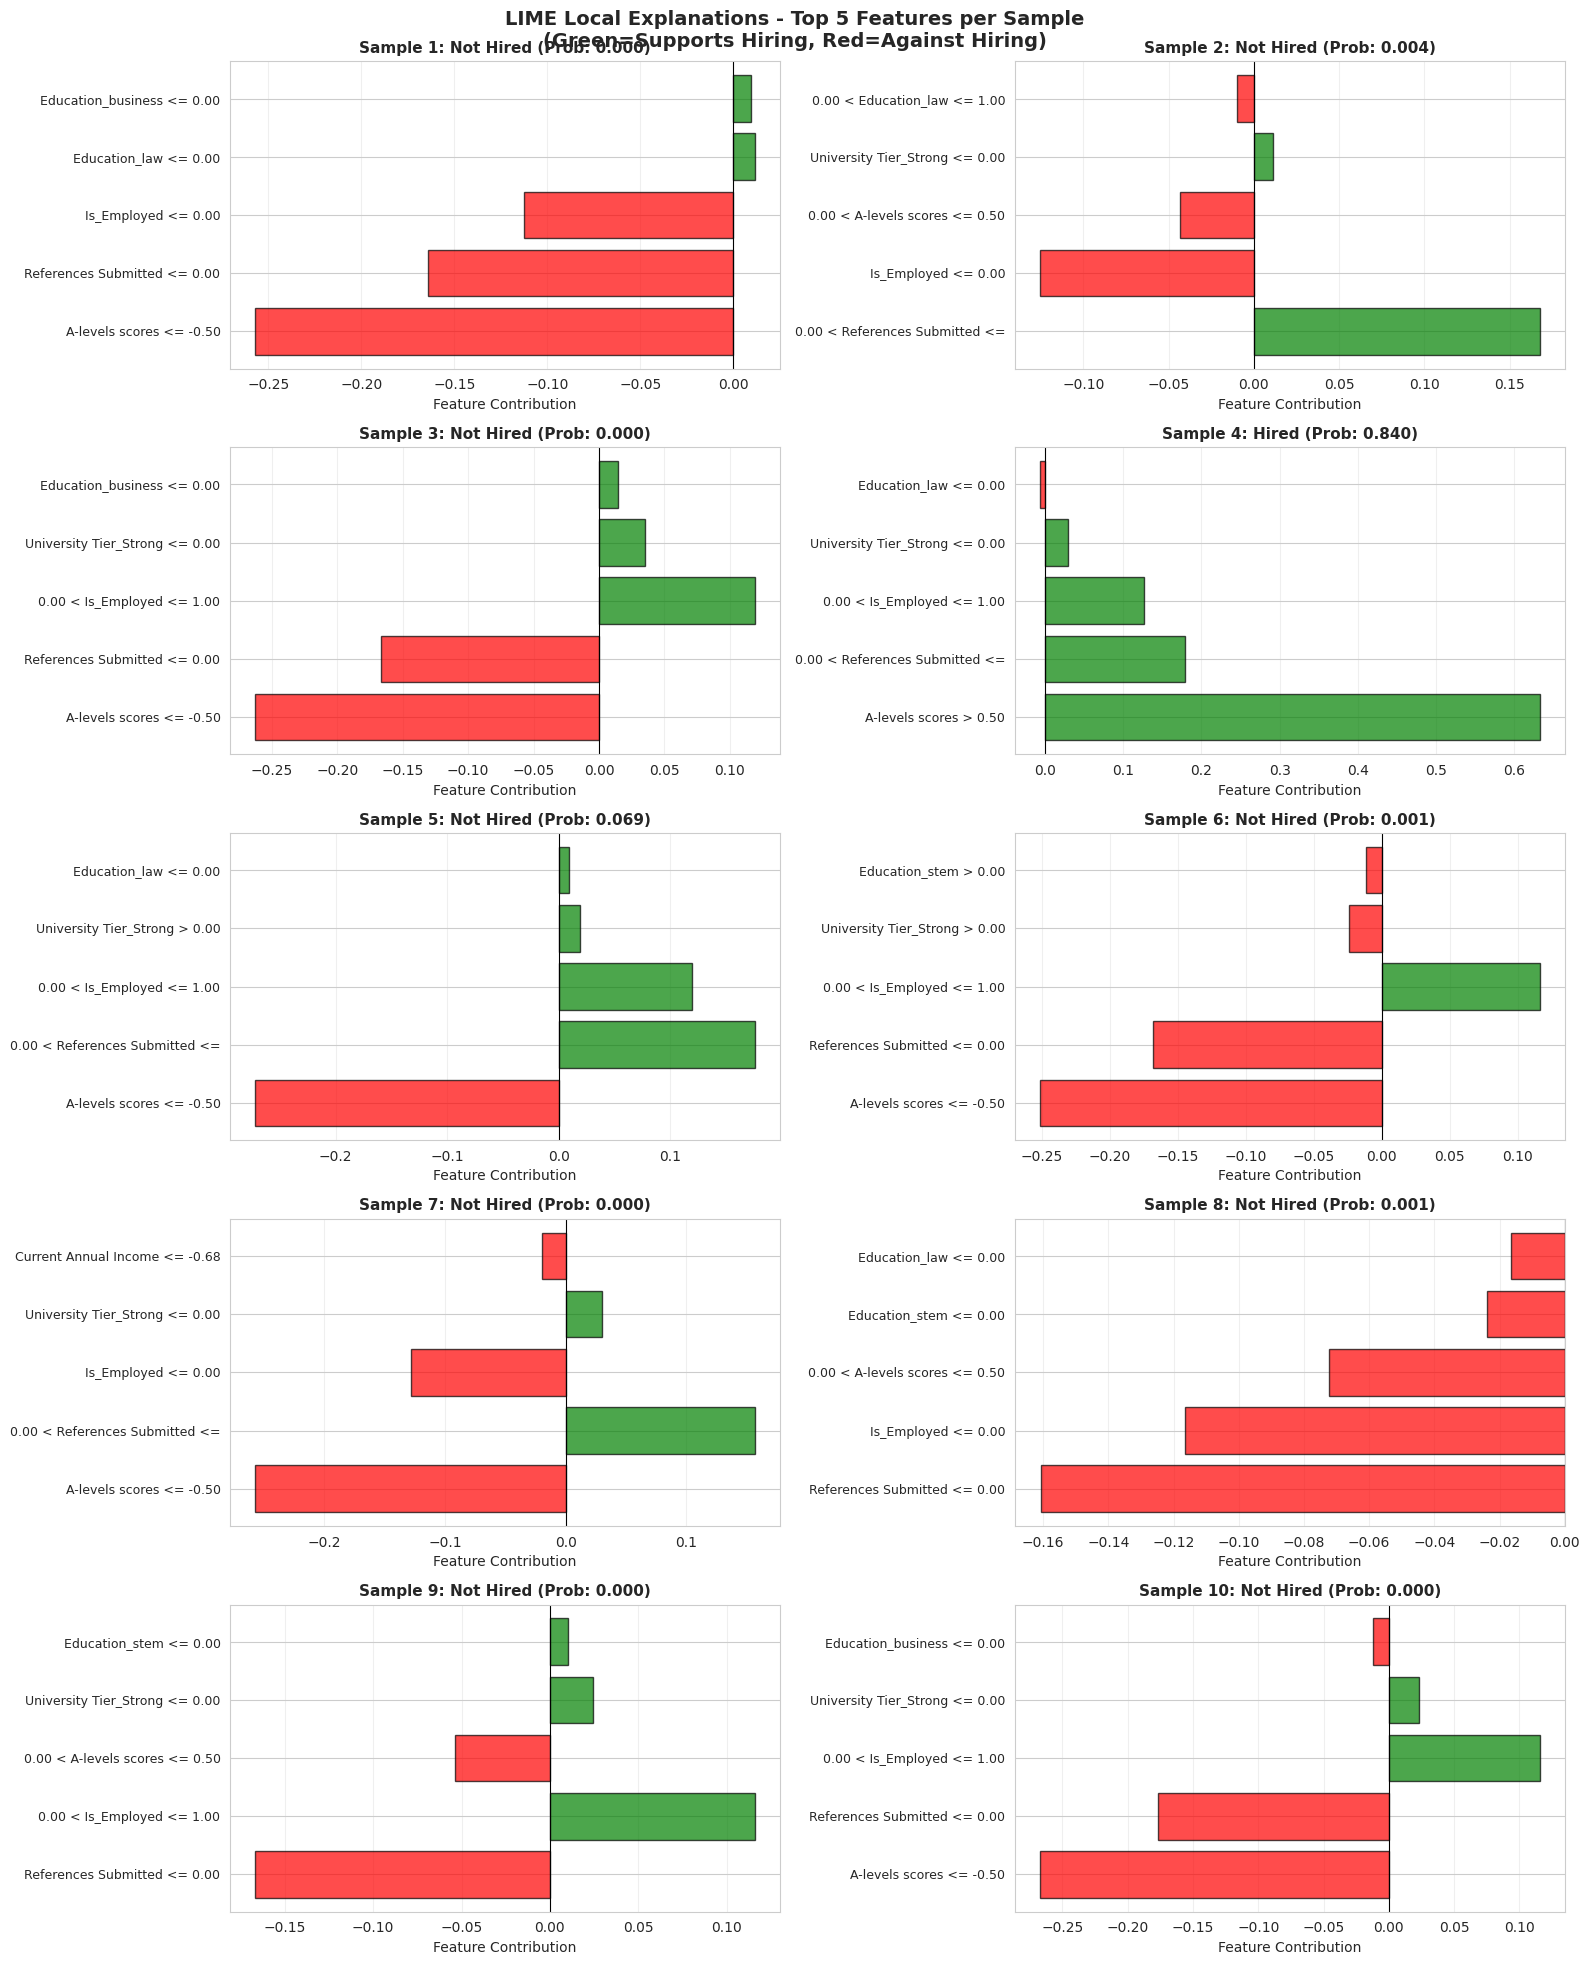

In [87]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.ravel()

for plot_idx, (sample_num, idx) in enumerate(zip(range(1, 11), sample_indices)):
    ax = axes[plot_idx]

    sample_data = lime_data[plot_idx]
    features_weights = sample_data['top_features']

    feature_labels = []
    weights = []

    for feature_str, weight_val in features_weights:
        feature_labels.append(feature_str[:30])
        try:
            if '(' in feature_str:
                weight = float(feature_str.split('(')[1].split(')')[0])
            else:
                weight = weight_val
        except:
            weight = weight_val
        weights.append(weight)

    colors = ['green' if w > 0 else 'red' for w in weights]
    y_pos = np.arange(len(feature_labels))
    ax.barh(y_pos, weights, color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_labels, fontsize=9)
    ax.set_xlabel('Feature Contribution', fontsize=10)
    ax.set_title(f"Sample {sample_num}: {sample_data['prediction']} (Prob: {sample_data['probability']:.3f})",
                fontsize=11, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('LIME Local Explanations - Top 5 Features per Sample\n(Green=Supports Hiring, Red=Against Hiring)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Sensitivity Analysis

SENSITIVITY ANALYSIS


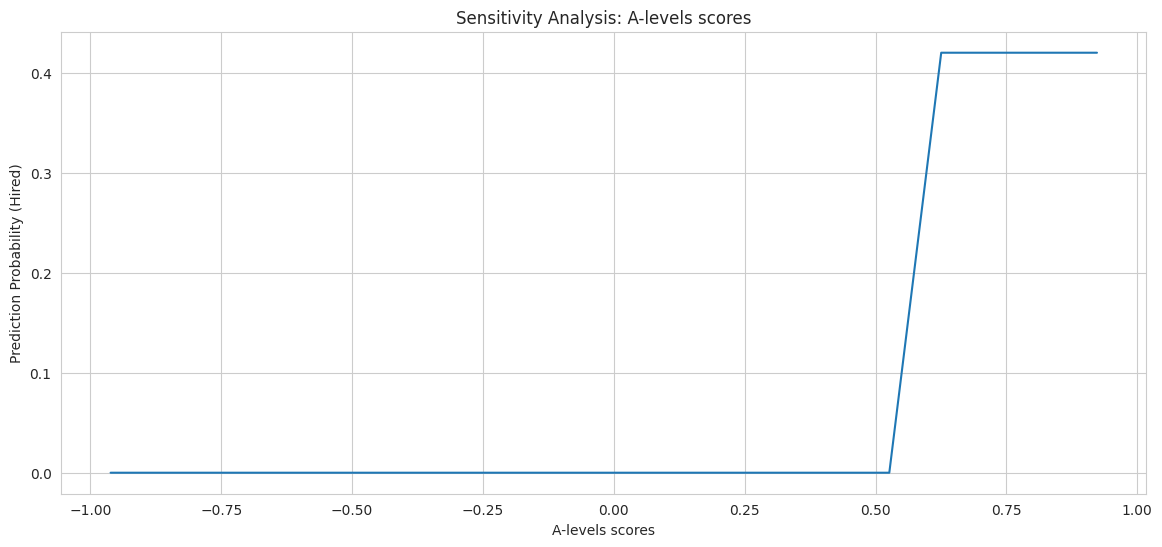

In [88]:
print("SENSITIVITY ANALYSIS")

sample_idx = 0
sample = X_test_eng.iloc[sample_idx].copy()

feature_to_test = X_test_eng.columns[top_features_idx[0]]

test_values = np.linspace(
    X_test_eng[feature_to_test].min(),
    X_test_eng[feature_to_test].max(),
    20
)

predictions = []

for val in test_values:
    temp_sample = sample.copy()
    temp_sample[feature_to_test] = val
    pred = best_model_eng.predict_proba(temp_sample.values.reshape(1, -1))[0][1]
    predictions.append(pred)

plt.figure()
plt.plot(test_values, predictions)
plt.xlabel(feature_to_test)
plt.ylabel('Prediction Probability (Hired)')
plt.title(f'Sensitivity Analysis: {feature_to_test}')
plt.grid(True)
plt.show()

## Bias Detection


BIAS DETECTION
Protected one-hot features detected:
 - Education_business
 - Education_law
 - Education_stem
 - University Tier_Other
 - University Tier_Strong

Bias results:
                  Feature    Group  Positive Rate (Hired)  Count
0      Education_business  Group=1               0.242489    466
1      Education_business  Group=0               0.209428   1294
2           Education_law  Group=1               0.188341    446
3           Education_law  Group=0               0.228311   1314
4          Education_stem  Group=1               0.175520    433
5          Education_stem  Group=0               0.232102   1327
6   University Tier_Other  Group=1               0.161517   1424
7   University Tier_Other  Group=0               0.458333    336
8  University Tier_Strong  Group=1               0.118012    161
9  University Tier_Strong  Group=0               0.228268   1599


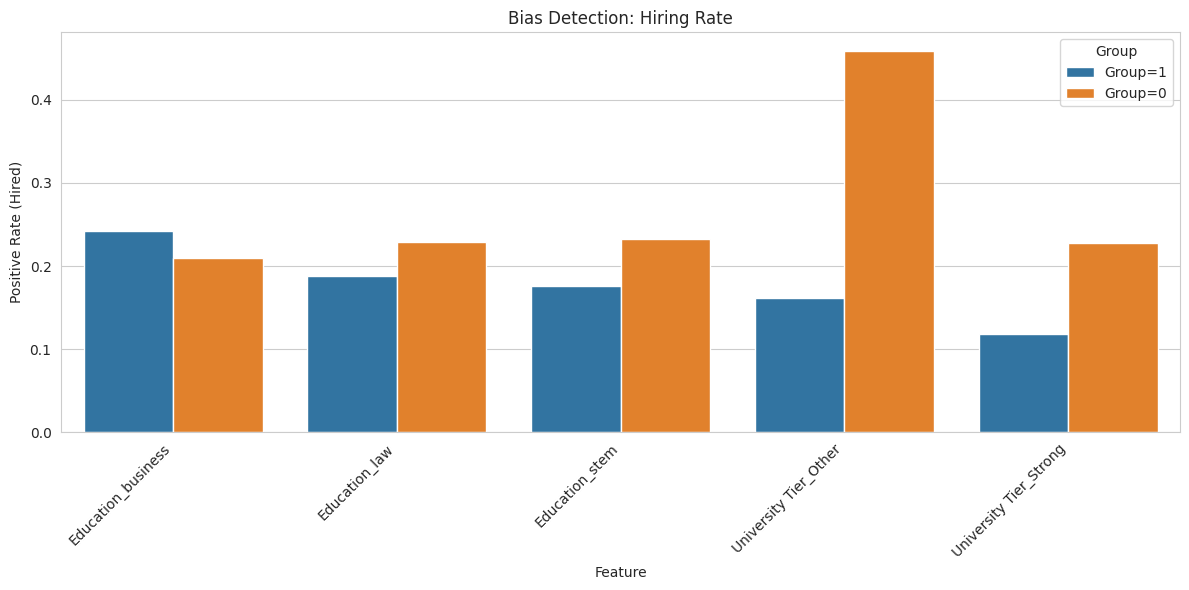

In [89]:
print("\n" + "="*60)
print("BIAS DETECTION")
print("="*60)

protected_prefixes = ['education', 'university tier']

protected_features = [
    col for col in X_test_eng.columns
    if any(p in col.lower() for p in protected_prefixes)
]

print("Protected one-hot features detected:")
for col in protected_features:
    print(" -", col)

bias_results = []

for feature in protected_features:
    for group_value, label in [(1, 'Group=1'), (0, 'Group=0')]:
        subset = X_test_eng[X_test_eng[feature] == group_value]

        if len(subset) < 10:
            continue

        preds = best_model_eng.predict(subset)
        positive_rate = np.mean(preds)

        bias_results.append({
            'Feature': feature,
            'Group': label,
            'Positive Rate (Hired)': positive_rate,
            'Count': len(subset)
        })

bias_df = pd.DataFrame(bias_results)

if bias_df.empty:
    print("\n No sufficient data for bias analysis.")
else:
    print("\nBias results:")
    print(bias_df)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=bias_df,
        x='Feature',
        y='Positive Rate (Hired)',
        hue='Group'
    )
    plt.title('Bias Detection: Hiring Rate')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Comparative Analysis: SHAP vs LIME

In [90]:
comparison_df = pd.DataFrame({
    'Aspect': [
        'Theoretical Foundation',
        'Global vs Local',
        'Model Agnostic',
        'Computational Speed',
        'Visualization Types',
        'Interpretability',
        'Feature Interactions',
        'Consistency'
    ],
    'SHAP': [
        'Shapley values (Game Theory)',
        'Both Global & Local',
        'Yes (Fast for tree models)',
        'Fast for tree-based',
        'Summary, Force, Dependence, Waterfall',
        'Mathematically rigorous',
        'Yes (excellent via dependence)',
        'Mathematically guaranteed'
    ],
    'LIME': [
        'Local Linear Approximation',
        'Primarily Local',
        'Yes (truly model-agnostic)',
        'Slower (trains local models)',
        'Bar plots, HTML reports',
        'Intuitive, easy to understand',
        'Limited to local region',
        'Can vary by local region'
    ]
})

print("\nSHAP vs LIME Comparison:")
print(comparison_df.to_string(index=False))


SHAP vs LIME Comparison:
                Aspect                                  SHAP                          LIME
Theoretical Foundation          Shapley values (Game Theory)    Local Linear Approximation
       Global vs Local                   Both Global & Local               Primarily Local
        Model Agnostic            Yes (Fast for tree models)    Yes (truly model-agnostic)
   Computational Speed                   Fast for tree-based  Slower (trains local models)
   Visualization Types Summary, Force, Dependence, Waterfall       Bar plots, HTML reports
      Interpretability               Mathematically rigorous Intuitive, easy to understand
  Feature Interactions        Yes (excellent via dependence)       Limited to local region
           Consistency             Mathematically guaranteed      Can vary by local region


In [91]:
print("\n" + "="*70)
print("PART C: EXPLAINABILITY ANALYSIS - SUMMARY")
print("="*70)
print(f"\nDataset: Engineered (Best Model Performance)")
print(f"\nSHAP Analysis:")
print(f"  - Test samples analyzed: {X_test_eng.shape[0]}")
print(f"  - Global feature importance: Top {len(top_features)} features identified")
print(f"  - Individual explanations: Force plots for hired/not-hired examples")
print(f"  - Feature interactions: Dependence plots for top 4 features")
print(f"\nLIME Analysis:")
print(f"  - Random test samples: 10")
print(f"  - Top features per sample: 5")
print(f"  - Accuracy on explained samples: {accuracy*100:.1f}%")
print(f"  - Visualizations: 10 bar charts showing feature contributions")
print(f"\nComparative Analysis:")
print(f"  - Methods compared: SHAP vs LIME")
print(f"  - Key insights: Methods complement each other")
print(f"    - SHAP: Global patterns and interactions")
print(f"    - LIME: Local decision explanations")
print(f"\n" + "="*70)


PART C: EXPLAINABILITY ANALYSIS - SUMMARY

Dataset: Engineered (Best Model Performance)

SHAP Analysis:
  - Test samples analyzed: 1760
  - Global feature importance: Top 9 features identified
  - Individual explanations: Force plots for hired/not-hired examples
  - Feature interactions: Dependence plots for top 4 features

LIME Analysis:
  - Random test samples: 10
  - Top features per sample: 5
  - Accuracy on explained samples: 100.0%
  - Visualizations: 10 bar charts showing feature contributions

Comparative Analysis:
  - Methods compared: SHAP vs LIME
  - Key insights: Methods complement each other
    - SHAP: Global patterns and interactions
    - LIME: Local decision explanations



# Fairness Evaluation

In [92]:
def safe_div(a, b):
    return a / b if b != 0 else 0.0


def group_confusion(y_true, y_pred, mask):
    TP = np.sum((y_true == 1) & (y_pred == 1) & mask)
    FP = np.sum((y_true == 0) & (y_pred == 1) & mask)
    TN = np.sum((y_true == 0) & (y_pred == 0) & mask)
    FN = np.sum((y_true == 1) & (y_pred == 0) & mask)
    return TP, FP, TN, FN


def bin_age(vals):
    return bin_age(vals)



In [93]:
df_original = pd.read_csv("LightHR_dataset.csv")

target_col = "Was Hired by a Company within 6 months"
FAV = 1

X = df_original.drop(columns=[target_col])
y = df_original[target_col]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_test  = pd.get_dummies(X_test_raw, drop_first=True)

X_test = X_test.reindex(columns=best_model_eng.feature_names_in_, fill_value=0)

y_pred = np.asarray(best_model_eng.predict(X_test))
y_true = np.asarray(y_test)

raw_test = df_original.loc[X_test_raw.index]

MODEL PERFORMANCE
Accuracy: 0.6648
              precision    recall  f1-score   support

           0       1.00      0.56      0.72      1338
           1       0.42      1.00      0.59       422

    accuracy                           0.66      1760
   macro avg       0.71      0.78      0.65      1760
weighted avg       0.86      0.66      0.69      1760



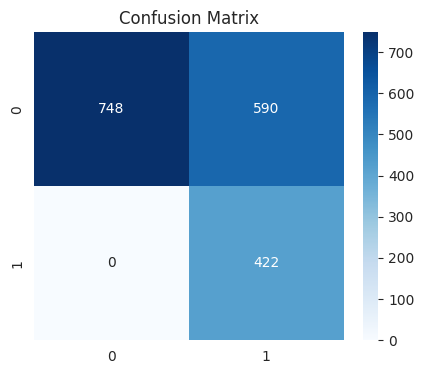

In [94]:
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

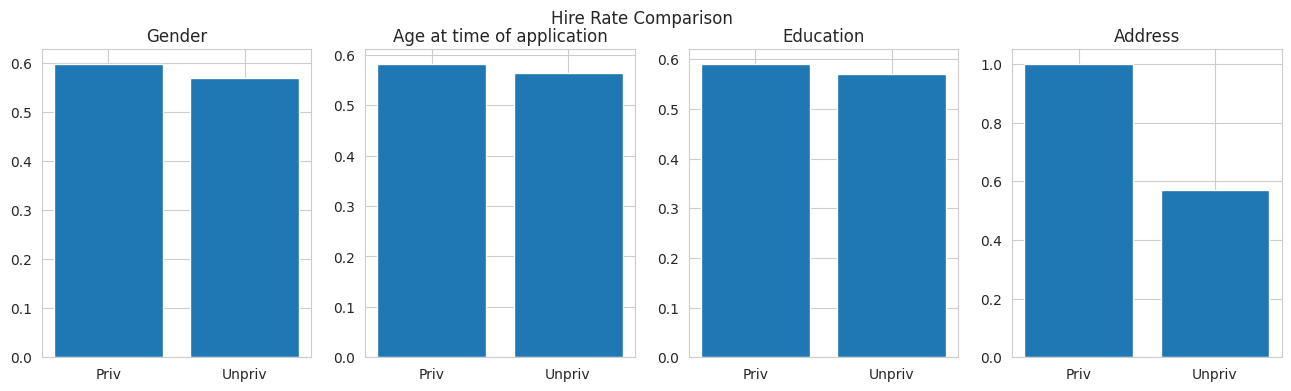

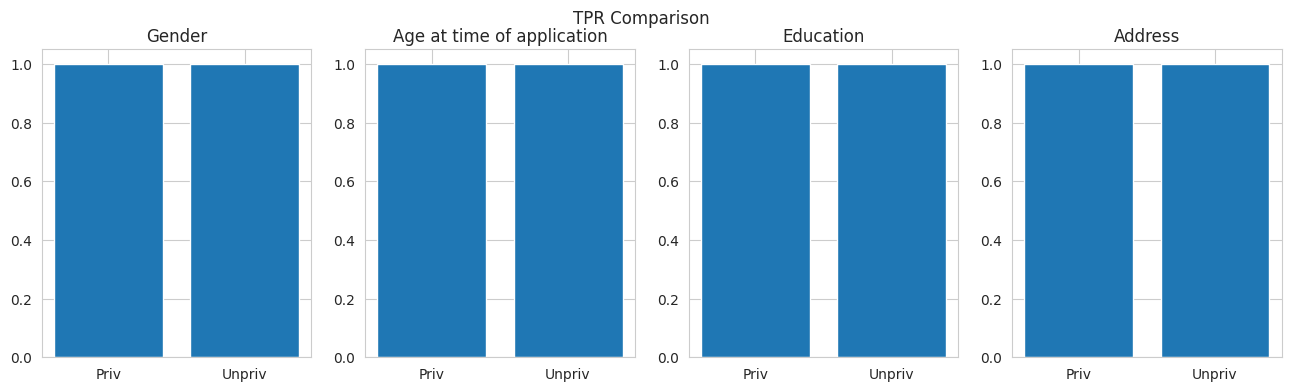

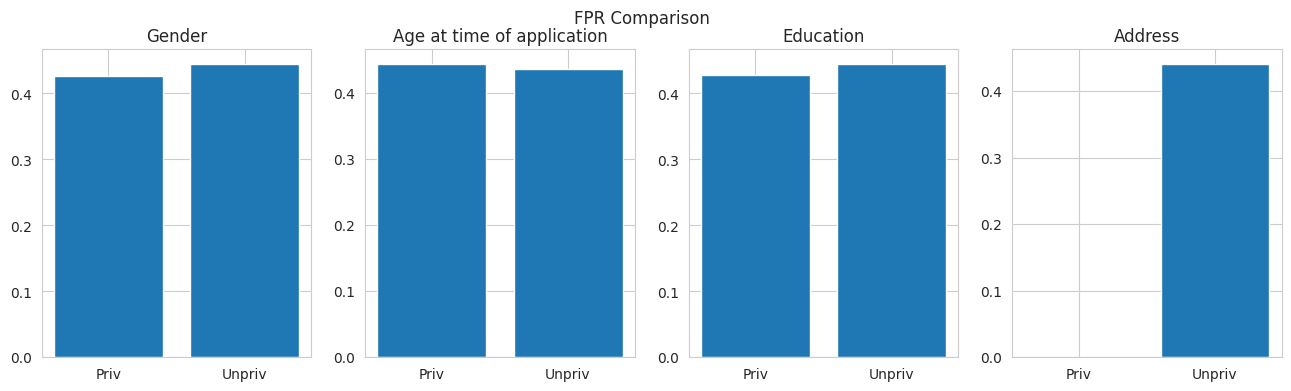

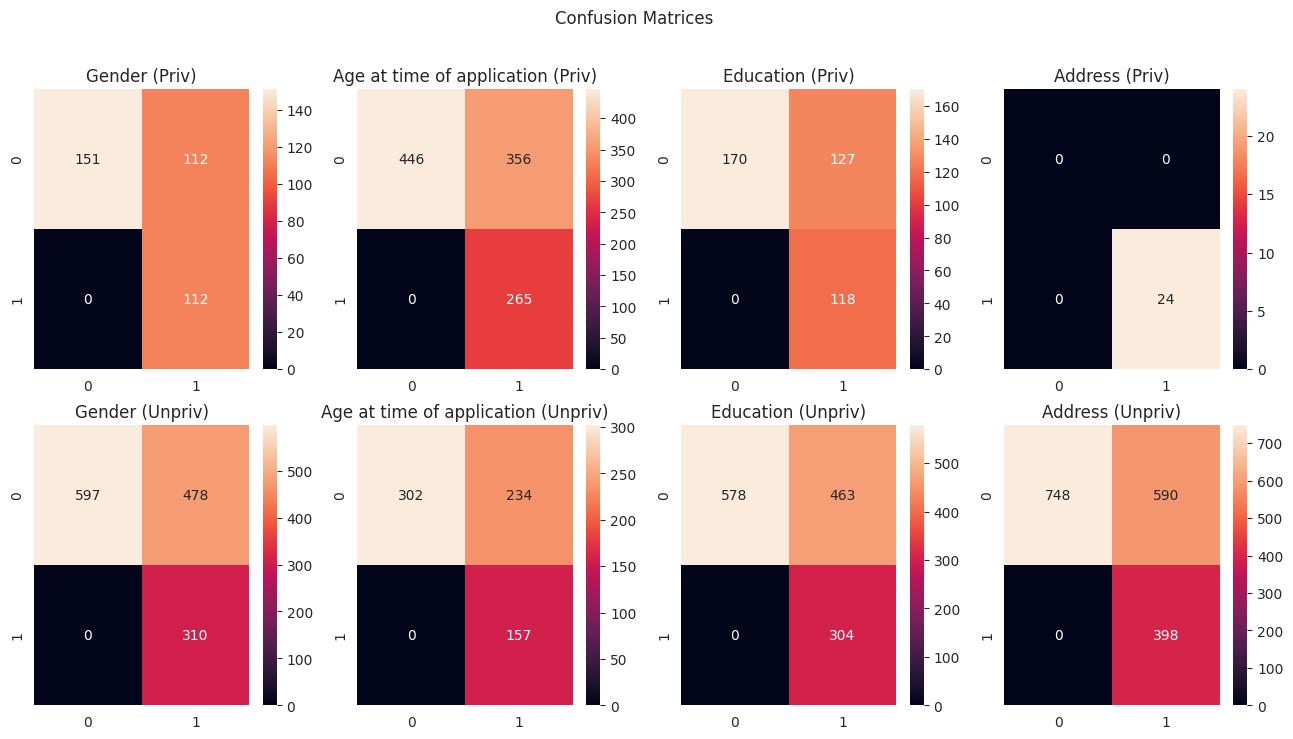

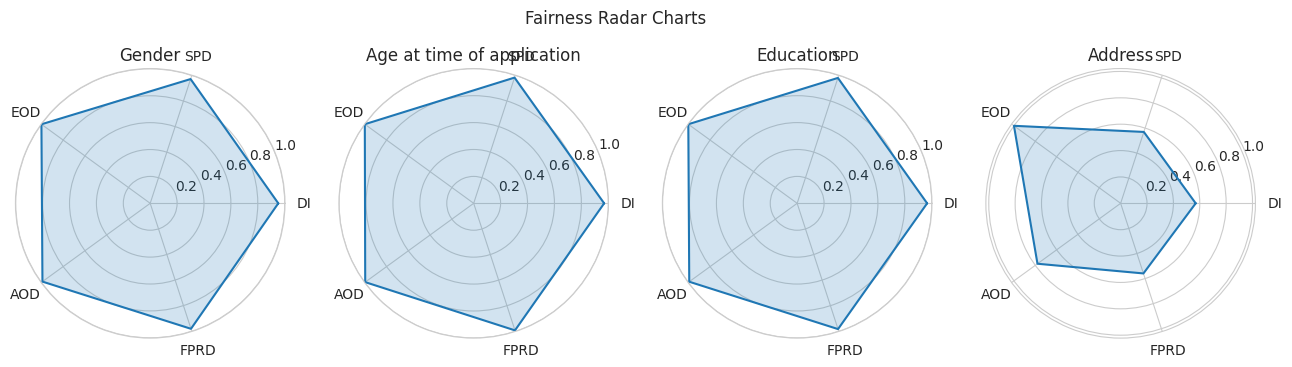

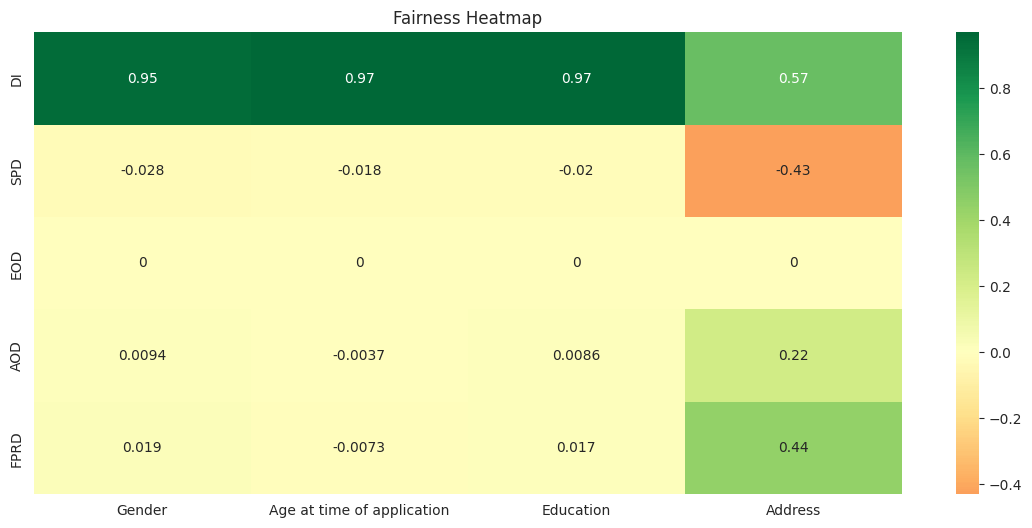

In [95]:
raw_test = df_original.loc[X_test_raw.index]

SENSITIVE_ATTRS = {
    "Gender": "categorical",
    "Age at time of application": "continuous",
    "Education": "categorical",
    "Address": "categorical",
}

FAV = 1

fairness_results = {}
plot_data = {}

for attr, kind in SENSITIVE_ATTRS.items():

    if attr not in raw_test.columns:
        continue

    vals = raw_test[attr].to_numpy()

    # Bin continuous variables
    if kind == "continuous":
        vals = pd.cut(
            vals,
            bins=[0, 25, 35, 45, 55, 200],
            labels=["Under 25", "25–34", "35–44", "45–54", "55+"]
        ).astype(str)

    # Compute group stats
    stats = []
    for g in np.unique(vals):
        mask = (vals == g)
        if mask.sum() < 10:
            continue
        stats.append((g, mask.sum(), np.mean(y_pred[mask] == FAV)))

    stats_df = pd.DataFrame(
        stats, columns=["Group", "N", "PredRate"]
    ).sort_values("PredRate", ascending=False)

    if stats_df.empty:
        continue

    # Define privileged group dynamically
    priv = stats_df.iloc[0]["Group"]

    priv_mask = (vals == priv)
    unpriv_mask = ~priv_mask

    p_priv = safe_div(np.sum(y_pred[priv_mask] == FAV), priv_mask.sum())
    p_unpriv = safe_div(np.sum(y_pred[unpriv_mask] == FAV), unpriv_mask.sum())

    TP_p, FP_p, TN_p, FN_p = group_confusion(y_true, y_pred, priv_mask)
    TP_u, FP_u, TN_u, FN_u = group_confusion(y_true, y_pred, unpriv_mask)

    TPR_p = safe_div(TP_p, TP_p + FN_p)
    TPR_u = safe_div(TP_u, TP_u + FN_u)

    FPR_p = safe_div(FP_p, FP_p + TN_p)
    FPR_u = safe_div(FP_u, FP_u + TN_u)

    DI   = safe_div(p_unpriv, p_priv)
    SPD  = p_unpriv - p_priv
    EOD  = TPR_u - TPR_p
    AOD  = 0.5 * ((TPR_u - TPR_p) + (FPR_u - FPR_p))
    FPRD = FPR_u - FPR_p

    fairness_results[attr] = [DI, SPD, EOD, AOD, FPRD]

    # Store for plotting
    plot_data[attr] = {
        "p": (p_priv, p_unpriv),
        "TPR": (TPR_p, TPR_u),
        "FPR": (FPR_p, FPR_u),
        "conf_priv": [[TN_p, FP_p], [FN_p, TP_p]],
        "conf_unpriv": [[TN_u, FP_u], [FN_u, TP_u]],
        "metrics": [DI, SPD, EOD, AOD, FPRD],
    }

attrs = list(plot_data.keys())
n = len(attrs)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

if n == 1:
    axes = [axes]

for i, attr in enumerate(attrs):
    p_priv, p_unpriv = plot_data[attr]["p"]
    axes[i].bar(["Priv", "Unpriv"], [p_priv, p_unpriv])
    axes[i].set_title(attr)

fig.suptitle("Hire Rate Comparison")
plt.show()

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

if n == 1:
    axes = [axes]

for i, attr in enumerate(attrs):
    TPR_p, TPR_u = plot_data[attr]["TPR"]
    axes[i].bar(["Priv", "Unpriv"], [TPR_p, TPR_u])
    axes[i].set_title(attr)

fig.suptitle("TPR Comparison")
plt.show()

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

if n == 1:
    axes = [axes]

for i, attr in enumerate(attrs):
    FPR_p, FPR_u = plot_data[attr]["FPR"]
    axes[i].bar(["Priv", "Unpriv"], [FPR_p, FPR_u])
    axes[i].set_title(attr)

fig.suptitle("FPR Comparison")
plt.show()

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

if n == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i, attr in enumerate(attrs):
    sns.heatmap(plot_data[attr]["conf_priv"], annot=True, fmt='d', ax=axes[0, i])
    axes[0, i].set_title(f"{attr} (Priv)")

    sns.heatmap(plot_data[attr]["conf_unpriv"], annot=True, fmt='d', ax=axes[1, i])
    axes[1, i].set_title(f"{attr} (Unpriv)")

fig.suptitle("Confusion Matrices")
plt.show()

labels = ["DI", "SPD", "EOD", "AOD", "FPRD"]

fig = plt.figure(figsize=(4*n, 4))

for i, attr in enumerate(attrs):
    metrics = plot_data[attr]["metrics"]

    values = [1 - abs(m - 1) if j == 0 else 1 - abs(m)
              for j, m in enumerate(metrics)]
    values += values[:1]

    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    ax = fig.add_subplot(1, n, i+1, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_title(attr)

plt.suptitle("Fairness Radar Charts")
plt.show()

heatmap_df = pd.DataFrame(
    fairness_results,
    index=["DI", "SPD", "EOD", "AOD", "FPRD"]
)

sns.heatmap(heatmap_df, annot=True, cmap="RdYlGn", center=0)
plt.title("Fairness Heatmap")
plt.show()

INDIVIDUAL FAIRNESS ANALYSIS (FINAL)

Consistency Score: 0.5104

[GLOBAL ERROR PROFILE]
False Positive Rate : 0.3352
False Negative Rate : 0.0000

Pairwise Fairness: 0.5898

Cross-group fairness computed.


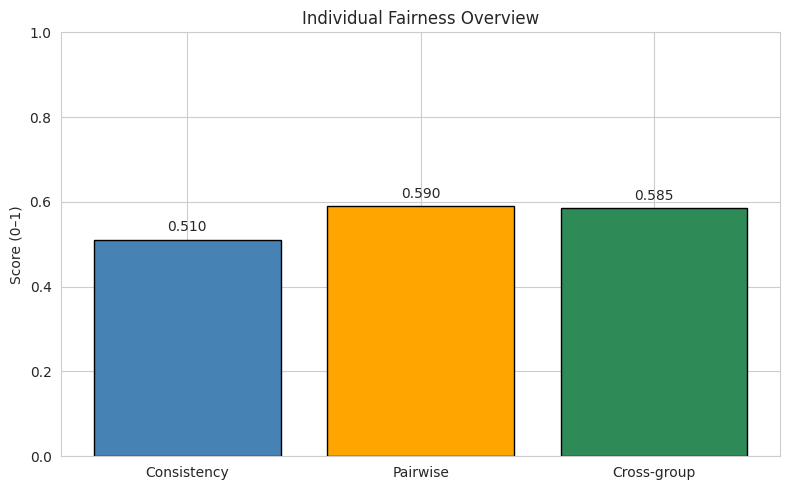

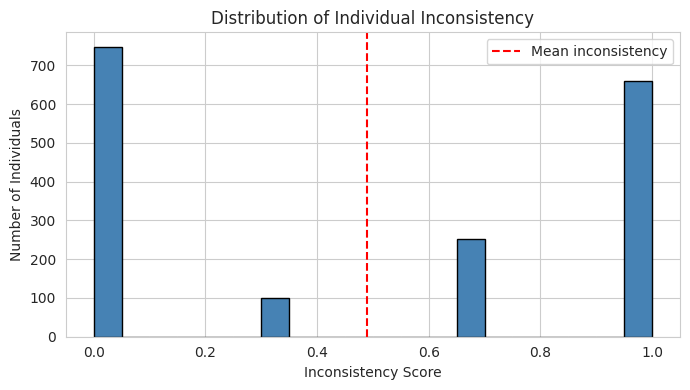

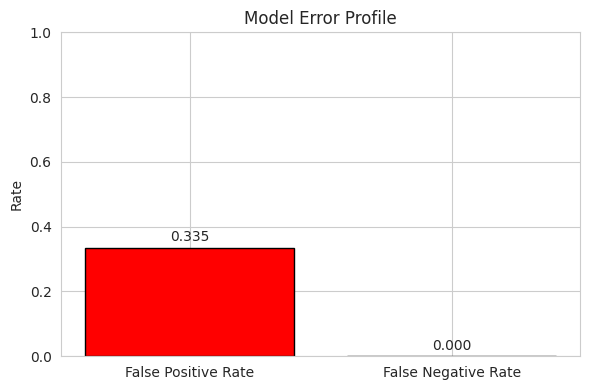

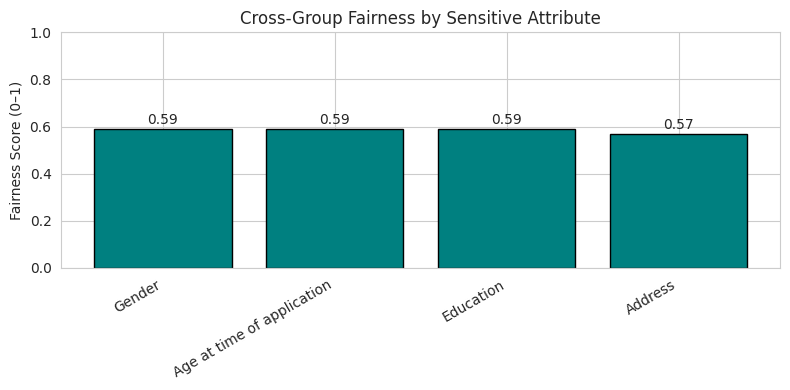


FINAL INDIVIDUAL FAIRNESS SUMMARY
Consistency Score      : 0.5104
Pairwise Fairness      : 0.5898
Cross-group Fairness   : 0.5855
FN Disparity           : 0.0000
FP Disparity           : 0.0866


In [96]:
print("INDIVIDUAL FAIRNESS ANALYSIS (FINAL)")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import euclidean_distances

# FEATURE PREPARATION

cols_to_drop = list(SENSITIVE_ATTRS.keys())

X_np = X_test_raw.drop(columns=cols_to_drop, errors='ignore')
X_np = pd.get_dummies(X_np, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_np)

# CONSISTENCY SCORE
def consistency_score(X, y, k=3):
    nbrs = NearestNeighbors(n_neighbors=min(k+1, len(y))).fit(X)
    _, inds = nbrs.kneighbors(X)

    inconsistencies = [
        np.mean(y[inds[i][1:]] != y[i]) for i in range(len(y))
    ]

    return 1 - np.mean(inconsistencies), np.array(inconsistencies)

cons_score, per_point_incons = consistency_score(X_scaled, y_pred)

print(f"\nConsistency Score: {cons_score:.4f}")

# GLOBAL ERROR PROFILE

fp_rate = np.mean((y_true == 0) & (y_pred == 1))
fn_rate = np.mean((y_true == 1) & (y_pred == 0))

print("\n[GLOBAL ERROR PROFILE]")
print(f"False Positive Rate : {fp_rate:.4f}")
print(f"False Negative Rate : {fn_rate:.4f}")

# PAIRWISE FAIRNESS
euc = euclidean_distances(X_scaled)
threshold = np.percentile(euc[np.triu_indices(len(euc), 1)], 30)

similar_pairs = [
    (i, j)
    for i in range(len(euc))
    for j in range(i+1, len(euc))
    if euc[i, j] <= threshold
]

inconsistent_pairs = [
    (i, j)
    for (i, j) in similar_pairs
    if y_pred[i] != y_pred[j]
]

pairwise_fairness = 1 - safe_div(len(inconsistent_pairs), len(similar_pairs))

print(f"\nPairwise Fairness: {pairwise_fairness:.4f}")

# CROSS-GROUP FAIRNESS
cross_group_results = {}

for attr in SENSITIVE_ATTRS:

    if attr not in raw_test.columns:
        continue

    vals = raw_test[attr].to_numpy()

    if SENSITIVE_ATTRS[attr] == "continuous":
        vals = pd.cut(vals, [0,25,35,45,55,200],
                      labels=["Under 25","25–34","35–44","45–54","55+"]).astype(str)

    priv_val = pd.Series(vals).value_counts().idxmax()
    priv_mask = (vals == priv_val)

    cross_pairs = [(i, j) for (i, j) in similar_pairs if priv_mask[i] != priv_mask[j]]
    cross_inconsistent = [(i, j) for (i, j) in cross_pairs if y_pred[i] != y_pred[j]]

    cross_group_results[attr] = 1 - safe_div(len(cross_inconsistent), len(cross_pairs))

cross_group_fairness = np.mean(list(cross_group_results.values()))

print("\nCross-group fairness computed.")

# GROUP ERROR DISPARITIES

TP_p, FP_p, TN_p, FN_p = group_confusion(y_true, y_pred, priv_mask)
TP_u, FP_u, TN_u, FN_u = group_confusion(y_true, y_pred, ~priv_mask)

priv_fn_rate   = FN_p / (FN_p + TP_p + 1e-9)
unpriv_fn_rate = FN_u / (FN_u + TP_u + 1e-9)

priv_fp_rate   = FP_p / (FP_p + TN_p + 1e-9)
unpriv_fp_rate = FP_u / (FP_u + TN_u + 1e-9)

fn_disparity = abs(unpriv_fn_rate - priv_fn_rate)
fp_disparity = abs(unpriv_fp_rate - priv_fp_rate)


plt.figure(figsize=(8,5))

metrics = ["Consistency", "Pairwise", "Cross-group"]
values = [cons_score, pairwise_fairness, cross_group_fairness]

plt.bar(metrics, values, color=['steelblue','orange','seagreen'], edgecolor='black')

plt.title("Individual Fairness Overview")
plt.ylabel("Score (0–1)")
plt.ylim(0,1)

for i, v in enumerate(values):
    plt.text(i, v+0.02, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()


plt.figure(figsize=(7,4))

plt.hist(per_point_incons, bins=20, color='steelblue', edgecolor='black')
plt.axvline(np.mean(per_point_incons), color='red', linestyle='--',
            label="Mean inconsistency")

plt.title("Distribution of Individual Inconsistency")
plt.xlabel("Inconsistency Score")
plt.ylabel("Number of Individuals")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,4))

plt.bar(["False Positive Rate", "False Negative Rate"],
        [fp_rate, fn_rate],
        color=['red','purple'], edgecolor='black')

plt.title("Model Error Profile")
plt.ylabel("Rate")
plt.ylim(0,1)

plt.text(0, fp_rate+0.02, f"{fp_rate:.3f}", ha='center')
plt.text(1, fn_rate+0.02, f"{fn_rate:.3f}", ha='center')

plt.tight_layout()
plt.show()


plt.figure(figsize=(8,4))

keys = list(cross_group_results.keys())
vals = list(cross_group_results.values())

plt.bar(keys, vals, color='teal', edgecolor='black')

plt.title("Cross-Group Fairness by Sensitive Attribute")
plt.ylabel("Fairness Score (0–1)")
plt.ylim(0,1)

plt.xticks(rotation=30, ha='right')

for i, v in enumerate(vals):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("FINAL INDIVIDUAL FAIRNESS SUMMARY")
print("="*60)

print(f"Consistency Score      : {cons_score:.4f}")
print(f"Pairwise Fairness      : {pairwise_fairness:.4f}")
print(f"Cross-group Fairness   : {cross_group_fairness:.4f}")
print(f"FN Disparity           : {fn_disparity:.4f}")
print(f"FP Disparity           : {fp_disparity:.4f}")

# store results
fairness_results["Individual"] = {
    "ConsistencyScore": cons_score,
    "PairwiseFairness": pairwise_fairness,
    "CrossGroupFairness": cross_group_fairness,
    "FNDisparity": fn_disparity,
    "FPDisparity": fp_disparity
}

FINAL FAIRNESS HEATMAP


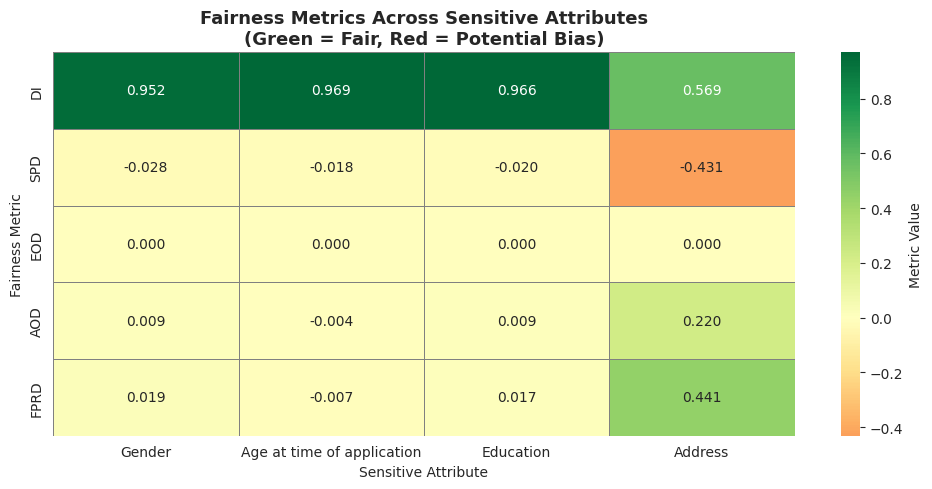

In [97]:
print("FINAL FAIRNESS HEATMAP")
print("="*60)

metrics = ["DI", "SPD", "EOD", "AOD", "FPRD"]

group_fairness = {
    attr: vals
    for attr, vals in fairness_results.items()
    if isinstance(vals, list) and len(vals) == len(metrics)
}

heatmap_data = pd.DataFrame(
    group_fairness,
    index=metrics
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="grey",
    cbar_kws={'label': 'Metric Value'}
)

plt.title(
    "Fairness Metrics Across Sensitive Attributes\n"
    "(Green = Fair, Red = Potential Bias)",
    fontsize=13,
    fontweight='bold'
)

plt.xlabel("Sensitive Attribute")
plt.ylabel("Fairness Metric")

plt.tight_layout()
plt.show()